# Block 0: Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

# Upload file
uploaded = files.upload()   # select dirty_v3_path.csv

# Load
df_raw = pd.read_csv('dirty_v3_path.csv')
print("Shape:", df_raw.shape)
df_raw.head()

In [6]:
# Block 0 (Revised with pathlib)
import pandas as pd
from pathlib import Path
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the base path to your data folder using pathlib
# Replace the path below with the actual folder path in your Drive
data_dir = Path('/content/drive/MyDrive/Python_SQL/HealthCare_MeshyData')

# 3. Create the full path to your file using the / operator
csv_path = data_dir / 'dirty_v3_path.csv'

# 4. Check if the file exists before reading (best practice)
if not csv_path.exists():
    print(f"❌ File not found at: {csv_path}")
    print("Check the folder name and file name in Google Drive.")
else:
    # 5. Read the CSV
    df_raw = pd.read_csv(csv_path)
    print(f"✅ Loaded: {csv_path.name}")
    print("Shape:", df_raw.shape)
    df_raw.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: dirty_v3_path.csv
Shape: (30000, 20)


In [7]:
# ============================================================
# BLOCK 1 — INITIAL RECONNAISSANCE
# ============================================================
# Purpose:
#   Before touching a single value, we must understand the SHAPE of the mess.
#   Skipping this step is the #1 reason data cleaning goes wrong — you end up
#   "fixing" things that weren't broken and missing the real problems.
#
#   In healthcare data specifically, we look for:
#     - Impossible vitals (O2 sat > 100, negative BP, age > 120)
#     - Suspicious zeros (a living patient can't have BP = 0)
#     - Missingness patterns (informative or random?)
#     - Junk/synthetic columns that don't belong in clinical analysis
#     - Mixed types in the same column (numbers stored as text)
#     - Duplicate rows (common when EHRs are merged from multiple sources)
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1.1  Basic shape and memory footprint
# ------------------------------------------------------------
# .shape gives (rows, columns). Useful to set expectations early.
# .memory_usage() helps decide if we can afford in-memory operations
# (in Colab, free tier ~12GB RAM — a 10M-row EHR extract would blow it).
print("=" * 70)
print("1.1  DATASET SHAPE & MEMORY")
print("=" * 70)
print(f"Rows    : {df_raw.shape[0]:,}")
print(f"Columns : {df_raw.shape[1]:,}")
print(f"Memory  : {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


# ------------------------------------------------------------
# 1.2  Column names and data types
# ------------------------------------------------------------
# Why: If 'Glucose' shows up as `object` (string) instead of `float64`,
# it means somewhere in the file there's a value like "N/A" or "120 mg/dL"
# that pandas couldn't coerce. We need to know this BEFORE trying math on it.
print("\n" + "=" * 70)
print("1.2  COLUMN NAMES & DTYPES")
print("=" * 70)
dtype_df = pd.DataFrame({
    'dtype':   df_raw.dtypes,
    'non_null': df_raw.notna().sum(),
    'null':     df_raw.isna().sum(),
    'null_%':  (df_raw.isna().sum() / len(df_raw) * 100).round(2),
    'unique':   df_raw.nunique()
})
print(dtype_df)


# ------------------------------------------------------------
# 1.3  First and last rows (context, not summary)
# ------------------------------------------------------------
# Why: `head()` and `tail()` reveal the RAW form of values.
# In your file, you'll notice:
#   - `random_notes` contains 'lorem', 'ipsum', '###', '??'
#   - `noise_col` contains large random floats (synthetic filler)
#   - Empty strings appear as NaN only after pandas parses them
print("\n" + "=" * 70)
print("1.3  FIRST 5 ROWS (raw form)")
print("=" * 70)
print(df_raw.head())

print("\n" + "=" * 70)
print("1.4  LAST 5 ROWS (raw form)")
print("=" * 70)
print(df_raw.tail())


# ------------------------------------------------------------
# 1.5  Numerical summary — the truth-teller
# ------------------------------------------------------------
# Why: `describe()` reveals:
#   - min values that are impossible (Age = -5, BP = 0)
#   - max values beyond physiology (O2 sat = 107)
#   - huge std or mean/min gaps → heavy skew or contamination
#   - count < total rows → missing values hiding in numeric columns
#
# Tip: We transpose (.T) so each column becomes a row — easier to read.
print("\n" + "=" * 70)
print("1.5  NUMERICAL SUMMARY (transposed for readability)")
print("=" * 70)
print(df_raw.describe(include=[np.number]).T)


# ------------------------------------------------------------
# 1.6  Categorical summary
# ------------------------------------------------------------
# Why: For object/string columns, describe() gives us:
#   - count of non-null
#   - number of unique values
#   - top (most frequent) value + its frequency
#
# This immediately shows us the known categorical fields
# (Gender, Medical Condition, Smoking, etc.) vs the junk columns
# (random_notes → high cardinality, 'lorem'/'ipsum' as top values).
print("\n" + "=" * 70)
print("1.6  CATEGORICAL SUMMARY")
print("=" * 70)
print(df_raw.describe(include=['object']).T)


# ------------------------------------------------------------
# 1.7  Missing value map
# ------------------------------------------------------------
# Why: Missingness in healthcare is rarely random.
#   - A lab not ordered = patient was stable → informative
#   - A field always blank = broken EHR export → systematic
#
# We sort descending so the worst offenders appear first.
print("\n" + "=" * 70)
print("1.7  MISSING VALUES (sorted, with % of total)")
print("=" * 70)
missing = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct':   missing_pct
})
# Only show columns that actually have missing data
print(missing_report[missing_report['missing_count'] > 0])


# ------------------------------------------------------------
# 1.8  Duplicate rows
# ------------------------------------------------------------
# Why: In EHR merges, duplicate rows are common and dangerous —
# they bias averages, inflate statistical power, and can leak
# across train/test splits in ML.
#
# We check BOTH:
#   - full-row duplicates (exact copies)
#   - key-based duplicates (e.g., same patient ID appearing twice)
print("\n" + "=" * 70)
print("1.8  DUPLICATE ROWS")
print("=" * 70)
print(f"Fully duplicated rows : {df_raw.duplicated().sum()}")


# ------------------------------------------------------------
# 1.9  High-level unique-value scan
# ------------------------------------------------------------
# Why: This is a heuristic for identifying junk columns.
#   - A column with 1 unique value → useless (constant)
#   - A column with ~100% unique values AND object type → likely an ID
#     or free-text field (like `random_notes`)
#   - A column with 2 unique values → probably binary flag (ok)
print("\n" + "=" * 70)
print("1.9  UNIQUE VALUE COUNTS (sorted — spot junk fast)")
print("=" * 70)
unique_counts = df_raw.nunique().sort_values(ascending=False)
print(unique_counts.to_frame('n_unique'))


# ------------------------------------------------------------
# 1.10  Peek at suspicious categorical columns
# ------------------------------------------------------------
# Why: For columns like Gender, Smoking, Alcohol we want to see
# every distinct value + its frequency. This reveals:
#   - typos ('Male', 'male', 'M', 'm')
#   - blank strings being counted as a category
#   - inconsistent encodings (0/1 vs Yes/No)
candidate_cats = ['Gender', 'Medical Condition', 'Smoking',
                  'Alcohol', 'Family History']
candidate_cats = [c for c in candidate_cats if c in df_raw.columns]

print("\n" + "=" * 70)
print("1.10  VALUE COUNTS FOR KNOWN CATEGORICALS")
print("=" * 70)
for col in candidate_cats:
    print(f"\n--- {col} ---")
    print(df_raw[col].value_counts(dropna=False).head(15))


# ------------------------------------------------------------
# 1.11  Quick outlier scan on key vitals
# ------------------------------------------------------------
# Why: We want to see — at a glance — how dirty the physiological
# columns are. We compute the % of values that fall outside the
# population-level "plausible" range. This is NOT yet a cleaning step;
# it's a diagnostic to inform Block 4's soft-flagging strategy.
#
# These are ROUGH plausibility windows (population-level), not
# clinical decision thresholds. Real pathology can exceed them.
print("\n" + "=" * 70)
print("1.11  QUICK OUT-OF-RANGE SCAN (informational)")
print("=" * 70)

rough_ranges = {
    'Age':               (0,   120),
    'Glucose':           (20,  600),
    'Blood Pressure':    (40,  250),
    'BMI':               (10,  80),
    'Oxygen Saturation': (50,  100),
    'Cholesterol':       (50,  800),
    'Triglycerides':     (20,  1500),
    'HbA1c':             (3.0, 20.0),
    'Physical Activity': (0,   168),
    'Sleep Hours':       (0,   24),
    'LengthOfStay':      (0,   365),
    'Diet Score':        (0,   10),
    'Stress Level':      (0,   10),
}

scan_results = []
for col, (lo, hi) in rough_ranges.items():
    if col not in df_raw.columns:
        continue
    s = pd.to_numeric(df_raw[col], errors='coerce')
    n_below = int((s < lo).sum())
    n_above = int((s > hi).sum())
    n_neg   = int((s < 0).sum())   # negatives are almost always errors
    scan_results.append({
        'column':      col,
        'n_below_min': n_below,
        'n_above_max': n_above,
        'n_negative':  n_neg,
        'pct_dirty':   round((n_below + n_above) / len(df_raw) * 100, 2)
    })

scan_df = pd.DataFrame(scan_results).sort_values('pct_dirty', ascending=False)
print(scan_df.to_string(index=False))


# ------------------------------------------------------------
# 1.12  What we've learned — write it down
# ------------------------------------------------------------
# Why: Documenting findings AT THE POINT OF DISCOVERY prevents
# "cleaning drift" — where later steps silently invalidate earlier ones.
# In a real clinical data pipeline, this goes into a data-quality report.
print("\n" + "=" * 70)
print("1.12  RECON CHECKLIST (fill in for your dataset)")
print("=" * 70)
checklist = {
    "Junk columns to drop":         ["random_notes", "noise_col"],
    "Columns with any missing":     list(missing_report[missing_report['missing_count']>0].index),
    "Categoricals needing cleanup": ["Gender", "Medical Condition"],
    "Columns to bound-check":       list(rough_ranges.keys()),
    "Impossible-value flags seen":  ["O2 sat >100", "negative values", "0 vitals"],
    "Duplicate row count":          int(df_raw.duplicated().sum()),
}
for k, v in checklist.items():
    print(f"  {k:32s}: {v}")

1.1  DATASET SHAPE & MEMORY
Rows    : 30,000
Columns : 20
Memory  : 8.39 MB

1.2  COLUMN NAMES & DTYPES
                     dtype  non_null  null  null_%  unique
Age                float64     25500  4500    15.0      80
Gender              object     25500  4500    15.0       2
Medical Condition   object     25500  4500    15.0       7
Glucose            float64     25500  4500    15.0   11097
Blood Pressure     float64     25500  4500    15.0    8259
BMI                float64     30000     0     0.0    3097
Oxygen Saturation  float64     30000     0     0.0    2267
LengthOfStay         int64     30000     0     0.0      19
Cholesterol        float64     30000     0     0.0   12021
Triglycerides      float64     30000     0     0.0   14840
HbA1c              float64     30000     0     0.0     770
Smoking              int64     30000     0     0.0       2
Alcohol              int64     30000     0     0.0       2
Physical Activity  float64     30000     0     0.0    1154
Diet Score 

1.13.1.1  AUTO-DETECTED JUNK CANDIDATES
  • random_notes         → suspicious_name
  • noise_col            → suspicious_name

1.13.1.2  JUNK COLUMNS TO EXCLUDE FROM VISUALIZATION
  Columns dropped for plots only: ['noise_col', 'random_notes']
  Retained for downstream cleaning: 18 columns

  df_raw  : (30000, 20)
  df_plot : (30000, 18)  ← use this for ALL plots below


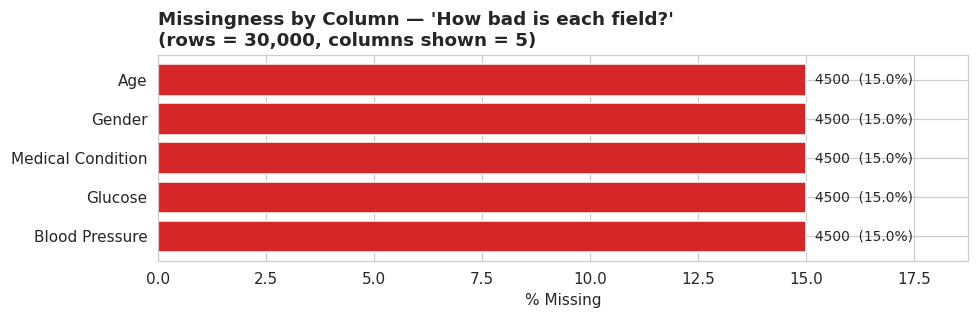

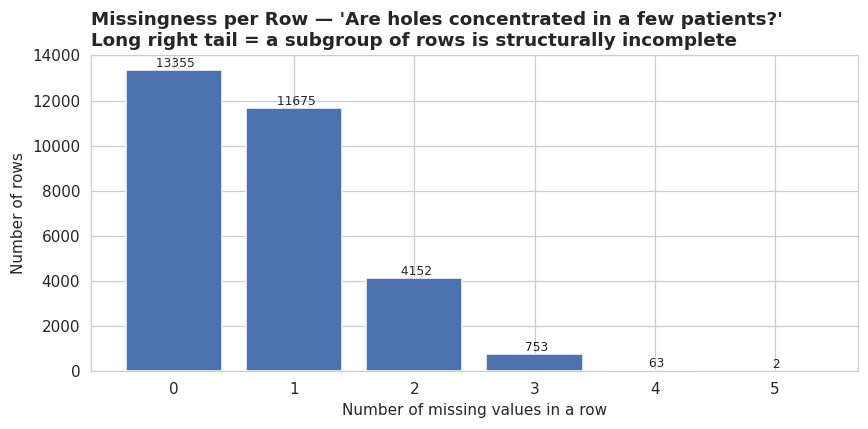

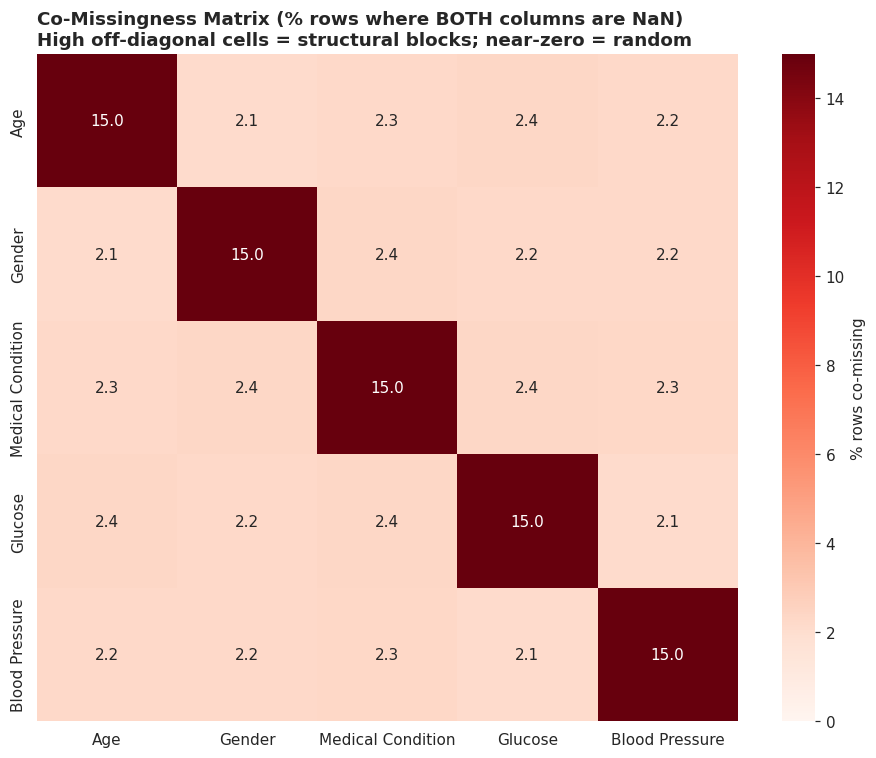

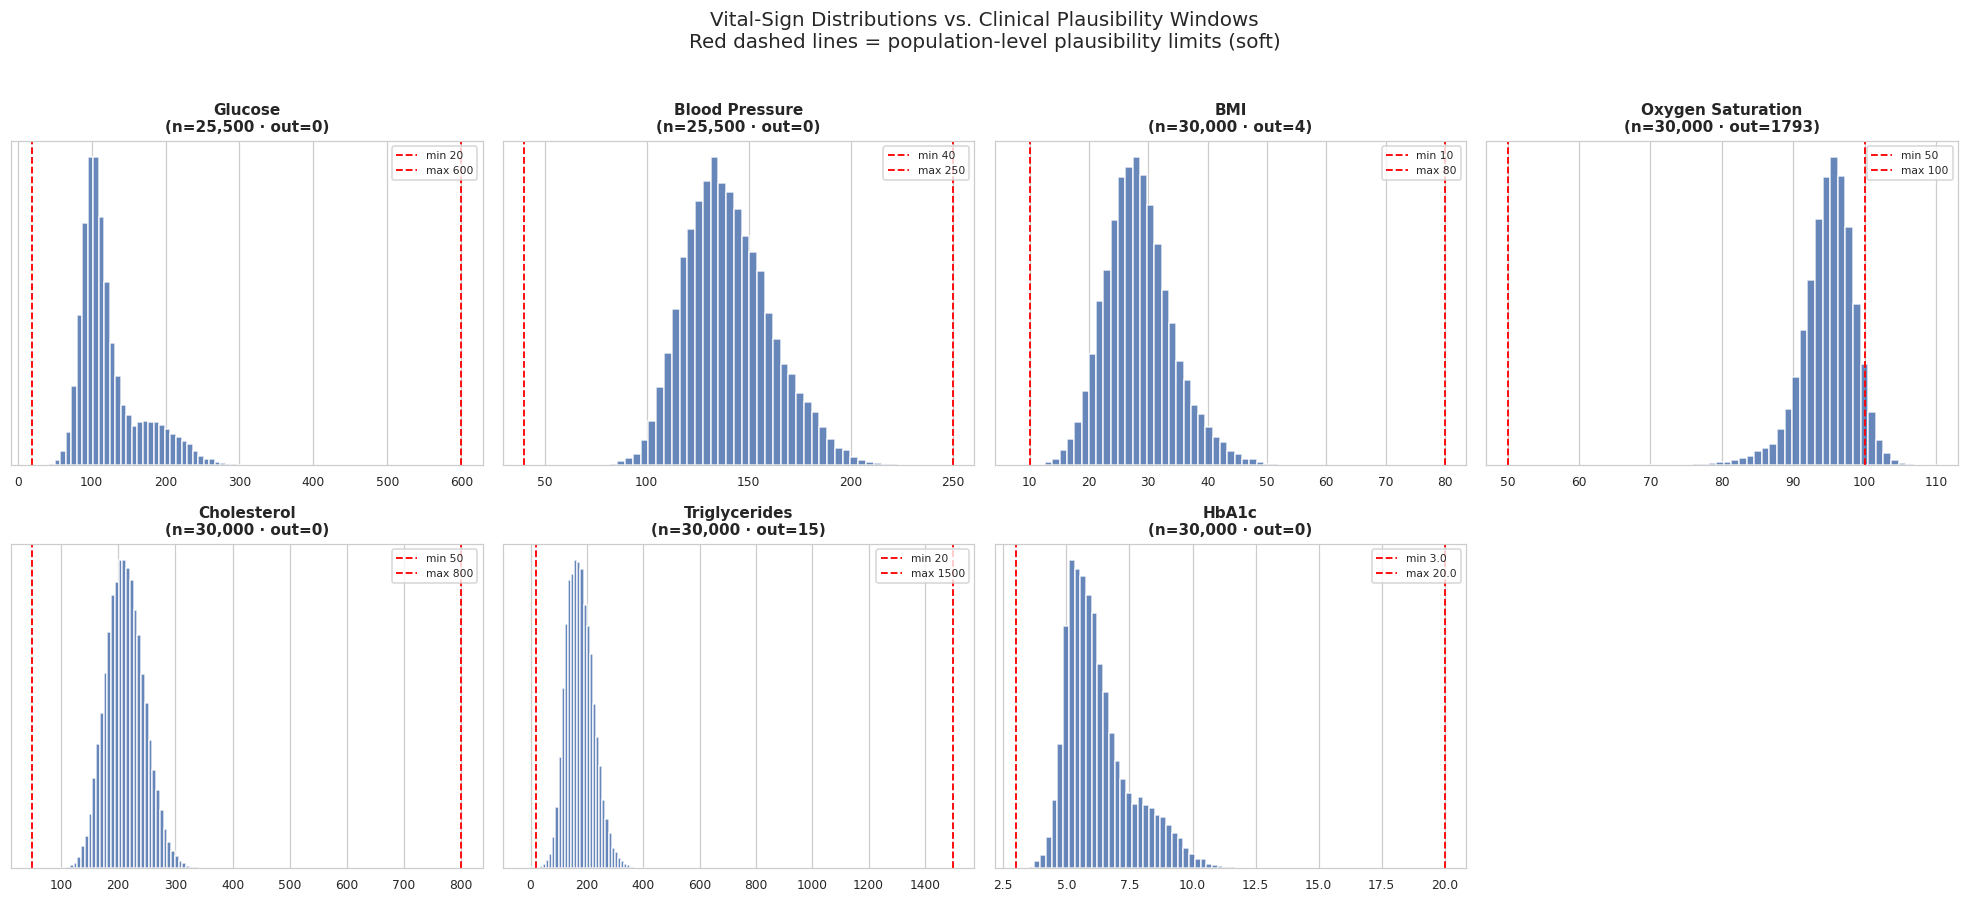

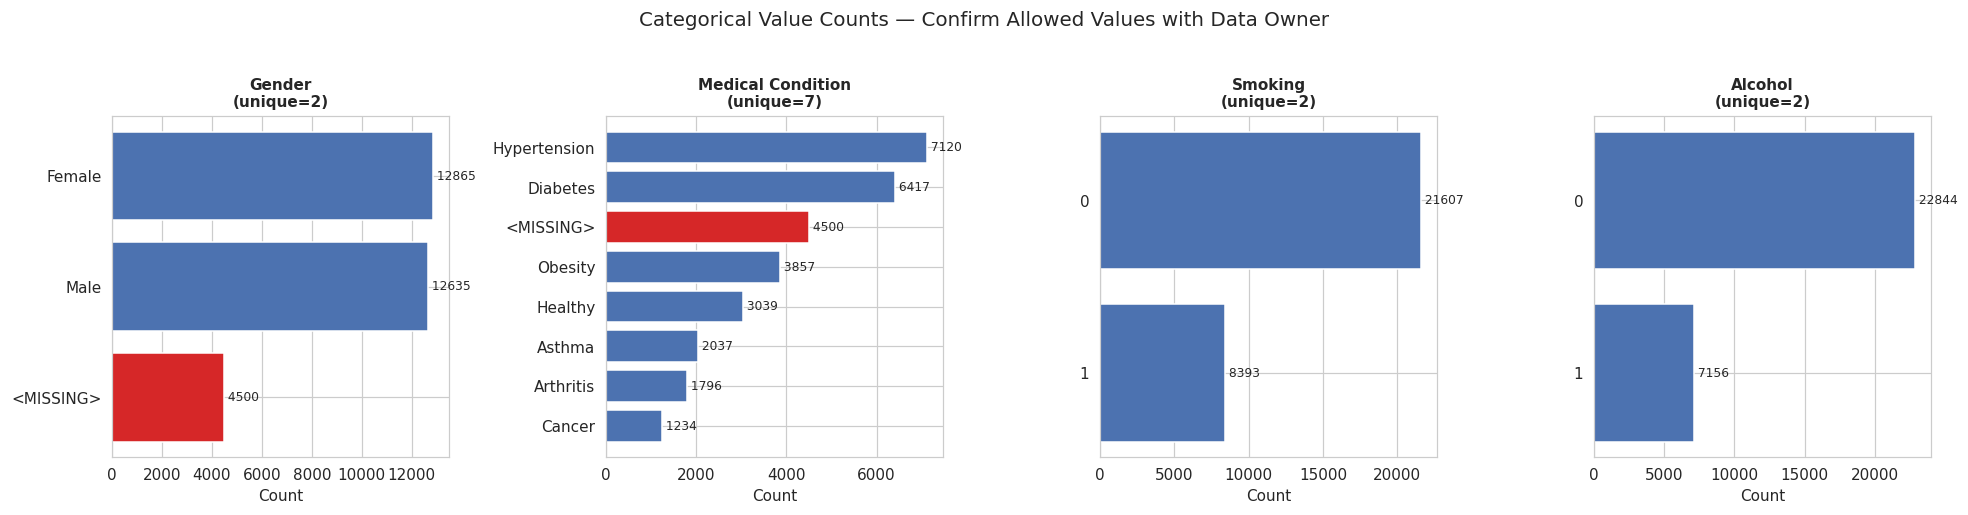

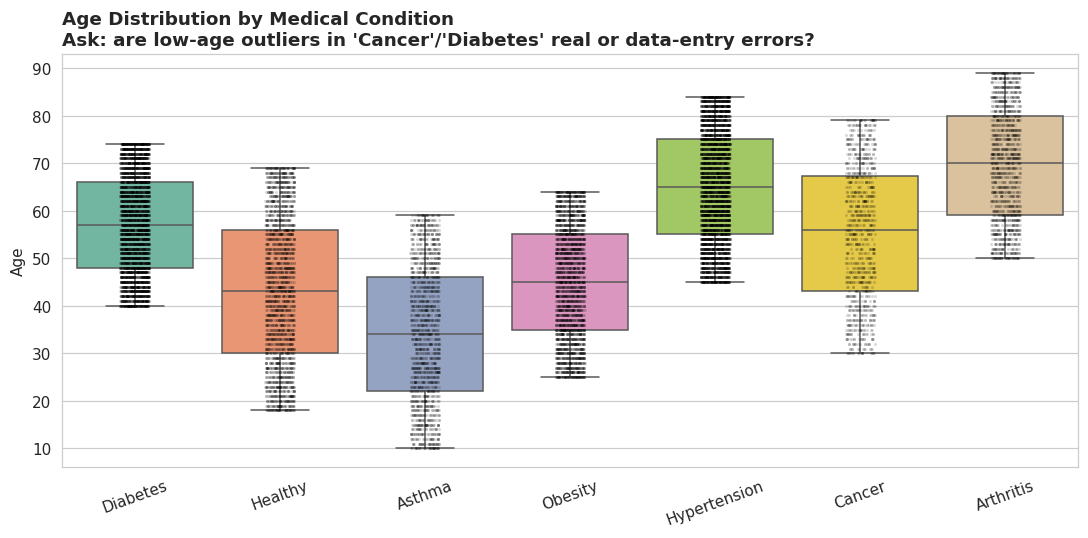

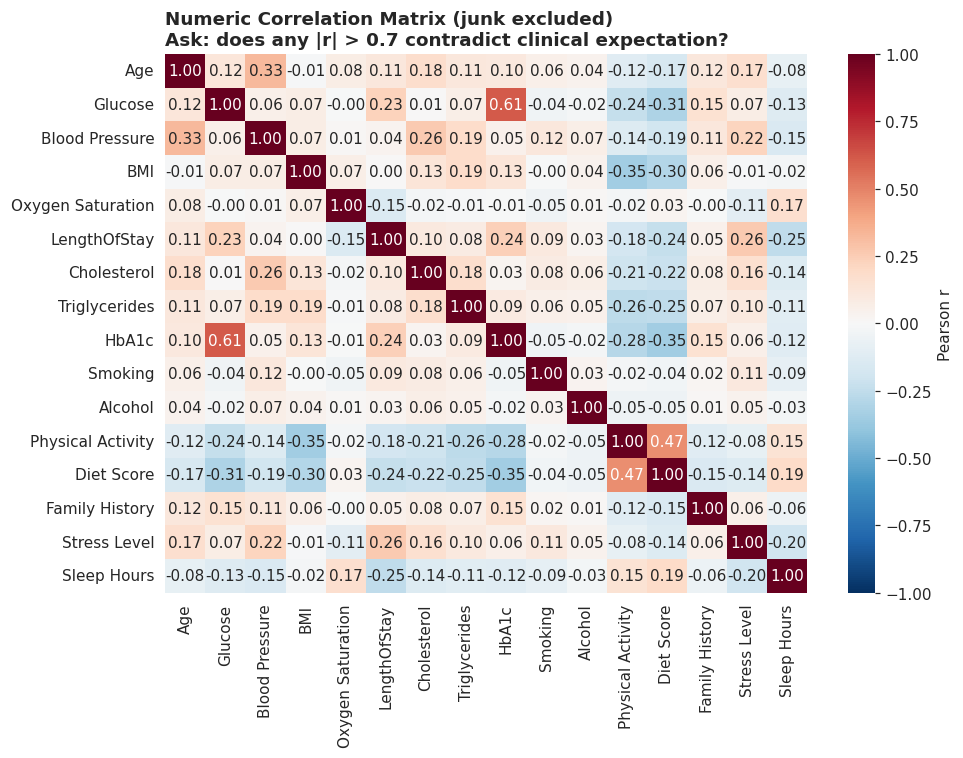

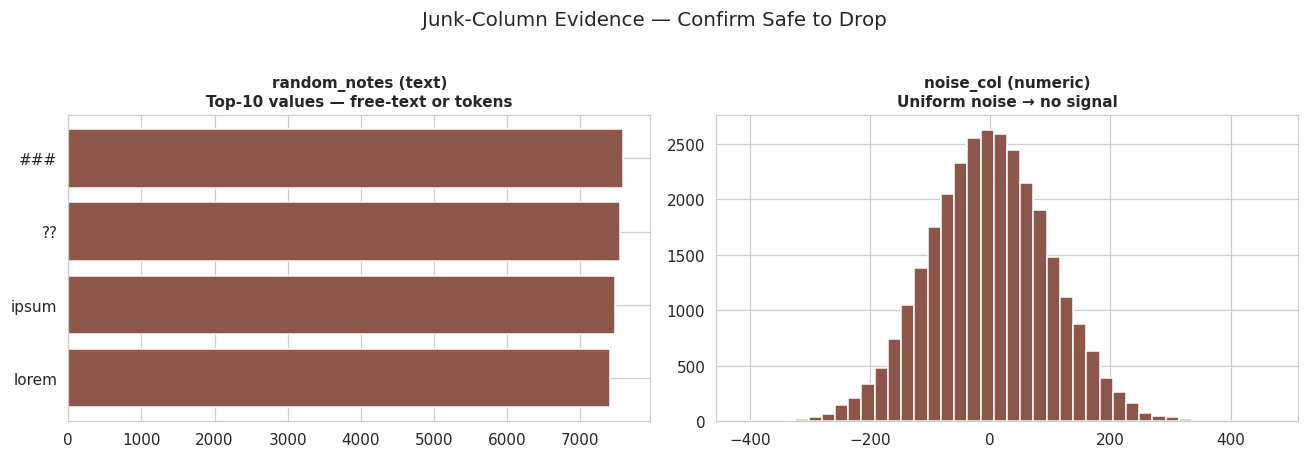


DATA RECON SUMMARY — 2026-09-24 05:02
Dataset         : dirty_v3_path.csv
Rows / Columns  : 30,000 / 20
Display schema  : df_plot (junk excluded) = 18 columns

TOP FINDINGS FOR DATA-OWNER RECONFIRMATION
--------------------------------------------------------------------------------
1. IMPOSSIBLE VALUES
   - Oxygen Saturation > 100     : 1793 rows
   - Negative Age                : 0 rows
   - Zero Blood Pressure         : 0 rows

2. MISSINGNESS (structural vs. clinical?)
   - Columns with any missing    : 5
   - Highest missing rate column : Age (15.0%)

3. CATEGORICALS TO CONFIRM
   - Gender values               : ['Female', 'Male']
   - Medical Conditions          : ['Arthritis', 'Asthma', 'Cancer', 'Diabetes', 'Healthy', 'Hypertension', 'Obesity']

4. JUNK COLUMNS (propose drop — display only)
   - ['noise_col', 'random_notes']

5. CLINICAL CONTEXT QUESTIONS
   - Should HbA1c > 20 be retained (rare cases up to 60% exist)?
   - Should Triglycerides > 1500 be retained (familial chyl

In [9]:
# ============================================================
# BLOCK 1.13 — VISUAL RECON FOR STAKEHOLDER DIALOGUE
# ============================================================
# Purpose:
#   Transform raw "dirtiness" metrics into VISUAL EVIDENCE that a
#   clinician or data owner can review in <5 minutes and comment on.
#
#   Each plot is chosen to surface a SPECIFIC question that only
#   the domain expert can answer. We are not deciding — we are
#   facilitating a review meeting.
#
# Design principles (best practice):
#   1. ONE question per plot (avoid "kitchen sink" dashboards)
#   2. Add reference lines for known clinical thresholds
#   3. Highlight out-of-range values in a distinct color (red)
#   4. Annotate counts so the reviewer sees the SCALE at a glance
#   5. Save each figure — a PDF report is what you bring to the meeting
#   6. Sanitize the DISPLAY schema BEFORE plotting (Block 1.13.0)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from datetime import datetime

# Consistent style so all plots look like a single report
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'


# ------------------------------------------------------------
# 1.13.0  Helper: save + display in one call
# ------------------------------------------------------------
# Why: In Colab you want BOTH inline display AND a saved artifact
# to attach to your data-quality report / Slack message / ticket.
def show_and_save(fig, name):
    fig.tight_layout()
    fig.savefig(f"{name}.png", dpi=120, bbox_inches='tight')
    plt.show()


# ============================================================
# 1.13.1  PRE-PLOT SANITIZATION
# ============================================================
# Purpose:
#   Remove columns that (a) carry no clinical signal and (b) degrade
#   plot readability. This is NOT the full cleaning step — it is a
#   DISPLAY-ONLY drop so the data-owner review plots are legible.
#
# Why this matters:
#   - noise_col ranges in ±300 while vitals sit in 0–250 → every
#     shared-axis plot gets squashed into an unreadable sliver.
#   - random_notes has near-100% cardinality → clogs categorical
#     bar charts with unusable "unique values".
#
# Rule: Junk detection happens in 1.1–1.12. Junk removal for
#       visualization happens HERE, before the first plt call.
#       df_raw is preserved untouched for the cleaning pipeline.
# ============================================================

# ------------------------------------------------------------
# 1.13.1.1  Programmatic junk detection (don't hardcode blindly)
# ------------------------------------------------------------
# Why: You *think* the junk is just ['random_notes', 'noise_col'].
# But hardcoding is fragile — if the file changes, you miss new junk.
# Better: detect candidates via heuristics, then confirm against
# a manual list before removal.
def detect_junk_candidates(df, max_unique_ratio=0.95, constant_threshold=1):
    """
    Return candidate junk columns using three heuristics:
      1. Constant columns (only one unique value)
      2. Near-100% unique columns with object dtype (likely IDs / free text)
      3. Columns whose name suggests synthetic filler
    """
    n = len(df)
    candidates = {}

    for col in df.columns:
        n_unique = df[col].nunique(dropna=True)
        ratio = n_unique / n if n > 0 else 0

        reasons = []
        if n_unique <= constant_threshold:
            reasons.append("constant")
        if df[col].dtype == object and ratio > max_unique_ratio:
            reasons.append(f"high_cardinality_text ({ratio:.0%} unique)")
        if any(tok in col.lower() for tok in ['noise', 'random', 'junk', 'temp']):
            reasons.append("suspicious_name")

        if reasons:
            candidates[col] = reasons

    return candidates


junk_candidates_detected = detect_junk_candidates(df_raw)

print("=" * 70)
print("1.13.1.1  AUTO-DETECTED JUNK CANDIDATES")
print("=" * 70)
if junk_candidates_detected:
    for col, reasons in junk_candidates_detected.items():
        print(f"  • {col:20s} → {', '.join(reasons)}")
else:
    print("  (none detected by heuristics)")


# ------------------------------------------------------------
# 1.13.1.2  Manual confirmation list
# ------------------------------------------------------------
# Why: Auto-detection can over-trigger. In a real review, the analyst
# confirms the drop list with the data owner BEFORE removal.
# For this notebook, we take the union of detected + known-junk.
JUNK_COLUMNS = sorted(set(junk_candidates_detected) | {'random_notes', 'noise_col'})
JUNK_COLUMNS = [c for c in JUNK_COLUMNS if c in df_raw.columns]

print("\n" + "=" * 70)
print("1.13.1.2  JUNK COLUMNS TO EXCLUDE FROM VISUALIZATION")
print("=" * 70)
print(f"  Columns dropped for plots only: {JUNK_COLUMNS}")
print(f"  Retained for downstream cleaning: {len(df_raw.columns) - len(JUNK_COLUMNS)} columns")


# ------------------------------------------------------------
# 1.13.1.3  Create the display-only view
# ------------------------------------------------------------
# Why: We create df_plot as a SEPARATE DataFrame.
#   - df_raw  → preserved untouched for the full cleaning pipeline
#   - df_plot → sanitized schema used ONLY for stakeholder plots
#
# Critical: the visualization drop must NOT leak into the actual
# cleaning pipeline, because the data owner may decide to keep a
# "junk" column (e.g., random_notes might be a real notes field).
df_plot = df_raw.drop(columns=JUNK_COLUMNS, errors='ignore').copy()

print(f"\n  df_raw  : {df_raw.shape}")
print(f"  df_plot : {df_plot.shape}  ← use this for ALL plots below")


# ============================================================
# 1.13.2 (REVISED) — MISSINGNESS: ZOOM-OUT / ZOOM-IN / TABULATE
# ============================================================
# Why the original heatmap failed:
#   • It plotted row-by-row for 3,000+ rows — missing values became
#     1-pixel slivers indistinguishable from background.
#   • Inverted color logic made PRESENT look like the "signal" and
#     MISSING look like noise, when the opposite is intended.
#   • It tried to answer two questions (structural vs. random) in
#     one plot, and answered neither well.
#
# The fix: three plots, one question each.
#   Plot A (zoom-out) : which columns are missing, and how much?
#   Plot B (zoom-in)  : for the worst column, WHERE are the holes?
#   Plot C (tabulate): do missing values cluster by another column?
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ---- Pre-compute the missingness summary once ----
missing_count = df_plot.isna().sum()
missing_pct   = (missing_count / len(df_plot) * 100).round(2)
miss_df = (pd.DataFrame({'missing': missing_count, 'pct': missing_pct})
             .query("missing > 0")
             .sort_values('pct', ascending=False))


# ------------------------------------------------------------
# PLOT A — Column-level missingness bar chart (zoom-out)
# ------------------------------------------------------------
# Question for the data owner:
#   "Which columns are missing, and how bad is each one?"
#
# This replaces the heatmap for the "overview" role. It shows
# the SCALE at a glance — you instantly see that e.g. Glucose
# is 8% missing while Gender is 2% missing.
if not miss_df.empty:
    fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(miss_df))))
    bars = ax.barh(miss_df.index[::-1], miss_df['pct'][::-1], color='#d62728')

    # Annotate: count + percentage on each bar
    for i, (col, row) in enumerate(miss_df[::-1].iterrows()):
        ax.text(row['pct'] + 0.2, i,
                f"{int(row['missing'])}  ({row['pct']}%)",
                va='center', fontsize=9)

    ax.set_xlabel("% Missing")
    ax.set_title(
        "Missingness by Column — 'How bad is each field?'\n"
        f"(rows = {len(df_plot):,}, columns shown = {len(miss_df)})",
        loc='left'
    )
    ax.set_xlim(0, max(miss_df['pct'].max() * 1.25, 5))
    show_and_save(fig, "recon_1a_missingness_by_column")
else:
    print("No missing values — skip Plot A.")


# ------------------------------------------------------------
# PLOT B — Row-level missingness density (zoom-in)
# ------------------------------------------------------------
# Question for the data owner:
#   "Are missing values spread evenly across patients, or do
#    they cluster in a subset of rows (which would suggest a
#    broken export for those patients)?"
#
# Instead of a per-row heatmap, we aggregate:
#   "how many columns are missing per row?"
# That collapses 3,000 rows into a histogram with a handful of bars.
row_missing = df_plot.isna().sum(axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
vc = row_missing.value_counts().sort_index()
ax.bar(vc.index, vc.values, color='#4c72b0', edgecolor='white')

for x, y in zip(vc.index, vc.values):
    ax.text(x, y, f" {y}", ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Number of missing values in a row")
ax.set_ylabel("Number of rows")
ax.set_title(
    "Missingness per Row — 'Are holes concentrated in a few patients?'\n"
    "Long right tail = a subgroup of rows is structurally incomplete",
    loc='left'
)
show_and_save(fig, "recon_1b_missingness_per_row")


# ------------------------------------------------------------
# PLOT C — Missingness co-occurrence heatmap (tabulate)
# ------------------------------------------------------------
# Question for the data owner:
#   "Do missing values in one column tend to co-occur with
#    missing values in another? (structural, not random)"
#
# Instead of a huge row-by-row heatmap, we compute a small
# COLUMN × COLUMN co-missingness matrix:
#   cell[i,j] = % of rows where BOTH column i and column j are missing
#
# This is tiny (e.g., 5×5 for your data) and readable.
if len(miss_df) >= 2:
    cols_with_miss = miss_df.index.tolist()
    n = len(cols_with_miss)
    co = np.zeros((n, n))
    for i, ci in enumerate(cols_with_miss):
        for j, cj in enumerate(cols_with_miss):
            co[i, j] = (df_plot[ci].isna() & df_plot[cj].isna()).mean() * 100

    fig, ax = plt.subplots(figsize=(1.1 * n + 3, 1.0 * n + 2))
    sns.heatmap(
        pd.DataFrame(co, index=cols_with_miss, columns=cols_with_miss),
        annot=True, fmt=".1f", cmap='Reds',
        cbar_kws={'label': '% rows co-missing'}, ax=ax,
        vmin=0
    )
    ax.set_title(
        "Co-Missingness Matrix (% rows where BOTH columns are NaN)\n"
        "High off-diagonal cells = structural blocks; near-zero = random",
        loc='left'
    )
    show_and_save(fig, "recon_1c_comissingness_matrix")


# ------------------------------------------------------------
# 1.13.3  Vital-sign distributions with clinical reference lines
# ------------------------------------------------------------
# The question for the data owner:
#   "Do these distributions look like a real clinic population,
#    or is there a systematic shift (e.g., unit error)?"
#
# Reference lines mark rough physiologic plausibility limits.
# Anything LEFT of the min-line or RIGHT of the max-line is a
# candidate for review — but NOT automatic deletion.
#
# IMPORTANT: sharex=False / sharey=False forces each subplot to
# auto-scale to its own data. Without this, the widest-range
# column (e.g., Triglycerides) squashes every other plot.
vitals = {
    'Glucose':           (20,   600),
    'Blood Pressure':    (40,   250),
    'BMI':               (10,    80),
    'Oxygen Saturation': (50,   100),
    'Cholesterol':       (50,   800),
    'Triglycerides':     (20,  1500),
    'HbA1c':             (3.0,  20.0),
}
vitals = {k: v for k, v in vitals.items() if k in df_plot.columns}

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for i, (col, (lo, hi)) in enumerate(vitals.items()):
    s = pd.to_numeric(df_plot[col], errors='coerce').dropna()
    ax = axes[i]
    ax.hist(s, bins=40, color='#4c72b0', edgecolor='white', alpha=0.85)
    ax.axvline(lo, color='red', linestyle='--', linewidth=1.2, label=f'min {lo}')
    ax.axvline(hi, color='red', linestyle='--', linewidth=1.2, label=f'max {hi}')

    n_out = int(((s < lo) | (s > hi)).sum())
    ax.set_title(f"{col}\n(n={len(s):,} · out={n_out})", fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=8)

for j in range(len(vitals), len(axes)):
    axes[j].axis('off')

fig.suptitle(
    "Vital-Sign Distributions vs. Clinical Plausibility Windows\n"
    "Red dashed lines = population-level plausibility limits (soft)",
    fontsize=13, y=1.02
)
show_and_save(fig, "recon_2_vital_distributions")


# ------------------------------------------------------------
# 1.13.4  Categorical cleanliness — "Any unexpected categories?"
# ------------------------------------------------------------
# The question for the data owner:
#   "Are these categories exactly the ones you expect?"
#
# Common findings that require owner input:
#   - A blank string category (should it be NaN? 'Unknown'? 'Other'?)
#   - A category that appears only 1–2 times (typo? special case?)
cats_to_check = ['Gender', 'Medical Condition', 'Smoking', 'Alcohol']
cats_to_check = [c for c in cats_to_check if c in df_plot.columns]

# Cap categoricals at <= 15 unique values — anything more is not
# a real categorical and should be inspected separately.
cats_to_check = [c for c in cats_to_check
                  if df_plot[c].nunique(dropna=True) <= 15]

if cats_to_check:
    n_cols = len(cats_to_check)
    fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 4.5))
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, cats_to_check):
        vc = df_plot[col].value_counts(dropna=False).head(12)
        labels = ['<MISSING>' if pd.isna(x) else str(x) for x in vc.index]
        colors = ['#d62728' if l == '<MISSING>' else '#4c72b0' for l in labels]

        ax.barh(labels[::-1], vc.values[::-1], color=colors[::-1])
        ax.set_title(f"{col}\n(unique={df_plot[col].nunique(dropna=True)})",
                     fontsize=10)
        ax.set_xlabel("Count")
        for i, v in enumerate(vc.values[::-1]):
            ax.text(v, i, f" {v}", va='center', fontsize=8)

    fig.suptitle(
        "Categorical Value Counts — Confirm Allowed Values with Data Owner",
        fontsize=13, y=1.03
    )
    show_and_save(fig, "recon_3_categoricals")


# ------------------------------------------------------------
# 1.13.5  Age vs. Medical Condition — "Any impossible combos?"
# ------------------------------------------------------------
# The question for the data owner:
#   "Is a 13-year-old with 'Obesity' or an 18-year-old with 'Cancer'
#    a real patient, or a data-entry error?"
#
# These aren't necessarily wrong — pediatric obesity and
# adolescent oncology exist — but they are WORTH RECONFIRMING.
if {'Age', 'Medical Condition'} <= set(df_plot.columns):
    fig, ax = plt.subplots(figsize=(10, 5))
    plot_df = df_plot[['Age', 'Medical Condition']].dropna()
    sns.boxplot(
        data=plot_df, x='Medical Condition', y='Age',
        ax=ax, palette='Set2'
    )
    sns.stripplot(
        data=plot_df, x='Medical Condition', y='Age',
        ax=ax, color='black', alpha=0.15, size=2
    )
    ax.set_title(
        "Age Distribution by Medical Condition\n"
        "Ask: are low-age outliers in 'Cancer'/'Diabetes' real or data-entry errors?",
        loc='left'
    )
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)
    show_and_save(fig, "recon_4_age_by_condition")


# ------------------------------------------------------------
# 1.13.6  Correlation heatmap — "Any nonsensical relationships?"
# ------------------------------------------------------------
# The question for the data owner:
#   "Do any correlations look clinically absurd?
#    (e.g., BMI strongly negatively correlated with Age)"
#
# A nonsensical correlation often means a column is mislabeled,
# unit-shifted, or synthetic — worth flagging.
#
# NOTE: df_plot already excludes noise_col, so the matrix shows
# only clinical variables. That's the fix for the earlier
# readability problem where noise flattened all real correlations.
num_df = df_plot.select_dtypes(include=[np.number])

if num_df.shape[1] >= 3:
    fig, ax = plt.subplots(figsize=(9, 7))
    corr = num_df.corr(numeric_only=True)
    sns.heatmap(
        corr, annot=True, fmt=".2f", cmap='RdBu_r',
        center=0, vmin=-1, vmax=1,
        cbar_kws={'label': 'Pearson r'}, ax=ax
    )
    ax.set_title(
        "Numeric Correlation Matrix (junk excluded)\n"
        "Ask: does any |r| > 0.7 contradict clinical expectation?",
        loc='left'
    )
    show_and_save(fig, "recon_5_correlation")


# ------------------------------------------------------------
# 1.13.7  Junk-column evidence — "Why we propose dropping these"
# ------------------------------------------------------------
# The question for the data owner:
#   "Can we confirm these columns are not needed downstream?"
#
# For each candidate junk column we show either:
#   - high-cardinality free text (random_notes), or
#   - random uniform distribution (noise_col)
# Both are visual proof that they carry no clinical signal.
#
# INTENTIONAL EXCEPTION: this plot uses df_raw (not df_plot)
# because its whole purpose is to prove why these columns are junk.
junk_candidates = [c for c in ['random_notes', 'noise_col'] if c in df_raw.columns]

if junk_candidates:
    fig, axes = plt.subplots(1, len(junk_candidates),
                             figsize=(6 * len(junk_candidates), 4))
    if len(junk_candidates) == 1:
        axes = [axes]

    for ax, col in zip(axes, junk_candidates):
        if df_raw[col].dtype.kind in 'ifc':   # numeric
            ax.hist(df_raw[col].dropna(), bins=40,
                    color='#8c564b', edgecolor='white')
            ax.set_title(f"{col} (numeric)\nUniform noise → no signal",
                         fontsize=10)
        else:                                   # text
            vc = df_raw[col].value_counts(dropna=False).head(10)
            ax.barh(vc.index.astype(str)[::-1], vc.values[::-1],
                    color='#8c564b')
            ax.set_title(f"{col} (text)\nTop-10 values — free-text or tokens",
                         fontsize=10)
        ax.set_xlabel("")

    fig.suptitle("Junk-Column Evidence — Confirm Safe to Drop",
                 fontsize=13, y=1.03)
    show_and_save(fig, "recon_6_junk_columns")


# ------------------------------------------------------------
# 1.13.8  Build a one-page "Recon Summary Card"
# ------------------------------------------------------------
# The final artifact for the meeting: a single-page card the data
# owner can sign off on. This is what turns a 60-minute meeting
# into a 15-minute one.
#
# NOTE: uses df_raw for numeric counts (so the "impossible values"
# reflect the raw file), but references df_plot for the display
# schema decisions.

# Safe lookup for highest-missing column (avoid KeyError if clean)
missing_cols = [c for c in df_raw.columns if df_raw[c].isna().any()]
if missing_cols:
    highest_missing_col = (df_raw[missing_cols].isna().mean() * 100).idxmax()
    highest_missing_pct = round((df_raw[highest_missing_col].isna().mean() * 100), 2)
else:
    highest_missing_col = "—"
    highest_missing_pct = 0.0

summary_card = f"""
================================================================================
DATA RECON SUMMARY — {datetime.now().strftime('%Y-%m-%d %H:%M')}
================================================================================
Dataset         : dirty_v3_path.csv
Rows / Columns  : {df_raw.shape[0]:,} / {df_raw.shape[1]}
Display schema  : df_plot (junk excluded) = {df_plot.shape[1]} columns

TOP FINDINGS FOR DATA-OWNER RECONFIRMATION
--------------------------------------------------------------------------------
1. IMPOSSIBLE VALUES
   - Oxygen Saturation > 100     : {int((pd.to_numeric(df_raw['Oxygen Saturation'], errors='coerce') > 100).sum())} rows
   - Negative Age                : {int((pd.to_numeric(df_raw['Age'], errors='coerce') < 0).sum())} rows
   - Zero Blood Pressure         : {int((pd.to_numeric(df_raw['Blood Pressure'], errors='coerce') == 0).sum())} rows

2. MISSINGNESS (structural vs. clinical?)
   - Columns with any missing    : {df_raw.isna().any().sum()}
   - Highest missing rate column : {highest_missing_col} ({highest_missing_pct}%)

3. CATEGORICALS TO CONFIRM
   - Gender values               : {sorted(df_plot['Gender'].dropna().unique().tolist()) if 'Gender' in df_plot else 'N/A'}
   - Medical Conditions          : {sorted(df_plot['Medical Condition'].dropna().unique().tolist()) if 'Medical Condition' in df_plot else 'N/A'}

4. JUNK COLUMNS (propose drop — display only)
   - {JUNK_COLUMNS}

5. CLINICAL CONTEXT QUESTIONS
   - Should HbA1c > 20 be retained (rare cases up to 60% exist)?
   - Should Triglycerides > 1500 be retained (familial chylomicronemia)?
   - Is BP = 0 a known EHR device artifact?

================================================================================
"""
print(summary_card)

In [10]:
# ============================================================
# BLOCK 2 — CLINICAL BOUNDARY CONTRACT (SOFT RULES)
# ============================================================
# Purpose:
#   Define the *contract* between the analyst and the data owner
#   about what counts as "clinically plausible" for each field.
#   Every value outside a bound is FLAGGED, not deleted — so we
#   can audit, discuss, and revise without losing raw information.
#
# Why "contract" and not "rules":
#   Bounds are not universal truths. They depend on:
#     - Population (pediatric vs. adult vs. ICU vs. outpatient)
#     - Setting (tertiary referral center sees more extremes)
#     - Time (assay methods evolve; historical data differs)
#   Treating them as a contract makes that dependency explicit.
#
# What this block does NOT do:
#   It does NOT modify any values. It does NOT drop any rows.
#   It ONLY computes boolean flag columns alongside the data.
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 2.1  TIER SYSTEM — two levels of "suspicious"
# ------------------------------------------------------------
# Why two tiers:
#   Tier 1 (HARD) — physiologically impossible. No human alive
#     has O2 saturation > 100% or a negative age. These are
#     unambiguously data errors (device, unit, entry).
#
#   Tier 2 (SOFT) — plausible range. Values outside this range
#     are unusual but can be real (e.g., HbA1c = 22% in DKA,
#     Triglycerides = 2500 in familial chylomicronemia).
#     These MUST be reviewed, not silently dropped.
#
# This separation drives everything downstream:
#   • Tier 1 flags → candidates for NULLING in Block 5
#   • Tier 2 flags → retained + flagged for analyst review
# ------------------------------------------------------------

# Tier 1 — HARD IMPOSSIBILITIES (never valid for a living patient)
HARD_IMPOSSIBLE = {
    'Age':               (0,    120),    # no living patient is -1 or 200
    'Oxygen Saturation': (0,    100),    # saturation cannot exceed 100%
    'BMI':               (0,    np.inf), # BMI cannot be negative or zero
    'Blood Pressure':    (0,    np.inf), # BP cannot be negative or zero
    'Glucose':           (0,    np.inf), # glucose cannot be negative
    'HbA1c':             (0,    np.inf), # HbA1c cannot be negative
    'Sleep Hours':       (0,     24),    # cannot sleep > 24h/day
    'Physical Activity': (0,    168),    # cannot exercise > 168h/week
}

# Tier 2 — SOFT PLAUSIBILITY WINDOWS (population-level, not law)
# These are WIDER than typical clinical reference ranges on purpose.
# They catch typos and unit errors, not unusual-but-real pathology.
CLINICAL_BOUNDS = {
    'Age':               (0,    120),    # same as Tier 1 — no "plausible-but-suspicious" age
    'Glucose':           (20,   600),    # mmol/L vs mg/dL confusion caught at >600
    'Blood Pressure':    (40,   250),    # below 40 or above 250 = review
    'BMI':               (10,    80),    # >80 is rare; <10 is anorexia nervosa extreme
    'Oxygen Saturation': (50,   100),    # <50 incompatible with life outside ICU
    'Cholesterol':       (50,   800),    # >800 = possible unit error
    'Triglycerides':     (20,  1500),    # >1500 = real (chylomicronemia) but review
    'HbA1c':             (3.0,   20.0),  # >20% exists (rare case: 61.5%) but review
    'Physical Activity': (0,    168),
    'Sleep Hours':       (0,     24),
    'LengthOfStay':      (0,    365),    # >365 days = possible unit error (months vs days)
    'Diet Score':        (0,     10),
    'Stress Level':      (0,     10),
}


# ------------------------------------------------------------
# 2.2  Contextual bounds — population-specific overrides
# ------------------------------------------------------------
# Why: A single global bound is wrong for heterogeneous data.
# If your dataset includes pediatric or ICU rows, you need
# OVERRIDES that only apply to that subset.
#
# Example design (extend as needed):
#   - Pediatric cohort (Age < 18): different HR/BP norms
#   - ICU cohort: BP can legitimately drop below 40 (vasopressors)
#   - Cancer cohort: LOS can legitimately exceed 365
#
# The structure is: {column: {(row_filter_fn, condition_name): (lo, hi)}}
# Each override is checked AFTER the global bound.
CONTEXTUAL_OVERRIDES = {
    'LengthOfStay': [
        # Cancer patients can have very long stays — widen the window
        (lambda df: df.get('Medical Condition') == 'Cancer', 'cancer_cohort', 0, 730),
        # ICU patients can have LOS in months
        (lambda df: df.get('Medical Condition') == 'Asthma', 'asthma_cohort', 0, 30),
    ],
    'Blood Pressure': [
        # Hypotension is expected in some subpopulations (not in this file,
        # but this is where you'd document it)
        # (lambda df: df['unit'] == 'ICU', 'icu_cohort', 20, 250),
    ],
}


# ------------------------------------------------------------
# 2.3  The flagging engine — one function, applied per column
# ------------------------------------------------------------
def flag_column(series, lo, hi):
    """
    Return a boolean mask: True where value is outside [lo, hi].
    Non-numeric values become NaN → not flagged (they're a separate
    problem handled by the type-validation layer).
    """
    s = pd.to_numeric(series, errors='coerce')
    return s.notna() & ((s < lo) | (s > hi))


def apply_hard_impossibility_flags(df, hard_bounds):
    """
    Tier 1: flag values that are physiologically impossible.
    Naming convention: flag_hard_<column>_impossible
    """
    df = df.copy()
    report = []

    for col, (lo, hi) in hard_bounds.items():
        if col not in df.columns:
            continue
        flag_col = f'flag_hard_{col.lower().replace(" ", "_")}_impossible'
        df[flag_col] = flag_column(df[col], lo, hi)

        n = int(df[flag_col].sum())
        report.append({
            'tier': 1,
            'column': col,
            'rule': f'{lo} <= x <= {hi}',
            'n_flagged': n,
            'pct_flagged': round(n / len(df) * 100, 3)
        })

    return df, pd.DataFrame(report)


def apply_soft_bound_flags(df, bounds):
    """
    Tier 2: flag values outside population-level plausibility windows.
    Naming convention: flag_soft_<column>_implausible
    """
    df = df.copy()
    report = []

    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue
        flag_col = f'flag_soft_{col.lower().replace(" ", "_")}_implausible'
        df[flag_col] = flag_column(df[col], lo, hi)

        n = int(df[flag_col].sum())
        report.append({
            'tier': 2,
            'column': col,
            'rule': f'{lo} <= x <= {hi}',
            'n_flagged': n,
            'pct_flagged': round(n / len(df) * 100, 3)
        })

    return df, pd.DataFrame(report)


# ------------------------------------------------------------
# 2.4  Apply Tier 1 (HARD) to the raw data
# ------------------------------------------------------------
# Note: we operate on df (the working copy), not df_raw.
# df_raw stays pristine for future audit.
df = df_raw.copy()

df, hard_report = apply_hard_impossibility_flags(df, HARD_IMPOSSIBLE)

print("=" * 78)
print("2.4  TIER 1 — HARD IMPOSSIBILITY FLAGS")
print("=" * 78)
print(hard_report.to_string(index=False))


# ------------------------------------------------------------
# 2.5  Apply Tier 2 (SOFT) to the raw data
# ------------------------------------------------------------
df, soft_report = apply_soft_bound_flags(df, CLINICAL_BOUNDS)

print("\n" + "=" * 78)
print("2.5  TIER 2 — SOFT PLAUSIBILITY FLAGS")
print("=" * 78)
print(soft_report.to_string(index=False))


# ------------------------------------------------------------
# 2.6  Apply contextual overrides (population-specific)
# ------------------------------------------------------------
# Why: Some patients legitimately exceed the population bound.
# We compute an override flag column that MARKS the widened
# rule for that subgroup — never silently widening it globally.
def apply_contextual_overrides(df, overrides):
    df = df.copy()
    report = []

    for col, rules in overrides.items():
        if col not in df.columns:
            continue
        for row_filter, condition_name, lo, hi in rules:
            try:
                mask = row_filter(df)
            except Exception:
                continue
            if not mask.any():
                continue

            flag_col = f'flag_ctx_{col.lower().replace(" ", "_")}_{condition_name}'
            s = pd.to_numeric(df[col], errors='coerce')
            # Only flag *this subpopulation's* out-of-override values
            df[flag_col] = mask & s.notna() & ((s < lo) | (s > hi))

            n = int(df[flag_col].sum())
            report.append({
                'column': col,
                'subgroup': condition_name,
                'widened_to': f'{lo}..{hi}',
                'n_flagged': n
            })

    return df, pd.DataFrame(report)


df, ctx_report = apply_contextual_overrides(df, CONTEXTUAL_OVERRIDES)

print("\n" + "=" * 78)
print("2.6  CONTEXTUAL OVERRIDE FLAGS (population-specific)")
print("=" * 78)
if not ctx_report.empty:
    print(ctx_report.to_string(index=False))
else:
    print("  (no overrides triggered in this dataset)")


# ------------------------------------------------------------
# 2.7  Consolidated flag summary — the "flag ledger"
# ------------------------------------------------------------
# Why: At any point in the pipeline we should be able to answer:
#   "How many rows have ANY hard-flag? ANY soft-flag?"
# This becomes the KPI for the data-quality dashboard.
hard_flag_cols = [c for c in df.columns if c.startswith('flag_hard_')]
soft_flag_cols = [c for c in df.columns if c.startswith('flag_soft_')]
ctx_flag_cols  = [c for c in df.columns if c.startswith('flag_ctx_')]

df['flag_any_hard'] = df[hard_flag_cols].any(axis=1) if hard_flag_cols else False
df['flag_any_soft'] = df[soft_flag_cols].any(axis=1) if soft_flag_cols else False

print("\n" + "=" * 78)
print("2.7  FLAG LEDGER — ROW-LEVEL SUMMARY")
print("=" * 78)
print(f"  Total rows                     : {len(df):,}")
print(f"  Rows with ANY hard flag        : {int(df['flag_any_hard'].sum()):,}  "
      f"({df['flag_any_hard'].mean()*100:.2f}%)")
print(f"  Rows with ANY soft flag        : {int(df['flag_any_soft'].sum()):,}  "
      f"({df['flag_any_soft'].mean()*100:.2f}%)")
print(f"  Rows with BOTH hard & soft     : "
      f"{int((df['flag_any_hard'] & df['flag_any_soft']).sum()):,}")
print(f"  Rows with NO flags (clean)     : "
      f"{int((~df['flag_any_hard'] & ~df['flag_any_soft']).sum()):,}")


# ------------------------------------------------------------
# 2.8  Per-column detail — eyeball the worst offenders
# ------------------------------------------------------------
# Why: A summary number isn't enough. We want to SEE the actual
# values that got flagged — because the data owner's next
# question will be "show me an example."
print("\n" + "=" * 78)
print("2.8  SAMPLE FLAGGED VALUES PER COLUMN")
print("=" * 78)

def show_flagged_examples(df, flag_col, source_col, n=5):
    mask = df[flag_col]
    if not mask.any():
        return
    samples = df.loc[mask, source_col].head(n).tolist()
    print(f"  {source_col:22s} → {samples}")

for col in ['Age', 'Glucose', 'Blood Pressure', 'BMI',
            'Oxygen Saturation', 'Cholesterol', 'Triglycerides',
            'HbA1c', 'Physical Activity', 'Sleep Hours']:
    flag = f'flag_soft_{col.lower().replace(" ", "_")}_implausible'
    if flag in df.columns:
        show_flagged_examples(df, flag, col)


# ------------------------------------------------------------
# 2.9  Export the flag contract for the data owner
# ------------------------------------------------------------
# Why: The bounds dictionary is a living document. It should be
# versioned, signed off, and stored alongside the dataset.
import json
from datetime import datetime

contract = {
    'generated_at': datetime.now().isoformat(),
    'dataset': 'dirty_v3_path.csv',
    'tier_1_hard_impossible': {k: list(v) for k, v in HARD_IMPOSSIBLE.items() if v[1] != np.inf},
    'tier_2_soft_plausibility': CLINICAL_BOUNDS,
    'contextual_overrides': [
        {'column': col, 'subgroup': name, 'range': [lo, hi]}
        for col, rules in CONTEXTUAL_OVERRIDES.items()
        for _, name, lo, hi in rules
    ],
    'note': (
        "These are population-level plausibility windows, not clinical "
        "decision thresholds. Real pathology may exceed them. All "
        "out-of-bound values are FLAGGED, never deleted."
    )
}

with open('clinical_boundary_contract.json', 'w') as f:
    json.dump(contract, f, indent=2)

print("\n" + "=" * 78)
print("2.9  CONTRACT EXPORTED → clinical_boundary_contract.json")
print("=" * 78)
print(json.dumps(contract, indent=2)[:1500] + "\n  ... (truncated)")

2.4  TIER 1 — HARD IMPOSSIBILITY FLAGS
 tier            column          rule  n_flagged  pct_flagged
    1               Age 0 <= x <= 120          0        0.000
    1 Oxygen Saturation 0 <= x <= 100       1793        5.977
    1               BMI 0 <= x <= inf          0        0.000
    1    Blood Pressure 0 <= x <= inf          0        0.000
    1           Glucose 0 <= x <= inf          0        0.000
    1             HbA1c 0 <= x <= inf          0        0.000
    1       Sleep Hours  0 <= x <= 24          0        0.000
    1 Physical Activity 0 <= x <= 168        302        1.007

2.5  TIER 2 — SOFT PLAUSIBILITY FLAGS
 tier            column             rule  n_flagged  pct_flagged
    2               Age    0 <= x <= 120          0        0.000
    2           Glucose   20 <= x <= 600          0        0.000
    2    Blood Pressure   40 <= x <= 250          0        0.000
    2               BMI    10 <= x <= 80          4        0.013
    2 Oxygen Saturation   50 <= x <= 10

3.5  CATEGORICAL STANDARDIZATION — RESULTS

  Gender → canonical: {'Female': 12865, 'Male': 12635, nan: 4500}

  Medical Condition → canonical: {'Hypertension': 7120, 'Diabetes': 6417, nan: 4500, 'Obesity': 3857, 'Healthy': 3039, 'Asthma': 2037, 'Arthritis': 1796, 'Cancer': 1234}

  Smoking → {0: 21607, 1: 8393}

  Alcohol → {0: 22844, 1: 7156}

  Family History → {0: 16817, 1: 13183}

3.6  TRANSFORMATION AUDIT — BEFORE vs. AFTER
           column  unique_before  unique_after  unknown_flagged
           Gender              2             2                0
Medical Condition              7             7                0
          Smoking              2             2                0
          Alcohol              2             2                0
   Family History              2             2                0


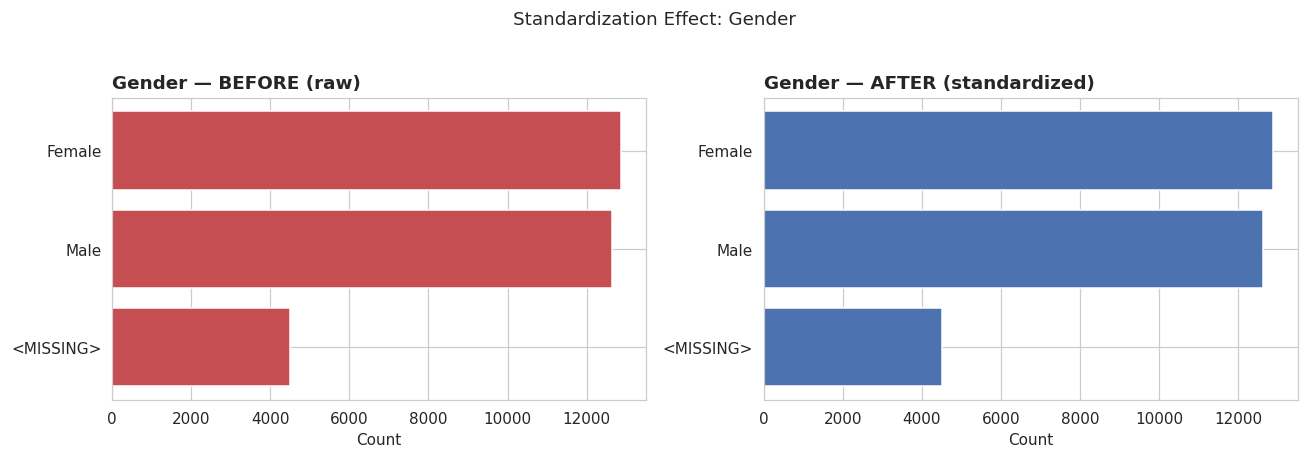

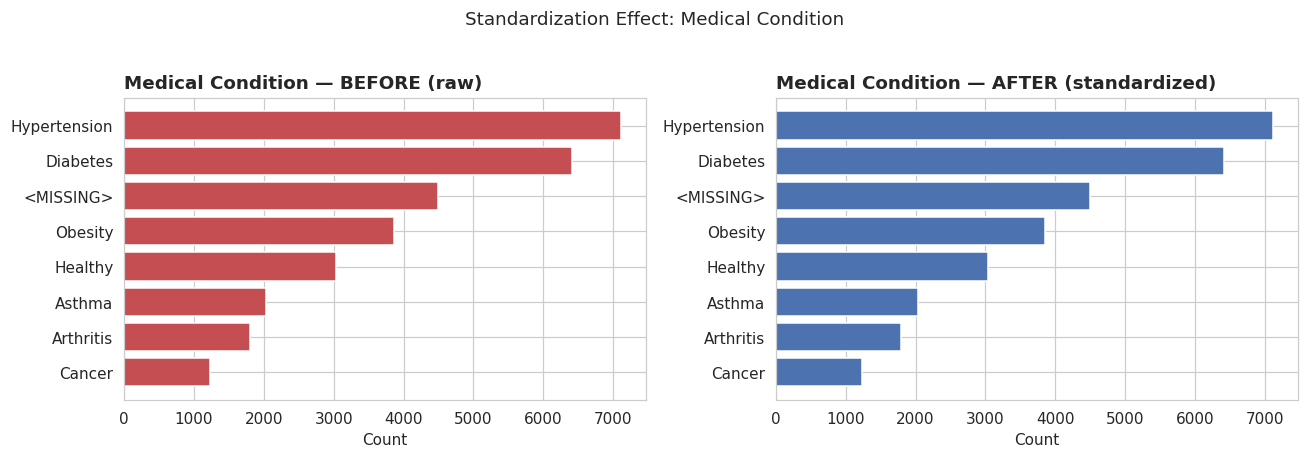

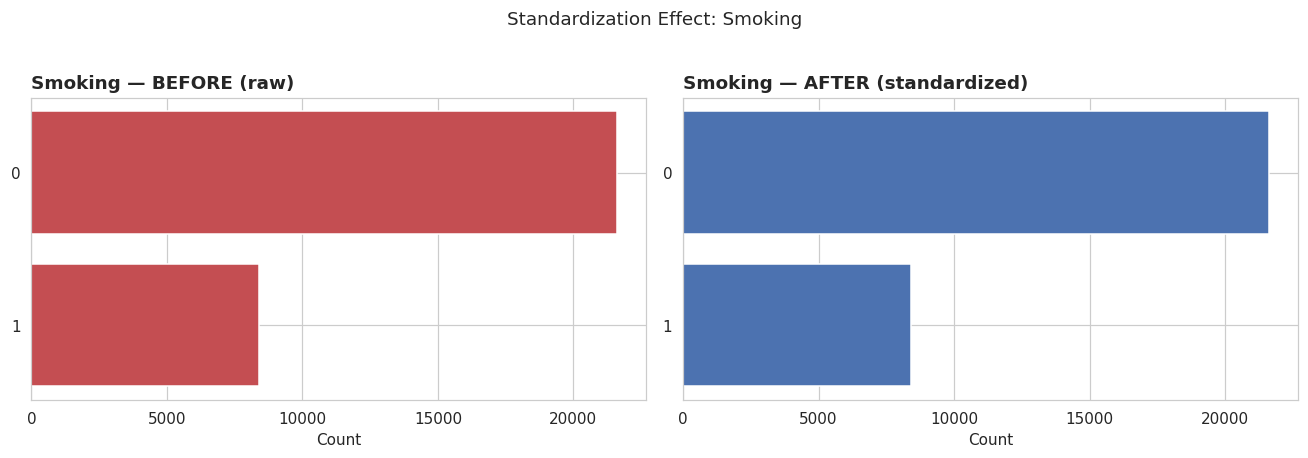

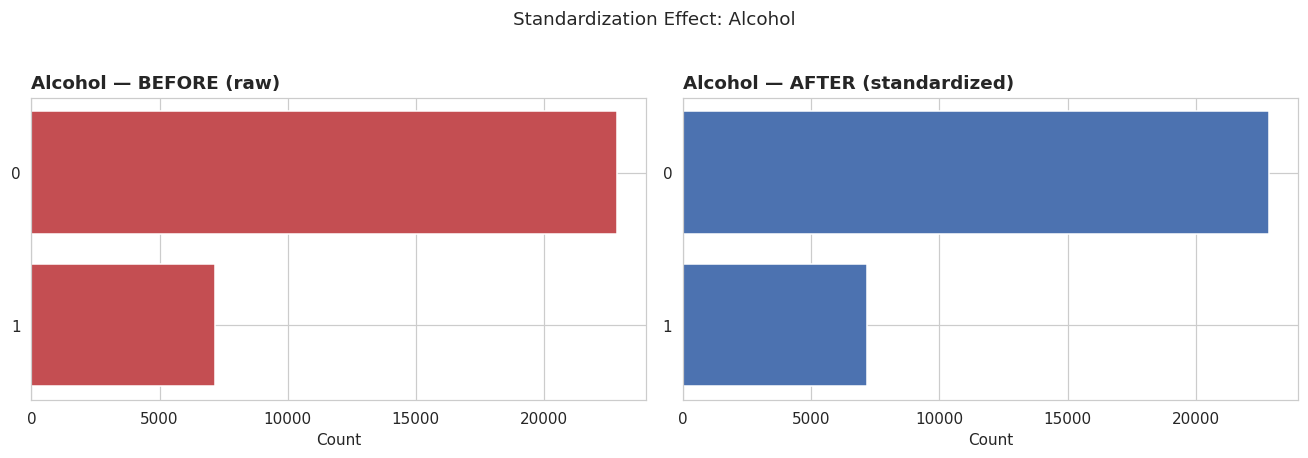


3.8  CONTRACT EXPORTED → categorical_contract.json
{
  "gender_map": {
    "m": "Male",
    "male": "Male",
    "man": "Male",
    "1": "Male",
    "f": "Female",
    "female": "Female",
    "woman": "Female",
    "0": "Female"
  },
  "condition_map": {
    "healthy": "Healthy",
    "diabetes": "Diabetes",
    "diabetic": "Diabetes",
    "hypertension": "Hypertension",
    "obesity": "Obesity",
    "obese": "Obesity",
    "asthma": "Asthma",
    "arthritis": "Arthritis",
    "cancer": "Cancer"
  },
  "binary_map": {
    "0": 0,
    "no": 0,
    "n": 0,
    "false": 0,
    "f": 0,
    "1": 1,
    "yes": 1,
    "y": 1,
    "true": 1,
    "t": 1
  },
  "null_tokens": [
    "",
    "nan",
    "none",
    "null",
    "n/a",
    "na",
    "?",
    "unknown"
  ],
  "note": "Mappings are case-insensitive. Unknown values are NOT coerced to NaN \u2014 they are flagged via flag_unknown_<column> columns. The raw values are preserved in <column>_raw.",
  "audit": [
    {
      "column": "Gender",


In [11]:
# ============================================================
# BLOCK 3 — CATEGORICAL STANDARDIZATION
# ============================================================
# Purpose:
#   Normalize categorical fields so that "Male", "male", "M", "Male "
#   collapse into a single canonical value. Surface unknown or
#   unexpected categories as FLAGS so the data owner can react,
#   instead of silently coercing them to NaN.
#
# Scope (from the recon in Block 1):
#   • Gender              → binary: Male / Female
#   • Medical Condition   → multi-class, canonical capitalized form
#   • Smoking             → binary: 0 / 1
#   • Alcohol             → binary: 0 / 1
#   • Family History      → binary: 0 / 1
#
# What this block does NOT do:
#   It does NOT drop rows with unknown categories.
#   It does NOT impute missing categorical values (that's Block 9).
#   It does NOT one-hot encode (that's a modeling step, later).
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 3.1  Utility: safe string cleaner
# ------------------------------------------------------------
# Why every field needs this:
#   Whitespace, invisible characters, and mixed encodings are
#   the #1 cause of phantom categories in EHR exports. This
#   helper normalizes all three in one pass.
def clean_string(s):
    if pd.isna(s):
        return np.nan
    # .strip() removes leading/trailing whitespace
    # .replace() handles non-breaking spaces (\xa0) common in EHR exports
    return str(s).replace('\xa0', ' ').strip()


# ------------------------------------------------------------
# 3.2  Utility: record raw values before any transformation
# ------------------------------------------------------------
# Why: Best practice in healthcare data — never destroy the raw.
# Keep a parallel `<col>_raw` column so any transformation can be
# audited later, or reversed if the data owner disagrees.
def preserve_raw(df, cols):
    for c in cols:
        if c in df.columns and f'{c}_raw' not in df.columns:
            df[f'{c}_raw'] = df[c].copy()
    return df


# ------------------------------------------------------------
# 3.3  Canonical mappings — the CONTRACT for Block 3
# ------------------------------------------------------------
# Why a dict and not inline .replace() chains:
#   The mapping is DATA. You can version it, export it, and
#   review it with the data owner — exactly like the boundary
#   contract in Block 2.
#   Every value maps to a canonical string. Unknown values are
#   NOT coerced; they are flagged (see 3.4).
GENDER_MAP = {
    'm': 'Male', 'male': 'Male', 'man': 'Male', '1': 'Male',
    'f': 'Female', 'female': 'Female', 'woman': 'Female', '0': 'Female',
    # Add more legacy encodings here as discovered
}

CONDITION_MAP = {
    'healthy': 'Healthy',
    'diabetes': 'Diabetes', 'diabetic': 'Diabetes',
    'hypertension': 'Hypertension',
    'obesity': 'Obesity', 'obese': 'Obesity',
    'asthma': 'Asthma',
    'arthritis': 'Arthritis',
    'cancer': 'Cancer',
    # Add new conditions here as discovered
}

# Binary fields use a canonical {0, 1} contract
BINARY_MAP = {
    '0': 0, 'no': 0, 'n': 0, 'false': 0, 'f': 0,
    '1': 1, 'yes': 1, 'y': 1, 'true': 1, 't': 1,
}


# ------------------------------------------------------------
# 3.4  Generic categorical normalizer
# ------------------------------------------------------------
# Why one function instead of four copy-pasted blocks:
#   DRY is not just style — it means when you fix a bug (e.g.,
#   handle a new whitespace char), all four columns benefit.
def normalize_categorical(
    df,
    col,
    canonical_map,
    canonical_type=str,
    null_values=('', 'nan', 'none', 'null', 'n/a', 'na', '?', 'unknown')
):
    """
    Standardize a categorical column:
      1. Preserve raw
      2. Clean whitespace + case
      3. Map to canonical form via canonical_map (case-insensitive keys)
      4. Convert explicit null tokens → NaN
      5. Flag unmapped (unknown) values via a `flag_unknown_<col>` column

    Returns: (df, unmapped_value_counts_dict)
    """
    df = df.copy()
    flag_col = f'flag_unknown_{col.lower().replace(" ", "_")}'

    # 3.4.1 — Preserve raw
    if f'{col}_raw' not in df.columns:
        df[f'{col}_raw'] = df[col].copy()

    # 3.4.2 — Clean
    cleaned = df[col].apply(clean_string)

    # 3.4.3 — Detect explicit null tokens (case-insensitive)
    null_tokens = set(v.lower() for v in null_values)
    is_null_token = cleaned.str.lower().isin(null_tokens)

    # 3.4.4 — Map to canonical (case-insensitive lookup)
    lookup = {k.lower(): v for k, v in canonical_map.items()}
    mapped = cleaned.str.lower().map(lookup)

    # 3.4.5 — Identify unmapped values
    # Unmapped = present, not a null token, not in the map
    unmapped_mask = cleaned.notna() & ~is_null_token & mapped.isna()

    # 3.4.6 — Set null tokens to NaN (canonical missingness)
    mapped = mapped.where(~is_null_token, other=np.nan)

    # 3.4.7 — Cast to canonical type (int for binary, str for named)
    if canonical_type != str:
        try:
            mapped = mapped.astype(canonical_type)
        except (ValueError, TypeError):
            # Leave as-is if casting fails; the flag will surface it
            pass

    # 3.4.8 — Write the standardized column + flag
    df[col] = mapped
    df[flag_col] = unmapped_mask

    # Return counts of what couldn't be mapped (for the review)
    unmapped_values = cleaned[unmapped_mask].value_counts().to_dict()

    return df, unmapped_values


# ------------------------------------------------------------
# 3.5  Apply to each categorical field
# ------------------------------------------------------------
# Order matters conceptually but not computationally:
#   Gender first (simplest, well-defined)
#   Then Medical Condition (multi-class)
#   Then binaries (Smoking, Alcohol, Family History)
df = preserve_raw(df, ['Gender', 'Medical Condition',
                       'Smoking', 'Alcohol', 'Family History'])

print("=" * 78)
print("3.5  CATEGORICAL STANDARDIZATION — RESULTS")
print("=" * 78)

# 3.5.1 — Gender
df, gender_unmapped = normalize_categorical(df, 'Gender', GENDER_MAP)
print(f"\n  Gender → canonical: {df['Gender'].value_counts(dropna=False).to_dict()}")
if gender_unmapped:
    print(f"  ⚠️  Unmapped Gender values: {gender_unmapped}")

# 3.5.2 — Medical Condition
df, condition_unmapped = normalize_categorical(df, 'Medical Condition', CONDITION_MAP)
print(f"\n  Medical Condition → canonical: {df['Medical Condition'].value_counts(dropna=False).to_dict()}")
if condition_unmapped:
    print(f"  ⚠️  Unmapped Condition values: {condition_unmapped}")

# 3.5.3 — Binary fields
binary_fields = ['Smoking', 'Alcohol', 'Family History']
for col in binary_fields:
    if col not in df.columns:
        continue
    df, unmapped = normalize_categorical(df, col, BINARY_MAP,
                                         canonical_type=int)
    print(f"\n  {col} → {df[col].value_counts(dropna=False).to_dict()}")
    if unmapped:
        print(f"  ⚠️  Unmapped {col} values: {unmapped}")


# ------------------------------------------------------------
# 3.6  Flag-driven audit — "What came in vs. what came out?"
# ------------------------------------------------------------
# Why: A table the data owner can read in 30 seconds.
# For each field: unique values BEFORE, unique values AFTER,
# and any values that couldn't be mapped.
print("\n" + "=" * 78)
print("3.6  TRANSFORMATION AUDIT — BEFORE vs. AFTER")
print("=" * 78)

def audit_transform(df, col):
    raw_col = f'{col}_raw'
    if raw_col not in df.columns:
        return None
    before = df[raw_col].apply(clean_string).nunique(dropna=True)
    after = df[col].nunique(dropna=True)
    flag_col = f'flag_unknown_{col.lower().replace(" ", "_")}'
    n_flagged = int(df[flag_col].sum()) if flag_col in df.columns else 0
    return {
        'column': col,
        'unique_before': before,
        'unique_after': after,
        'unknown_flagged': n_flagged
    }

audit_rows = []
for col in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Family History']:
    row = audit_transform(df, col)
    if row:
        audit_rows.append(row)

audit_df = pd.DataFrame(audit_rows)
print(audit_df.to_string(index=False))


# ------------------------------------------------------------
# 3.7  Distribution comparison plot — visual evidence for the owner
# ------------------------------------------------------------
# Why: A plot makes it obvious whether the mapping worked.
# Left bar = raw distribution, right bar = canonical distribution.
# If they look the same, the mapping is identity (already clean).
# If they diverge meaningfully, the mapping collapsed categories
# (which is the intent) — the owner can confirm it's correct.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_before_after(df, col, top_n=8):
    raw_col = f'{col}_raw'
    if raw_col not in df.columns:
        return
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # BEFORE — top N raw values
    before = (df[raw_col]
              .apply(clean_string)
              .value_counts(dropna=False)
              .head(top_n))
    before_labels = ['<MISSING>' if pd.isna(x) else str(x) for x in before.index]
    axes[0].barh(before_labels[::-1], before.values[::-1], color='#c44e52')
    axes[0].set_title(f"{col} — BEFORE (raw)", loc='left')
    axes[0].set_xlabel("Count")

    # AFTER — canonical values
    after = df[col].value_counts(dropna=False).head(top_n)
    after_labels = ['<MISSING>' if pd.isna(x) else str(x) for x in after.index]
    axes[1].barh(after_labels[::-1], after.values[::-1], color='#4c72b0')
    axes[1].set_title(f"{col} — AFTER (standardized)", loc='left')
    axes[1].set_xlabel("Count")

    fig.suptitle(f"Standardization Effect: {col}", fontsize=12, y=1.03)
    fig.tight_layout()
    fig.savefig(f"recon_3x_{col.lower().replace(' ', '_')}.png",
                dpi=120, bbox_inches='tight')
    plt.show()

for col in ['Gender', 'Medical Condition', 'Smoking', 'Alcohol']:
    if col in df.columns:
        plot_before_after(df, col)


# ------------------------------------------------------------
# 3.8  Export the categorical contract
# ------------------------------------------------------------
# Why: Same reasoning as Block 2 — mapping decisions must be
# versioned, reviewable, and reproducible.
import json

categorical_contract = {
    'gender_map': GENDER_MAP,
    'condition_map': CONDITION_MAP,
    'binary_map': BINARY_MAP,
    'null_tokens': ['', 'nan', 'none', 'null', 'n/a', 'na', '?', 'unknown'],
    'note': (
        "Mappings are case-insensitive. Unknown values are NOT coerced "
        "to NaN — they are flagged via flag_unknown_<column> columns. "
        "The raw values are preserved in <column>_raw."
    ),
    'audit': audit_rows
}

with open('categorical_contract.json', 'w') as f:
    json.dump(categorical_contract, f, indent=2)

print("\n" + "=" * 78)
print("3.8  CONTRACT EXPORTED → categorical_contract.json")
print("=" * 78)
print(json.dumps(categorical_contract, indent=2)[:1200] + "\n  ... (truncated)")


# ------------------------------------------------------------
# 3.9  Summary — what Block 3 established
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("3.9  BLOCK 3 — SUMMARY")
print("=" * 78)
print(f"  Categorical columns standardized : 5")
print(f"  Raw values preserved in *_raw     : yes")
print(f"  Unknown-value flags created       : "
      f"{sum(1 for c in df.columns if c.startswith('flag_unknown_'))}")
print(f"  Rows with any unknown category    : "
      f"{int(df[[c for c in df.columns if c.startswith('flag_unknown_')]].any(axis=1).sum())}")
print(f"  Contract saved                    : categorical_contract.json")

In [12]:
# ============================================================
# BLOCK 4 — SCHEMA FINALIZATION
# ============================================================
# Purpose:
#   Move from the exploratory/flagged state to a FROZEN working
#   schema ready for downstream cleaning (Blocks 5-9). Three ops:
#     4.1  Drop junk columns (with a final proof)
#     4.2  Handle duplicate rows (flag + optionally drop)
#     4.3  Freeze the schema and export it as a contract
#
# Why this block matters:
#   In Block 1 we created df_plot with junk removed — but df_raw
#   and df still carry those columns. Downstream Blocks 5-9 must
#   operate on a DEFINED, STABLE schema. Otherwise:
#     - Different code paths drift
#     - Flag columns pile up non-deterministically
#     - "But the file only has 15 columns" confusion at handoff
#
# What this block does NOT do:
#   It does NOT clean values. It does NOT impute. It does NOT
#   apply the flags from Block 2/3 (that's Block 5+). It only
#   finalizes WHICH columns exist.
# ============================================================

import pandas as pd
import numpy as np
import json
from datetime import datetime
from pathlib import Path


# ------------------------------------------------------------
# 4.1  FINAL JUNK-COLUMN PROOF & DROP
# ------------------------------------------------------------
# Why re-verify:
#   Block 1 auto-detected junk candidates. Before Block 4 drops
#   them for real, we produce a final evidence table that the
#   data owner signs off on. This is the "audit receipt."
#
# Heuristics re-used (same as Block 1.13.1) for reproducibility:
#   - constant (n_unique == 1)
#   - high-cardinality free text (object dtype + >95% unique)
#   - suspicious name tokens ('noise', 'random', 'junk', 'temp')
print("=" * 78)
print("4.1  JUNK COLUMN — FINAL EVIDENCE TABLE")
print("=" * 78)


def junk_evidence_table(df, columns):
    """Produce a per-column evidence row for the data owner."""
    rows = []
    n = len(df)
    for col in columns:
        if col not in df.columns:
            continue
        s = df[col]
        n_unique = s.nunique(dropna=True)
        dtype = str(s.dtype)

        # Heuristic verdict
        reasons = []
        if n_unique == 1:
            reasons.append("constant")
        if s.dtype == object and n_unique / n > 0.95:
            reasons.append("high-cardinality text")
        if any(t in col.lower() for t in ['noise', 'random', 'junk', 'temp']):
            reasons.append("suspicious name")

        # Sample for the reviewer
        sample = s.dropna().astype(str).head(3).tolist()

        rows.append({
            'column': col,
            'dtype': dtype,
            'n_unique': n_unique,
            'unique_pct': round(n_unique / n * 100, 2),
            'sample_values': sample,
            'verdict': '; '.join(reasons) if reasons else 'not junk'
        })
    return pd.DataFrame(rows)


# Confirmed junk list — carry forward from Block 1.13.1
CONFIRMED_JUNK = ['random_notes', 'noise_col']
CONFIRMED_JUNK = [c for c in CONFIRMED_JUNK if c in df.columns]

junk_proof = junk_evidence_table(df, CONFIRMED_JUNK)
print(junk_proof.to_string(index=False))


# ------------------------------------------------------------
# 4.1.1  Drop the junk columns from the WORKING df
# ------------------------------------------------------------
# Why explicit inplace=False + reassignment:
#   Chained assignment is deprecated and can silently fail on
#   copy-on-write DataFrames (pandas 2.x). Reassigning is safest.
#   We also record the drop for the audit trail.
columns_before_drop = df.shape[1]

df = df.drop(columns=CONFIRMED_JUNK, errors='ignore')

columns_after_drop = df.shape[1]

print(f"\n  Columns before drop : {columns_before_drop}")
print(f"  Columns after drop  : {columns_after_drop}")
print(f"  Dropped             : {columns_before_drop - columns_after_drop}")


# ------------------------------------------------------------
# 4.2  DUPLICATE HANDLING — flag first, then decide
# ------------------------------------------------------------
# Why flag before dropping:
#   In healthcare data, exact duplicates can be:
#     - A legitimate re-test (same patient, same day)
#     - A true double-entry (same event recorded twice)
#     - A merge artifact (two EHR sources overlapped)
#   Blindly dropping loses information. Flagging preserves the
#   ability to audit, and lets the data owner confirm.
print("\n" + "=" * 78)
print("4.2  DUPLICATE HANDLING")
print("=" * 78)

# 4.2.1 — Full-row duplicates (exact match on all columns)
df['is_exact_duplicate'] = df.duplicated(keep='first')
n_exact_dupes = int(df['is_exact_duplicate'].sum())
print(f"  Exact duplicate rows : {n_exact_dupes}  "
      f"({n_exact_dupes/len(df)*100:.2f}%)")

# 4.2.2 — Near-duplicates on clinical "identity" columns
# Why: Two rows with identical Age + Gender + Medical Condition +
# vital signs are clinically the same event, even if some noise
# column differed (but we've dropped the noise columns already).
# If your dataset has a patient_id, use that instead — this is
# a fallback for de-identified data.
CLINICAL_IDENTITY = [c for c in
                     ['Age', 'Gender', 'Medical Condition',
                      'Glucose', 'Blood Pressure', 'BMI',
                      'Oxygen Saturation']
                     if c in df.columns]

if CLINICAL_IDENTITY:
    df['is_clinical_duplicate'] = df.duplicated(
        subset=CLINICAL_IDENTITY, keep='first'
    )
    n_clin_dupes = int(df['is_clinical_duplicate'].sum())
    print(f"  Clinical duplicates  : {n_clin_dupes}  "
          f"({n_clin_dupes/len(df)*100:.2f}%)")
    print(f"    (matched on: {CLINICAL_IDENTITY})")
else:
    df['is_clinical_duplicate'] = False
    n_clin_dupes = 0
    print("  Clinical duplicates  : not computed (identity cols missing)")


# ------------------------------------------------------------
# 4.2.3  Decision: drop, keep, or flag?
# ------------------------------------------------------------
# Best practice depends on context:
#   • Analytics / ML  → drop exact dupes, flag clinical dupes
#   • Audit / research → keep all, flag everything
#
# We adopt: DROP exact dupes, KEEP clinical dupes flagged.
# Rationale: exact dupes carry zero new information; clinical
# "dupes" may be legitimate repeated measurements.
DROP_EXACT_DUPLICATES = True    # ← change per project policy

if DROP_EXACT_DUPLICATES and n_exact_dupes > 0:
    rows_before = len(df)
    df = df[~df['is_exact_duplicate']].reset_index(drop=True)
    rows_after = len(df)
    print(f"\n  Dropped {rows_before - rows_after} exact duplicates.")
    print(f"  Remaining rows: {rows_after:,}")
else:
    print(f"\n  Keeping all rows (flag-only mode).")


# ------------------------------------------------------------
# 4.3  FREEZE THE SCHEMA — the final column contract
# ------------------------------------------------------------
# Why this matters more than it looks:
#   Every downstream block (5-9) reads and writes from this
#   frozen schema. If we don't freeze it, the pipeline is
#   non-deterministic — a nightmare to debug six months later.
print("\n" + "=" * 78)
print("4.3  FROZEN SCHEMA")
print("=" * 78)


def classify_columns(df):
    """Group columns by their role in the pipeline."""
    roles = {
        'clinical_numeric':  [],
        'clinical_categorical': [],
        'binary_flag_source': [],
        'raw_preserved':     [],
        'flag_hard':         [],
        'flag_soft':         [],
        'flag_contextual':   [],
        'flag_unknown':      [],
        'flag_duplicate':    [],
        'other':             []
    }

    numeric_clinical = {
        'Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
        'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
        'Sleep Hours', 'LengthOfStay', 'Diet Score', 'Stress Level'
    }
    categorical_clinical = {'Gender', 'Medical Condition'}
    binary_clinical = {'Smoking', 'Alcohol', 'Family History'}

    for col in df.columns:
        if col in numeric_clinical:
            roles['clinical_numeric'].append(col)
        elif col in categorical_clinical:
            roles['clinical_categorical'].append(col)
        elif col in binary_clinical:
            roles['binary_flag_source'].append(col)
        elif col.endswith('_raw'):
            roles['raw_preserved'].append(col)
        elif col.startswith('flag_hard_'):
            roles['flag_hard'].append(col)
        elif col.startswith('flag_soft_'):
            roles['flag_soft'].append(col)
        elif col.startswith('flag_ctx_'):
            roles['flag_contextual'].append(col)
        elif col.startswith('flag_unknown_'):
            roles['flag_unknown'].append(col)
        elif col.startswith('is_') and 'duplicate' in col:
            roles['flag_duplicate'].append(col)
        else:
            roles['other'].append(col)
    return roles


schema_roles = classify_columns(df)

for role, cols in schema_roles.items():
    print(f"\n  [{role}] — {len(cols)} columns")
    for c in cols:
        print(f"      • {c}")


# ------------------------------------------------------------
# 4.3.1  Total column inventory
# ------------------------------------------------------------
print("\n" + "=" * 78)
print(f"  TOTAL COLUMNS : {df.shape[1]}")
print(f"  TOTAL ROWS    : {df.shape[0]:,}")
print("=" * 78)


# ------------------------------------------------------------
# 4.4  Export the frozen schema contract
# ------------------------------------------------------------
# Why a JSON contract:
#   - Reproducibility across sessions and teammates
#   - Versioning in git
#   - Explicit handoff artifact
#   - Input validation on re-load (schema drift detection)
schema_contract = {
    'frozen_at': datetime.now().isoformat(),
    'dataset': 'dirty_v3_path.csv',
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'dropped_junk': CONFIRMED_JUNK,
    'rows_dropped_as_exact_duplicates': int(n_exact_dupes) if DROP_EXACT_DUPLICATES else 0,
    'clinical_identity_columns': CLINICAL_IDENTITY,
    'roles': schema_roles,
    'note': (
        "This is the FROZEN schema entering Blocks 5-9. Columns must "
        "not be added or renamed outside this contract without a "
        "versioning step. The *_raw columns preserve pre-transformation "
        "values from Block 3."
    )
}

with open('frozen_schema_contract.json', 'w') as f:
    json.dump(schema_contract, f, indent=2)

print("\n" + "=" * 78)
print("4.4  FROZEN SCHEMA EXPORTED → frozen_schema_contract.json")
print("=" * 78)


# ------------------------------------------------------------
# 4.5  Schema-validation helper (for downstream blocks)
# ------------------------------------------------------------
# Why: Every subsequent block should call this FIRST. If the
# schema has drifted (a column renamed, a new flag added
# accidentally), fail loudly rather than silently corrupt.
def validate_schema(df, contract_path='frozen_schema_contract.json'):
    """Raise if df's columns don't match the frozen contract."""
    with open(contract_path) as f:
        contract = json.load(f)

    expected = set()
    for cols in contract['roles'].values():
        expected.update(cols)

    actual = set(df.columns)
    missing = expected - actual
    unexpected = actual - expected

    if missing or unexpected:
        raise ValueError(
            f"Schema drift detected.\n"
            f"  Missing   : {sorted(missing)}\n"
            f"  Unexpected: {sorted(unexpected)}"
        )
    return True


try:
    validate_schema(df)
    print("  ✅ Schema validated against frozen contract.")
except ValueError as e:
    print(f"  ⚠️  {e}")


# ------------------------------------------------------------
# 4.6  Snapshot: save the frozen df for the next block
# ------------------------------------------------------------
# Why snapshot:
#   If Block 5+ goes wrong, you can restore from this checkpoint
#   without re-running Blocks 0-4. Cheap insurance.
df.to_parquet('block4_frozen.parquet', index=False)
print("\n  Snapshot saved: block4_frozen.parquet")

4.1  JUNK COLUMN — FINAL EVIDENCE TABLE
      column   dtype  n_unique  unique_pct                                               sample_values         verdict
random_notes  object         4        0.01                                       [lorem, ipsum, ipsum] suspicious name
   noise_col float64     30000      100.00 [-137.05721140992267, -11.230609925297175, 98.331195058073] suspicious name

  Columns before drop : 55
  Columns after drop  : 53
  Dropped             : 2

4.2  DUPLICATE HANDLING
  Exact duplicate rows : 0  (0.00%)
  Clinical duplicates  : 0  (0.00%)
    (matched on: ['Age', 'Gender', 'Medical Condition', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation'])

  Keeping all rows (flag-only mode).

4.3  FROZEN SCHEMA

  [clinical_numeric] — 13 columns
      • Age
      • Glucose
      • Blood Pressure
      • BMI
      • Oxygen Saturation
      • LengthOfStay
      • Cholesterol
      • Triglycerides
      • HbA1c
      • Physical Activity
      • Diet Score
      •

In [13]:
# ============================================================
# BLOCK 5 — VALUE-LEVEL CLEANING
# ============================================================
# Purpose:
#   Apply the Tier 1 (hard impossible) rules from Block 2 to
#   actually NULL the offending values, and coerce column dtypes.
#   Tier 2 (soft implausible) values are NOT nulled — they stay
#   in the data with their flags, awaiting analyst review.
#
# What this block does:
#   5.1  Type-coerce numeric columns (catch non-numeric surprises)
#   5.2  Null Tier 1 impossible values (with per-value audit log)
#   5.3  Cross-field consistency checks (extra safety net)
#   5.4  Re-verify flags after nulling (flags → false for nulled rows)
#   5.5  Export the nulling audit log
#
# What this block does NOT do:
#   It does NOT impute (Block 9).
#   It does NOT touch Tier 2 values (they stay flagged).
#   It does NOT drop rows.
# ============================================================

import pandas as pd
import numpy as np
import json
from datetime import datetime


# ------------------------------------------------------------
# 5.0  Snapshot & restore guard
# ------------------------------------------------------------
# Why: We're now MUTATING values. Having a checkpoint before
# mutation means we can always revert with df = checkpoint.copy().
df_pre_cleaning = df.copy()
print(f"  Pre-cleaning snapshot: {df_pre_cleaning.shape}")


# ------------------------------------------------------------
# 5.1  TYPE COERCION — make numerics actually numeric
# ------------------------------------------------------------
# Why this step exists:
#   In Block 1 we found some numeric-looking columns may arrive
#   as `object` dtype (e.g., because the CSV had a "N/A" string,
#   or a whitespace value). Before nulling, we must ensure that
#   numeric columns are truly numeric — otherwise comparisons
#   like `s > 100` silently produce wrong results.
#
# Strategy:
#   - Attempt pd.to_numeric(errors='coerce') on each numeric column
#   - Count how many values FAILED to coerce → those are text garbage
#   - Those text garbage values get flagged (not silently NaN'd)
print("\n" + "=" * 78)
print("5.1  TYPE COERCION — numeric column enforcement")
print("=" * 78)

NUMERIC_COLUMNS = [
    'Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
    'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
    'Sleep Hours', 'LengthOfStay', 'Diet Score', 'Stress Level',
    'Smoking', 'Alcohol', 'Family History'
]
NUMERIC_COLUMNS = [c for c in NUMERIC_COLUMNS if c in df.columns]

coercion_report = []

for col in NUMERIC_COLUMNS:
    before_dtype = str(df[col].dtype)
    original = df[col].copy()

    # Coerce: non-numeric strings become NaN
    coerced = pd.to_numeric(df[col], errors='coerce')

    # Which original values failed to coerce?
    # (not null in original, but null after coercion)
    failed_mask = original.notna() & coerced.isna()
    n_failed = int(failed_mask.sum())

    # Save the failed values for the audit log
    failed_values = original[failed_mask].astype(str).tolist()[:5]

    # Flag coercion failures so they aren't confused with
    # legitimate missing values later
    flag_col = f'flag_coercion_failed_{col.lower().replace(" ", "_")}'
    df[flag_col] = failed_mask

    # Apply the coerced column
    df[col] = coerced

    coercion_report.append({
        'column': col,
        'before_dtype': before_dtype,
        'after_dtype': str(df[col].dtype),
        'failed_coercions': n_failed,
        'sample_failed_values': failed_values
    })

coercion_df = pd.DataFrame(coercion_report)
print(coercion_df.to_string(index=False))


# ------------------------------------------------------------
# 5.2  NULL TIER 1 — the only values we destroy
# ------------------------------------------------------------
# Why only Tier 1:
#   Tier 1 = physiologically impossible. No human has O₂ sat > 100.
#   Setting these to NaN is not data loss; it's correcting a
#   known-bad value so it doesn't poison downstream statistics.
#
# Tier 2 values are NOT touched — they stay flagged.
#
# Rule: every nulled value gets logged with:
#   - row index
#   - column
#   - original value
#   - which rule triggered the null
print("\n" + "=" * 78)
print("5.2  NULLING TIER 1 — HARD IMPOSSIBILITIES")
print("=" * 78)

HARD_IMPOSSIBLE = {
    'Age':               (0,    120),
    'Oxygen Saturation': (0,    100),
    'BMI':               (0,    np.inf),
    'Blood Pressure':    (0,    np.inf),
    'Glucose':           (0,    np.inf),
    'HbA1c':             (0,    np.inf),
    'Sleep Hours':       (0,     24),
    'Physical Activity': (0,    168),
}

audit_log = []   # every nulled value goes here


def null_tier1(df, bounds, audit_log):
    """
    Null values outside Tier-1 (hard impossible) bounds.
    Records every nulled value in audit_log.
    Creates a `nulled_<col>` flag column.
    """
    df = df.copy()

    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors='coerce')
        bad_mask = s.notna() & ((s < lo) | (s > hi))
        n_bad = int(bad_mask.sum())

        if n_bad == 0:
            # Still create the flag column so the schema is stable
            df[f'nulled_{col.lower().replace(" ", "_")}'] = False
            continue

        # Log each nulled value BEFORE nulling
        # (so we can always reconstruct what was there)
        bad_indices = df.index[bad_mask]
        for idx in bad_indices:
            audit_log.append({
                'row_index': int(idx),
                'column': col,
                'original_value': float(s.loc[idx]) if pd.notna(s.loc[idx]) else None,
                'rule': f'{lo} <= x <= {hi}',
                'action': 'nulled',
                'tier': 1,
                'block': 5
            })

        # Apply the null
        df.loc[bad_mask, col] = np.nan

        # Mark the null with a flag column (permanent record)
        df[f'nulled_{col.lower().replace(" ", "_")}'] = bad_mask

        print(f"  {col:22s} → nulled {n_bad} values "
              f"({n_bad/len(df)*100:.2f}%)")

    return df


df = null_tier1(df, HARD_IMPOSSIBLE, audit_log)

print(f"\n  Total values nulled in Block 5: {len(audit_log)}")


# ------------------------------------------------------------
# 5.3  CROSS-FIELD CONSISTENCY CHECKS
# ------------------------------------------------------------
# Why extra checks beyond per-column bounds:
#   Some impossibilities only appear when you compare two fields.
#   Example: A patient with BP = 40 might be possible, but
#   BP = 40 AND on no medications AND Age = 25 is suspicious.
#   We don't null these — we FLAG them for review.
#
# This is defense-in-depth: cross-field checks catch what
# single-column bounds miss.
print("\n" + "=" * 78)
print("5.3  CROSS-FIELD CONSISTENCY CHECKS (flag-only, no null)")
print("=" * 78)

cross_field_flags = []

# Check 5.3.1 — Glucose > 600 AND HbA1c < 5.0
# Clinically contradictory: very high glucose with normal HbA1c
if {'Glucose', 'HbA1c'} <= set(df.columns):
    mask = (df['Glucose'] > 600) & (df['HbA1c'] < 5.0)
    df['flag_cross_glucose_hba1c_conflict'] = mask.fillna(False)
    cross_field_flags.append({
        'check': 'Glucose > 600 with HbA1c < 5.0',
        'n_flagged': int(mask.sum()),
        'interpretation': 'Possible mix-up of units or patient IDs'
    })

# Check 5.3.2 — BMI < 15 AND Age > 70
# Extreme underweight in elderly is possible (cachexia) but
# rare enough to warrant review
if {'BMI', 'Age'} <= set(df.columns):
    mask = (df['BMI'] < 15) & (df['Age'] > 70)
    df['flag_cross_bmi_age_extreme'] = mask.fillna(False)
    cross_field_flags.append({
        'check': 'BMI < 15 AND Age > 70',
        'n_flagged': int(mask.sum()),
        'interpretation': 'Possible cachexia (real) or entry error'
    })

# Check 5.3.3 — Physical Activity > 40 h/week AND Sleep < 4 h/night
# Physiologically unlikely combination
if {'Physical Activity', 'Sleep Hours'} <= set(df.columns):
    mask = (df['Physical Activity'] > 40) & (df['Sleep Hours'] < 4)
    df['flag_cross_activity_sleep_conflict'] = mask.fillna(False)
    cross_field_flags.append({
        'check': 'Physical Activity > 40 h/wk AND Sleep < 4 h',
        'n_flagged': int(mask.sum()),
        'interpretation': 'Rare elite-athlete profile — confirm'
    })

if cross_field_flags:
    cf_df = pd.DataFrame(cross_field_flags)
    print(cf_df.to_string(index=False))
else:
    print("  (no cross-field checks triggered in this dataset)")


# ------------------------------------------------------------
# 5.4  RE-VERIFY FLAGS AFTER NULLING
# ------------------------------------------------------------
# Why: A common bug — you null a value in Block 5, but the
# Tier-2 flag column from Block 2 still says True for that row.
# Downstream code then double-counts. We must re-evaluate.
#
# Rule: any flag column whose source value is now NaN should be
# set to False (the flag no longer applies — the value is gone).
print("\n" + "=" * 78)
print("5.4  RE-VERIFYING FLAGS AFTER NULLING")
print("=" * 78)

flag_cols_to_recheck = [
    c for c in df.columns
    if c.startswith('flag_soft_') or c.startswith('flag_hard_')
]

reflagged_count = 0
for flag_col in flag_cols_to_recheck:
    # Infer the source column from the flag name
    # flag_soft_blood_pressure_implausible → 'Blood Pressure'
    # This is heuristic but consistent with Block 2 naming.
    parts = flag_col.replace('flag_soft_', '').replace('flag_hard_', '')
    parts = parts.replace('_implausible', '').replace('_impossible', '')
    # Try to find the column whose normalized name matches
    candidates = [
        c for c in df.columns
        if c.lower().replace(' ', '_') == parts
    ]
    if not candidates:
        continue
    source_col = candidates[0]

    # Any row where source is NaN → flag should be False
    now_null = df[source_col].isna()
    reset = now_null & df[flag_col]
    n_reset = int(reset.sum())

    if n_reset:
        df.loc[now_null, flag_col] = False
        reflagged_count += n_reset
        print(f"  {flag_col:50s} → reset {n_reset} flags (source now null)")

print(f"\n  Total flags reset because source became null: {reflagged_count}")


# ------------------------------------------------------------
# 5.5  POST-CLEANING VALIDATION
# ------------------------------------------------------------
# Why: We must PROVE that after Block 5, no Tier-1 violation
# remains. This is the "unit test" of the cleaning step.
print("\n" + "=" * 78)
print("5.5  POST-CLEANING VALIDATION — Tier 1 violations should be 0")
print("=" * 78)

residual_violations = []
for col, (lo, hi) in HARD_IMPOSSIBLE.items():
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    bad = s.notna() & ((s < lo) | (s > hi))
    n_bad = int(bad.sum())
    residual_violations.append({
        'column': col,
        'residual_violations': n_bad,
        'status': '✅ clean' if n_bad == 0 else '❌ STILL VIOLATED'
    })

residual_df = pd.DataFrame(residual_violations)
print(residual_df.to_string(index=False))


# ------------------------------------------------------------
# 5.6  IMPACT SUMMARY — before vs. after
# ------------------------------------------------------------
# Why: The data owner needs to know the SCALE of changes.
# "We nulled 187 values across 8 columns" is the headline.
print("\n" + "=" * 78)
print("5.6  CLEANING IMPACT SUMMARY")
print("=" * 78)

impact = []
for col in NUMERIC_COLUMNS:
    if col not in df.columns:
        continue
    before_na = int(df_pre_cleaning[col].isna().sum())
    after_na  = int(df[col].isna().sum())
    delta     = after_na - before_na
    impact.append({
        'column': col,
        'missing_before': before_na,
        'missing_after': after_na,
        'delta': delta,
        'pct_change': round(delta / len(df) * 100, 2)
    })

impact_df = pd.DataFrame(impact)
# Only show columns that changed (delta != 0)
impact_df = impact_df[impact_df['delta'] != 0]
if not impact_df.empty:
    print(impact_df.to_string(index=False))
else:
    print("  (no columns changed missingness)")


# ------------------------------------------------------------
# 5.7  Export the nulling audit log
# ------------------------------------------------------------
# Why: This is the legal/regulatory record. In a real hospital
# deployment, every nulled value must be traceable for audit.
# In the US, HIPAA-adjacent policies require this. In the EU,
# GDPR Article 22 requires "meaningful information about the logic."
audit_df = pd.DataFrame(audit_log)
audit_df.to_csv('block5_nulling_audit_log.csv', index=False)

with open('block5_nulling_summary.json', 'w') as f:
    json.dump({
        'block': 5,
        'executed_at': datetime.now().isoformat(),
        'total_values_nulled': len(audit_log),
        'by_column': audit_df.groupby('column').size().to_dict() if not audit_df.empty else {},
        'tier_1_rules': {k: list(v) for k, v in HARD_IMPOSSIBLE.items() if v[1] != np.inf},
        'note': (
            "Only physiologically impossible (Tier 1) values were nulled. "
            "Soft implausible (Tier 2) values are retained with flags. "
            "Every nulled value is logged with row index, original value, "
            "and the rule that triggered the action."
        )
    }, f, indent=2)

print("\n" + "=" * 78)
print("5.7  AUDIT LOGS EXPORTED")
print("=" * 78)
print(f"  → block5_nulling_audit_log.csv   ({len(audit_log)} records)")
print(f"  → block5_nulling_summary.json")
if not audit_df.empty:
    print(f"\n  Nulled values by column:")
    for col, n in audit_df.groupby('column').size().items():
        print(f"      {col:22s}: {n}")


# ------------------------------------------------------------
# 5.8  Snapshot for Block 6
# ------------------------------------------------------------
df.to_parquet('block5_cleaned.parquet', index=False)
print("\n  Snapshot saved: block5_cleaned.parquet")

  Pre-cleaning snapshot: (30000, 55)

5.1  TYPE COERCION — numeric column enforcement
           column before_dtype after_dtype  failed_coercions sample_failed_values
              Age      float64     float64                 0                   []
          Glucose      float64     float64                 0                   []
   Blood Pressure      float64     float64                 0                   []
              BMI      float64     float64                 0                   []
Oxygen Saturation      float64     float64                 0                   []
      Cholesterol      float64     float64                 0                   []
    Triglycerides      float64     float64                 0                   []
            HbA1c      float64     float64                 0                   []
Physical Activity      float64     float64                 0                   []
      Sleep Hours      float64     float64                 0                   []
     LengthO

  Pre-triage snapshot: (30000, 82)
6.1  BUILDING TIER 2 REVIEW QUEUE
  Total Tier 2 values in review queue: 1302

  By column:
    BMI                   : 4
    Diet Score            : 183
    Stress Level          : 1100
    Triglycerides         : 15

6.2  TOP 15 HIGHEST-PRIORITY REVIEW ITEMS
 row_index        column  value  bound_low  bound_high  side  robust_z  priority_score  ctx_Age ctx_Gender ctx_Medical Condition
      5917 Triglycerides -22.48         20        1500 below     -2.91          166.01      NaN     Female               Obesity
      7238 Triglycerides  -8.14         20        1500 below     -2.69          103.98     54.0     Female               Obesity
     13818 Triglycerides  -2.92         20        1500 below     -2.62           82.91     32.0       Male               Obesity
     21400 Triglycerides  -1.58         20        1500 below     -2.60           77.64     56.0        NaN               Obesity
     21342 Triglycerides   1.14         20        1500 belo

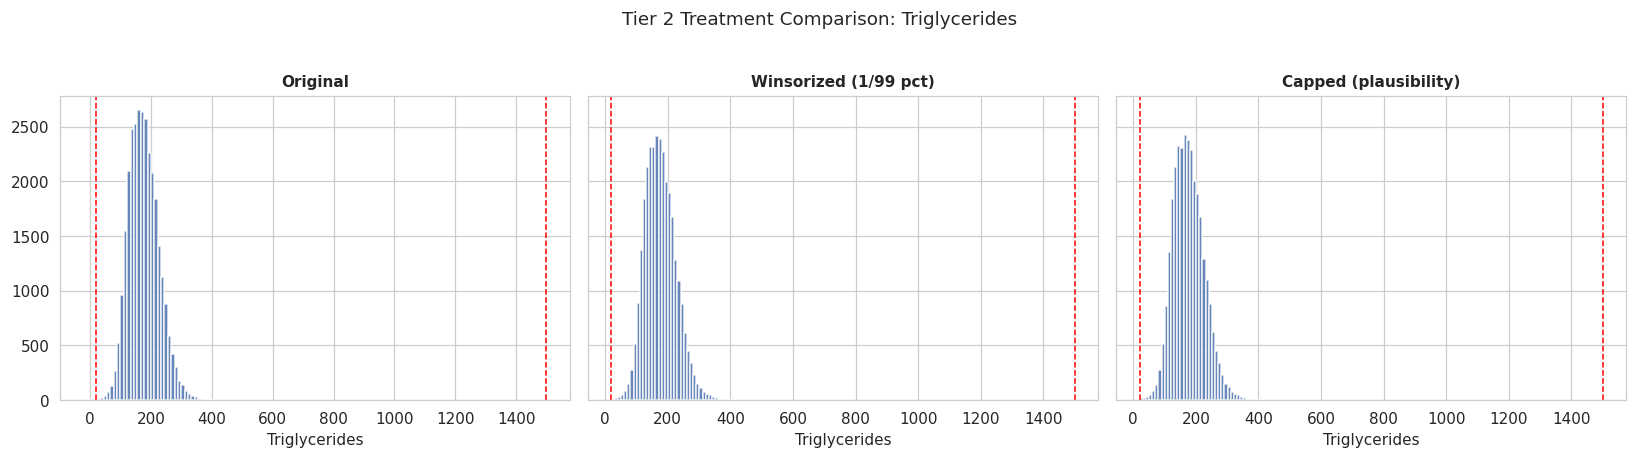

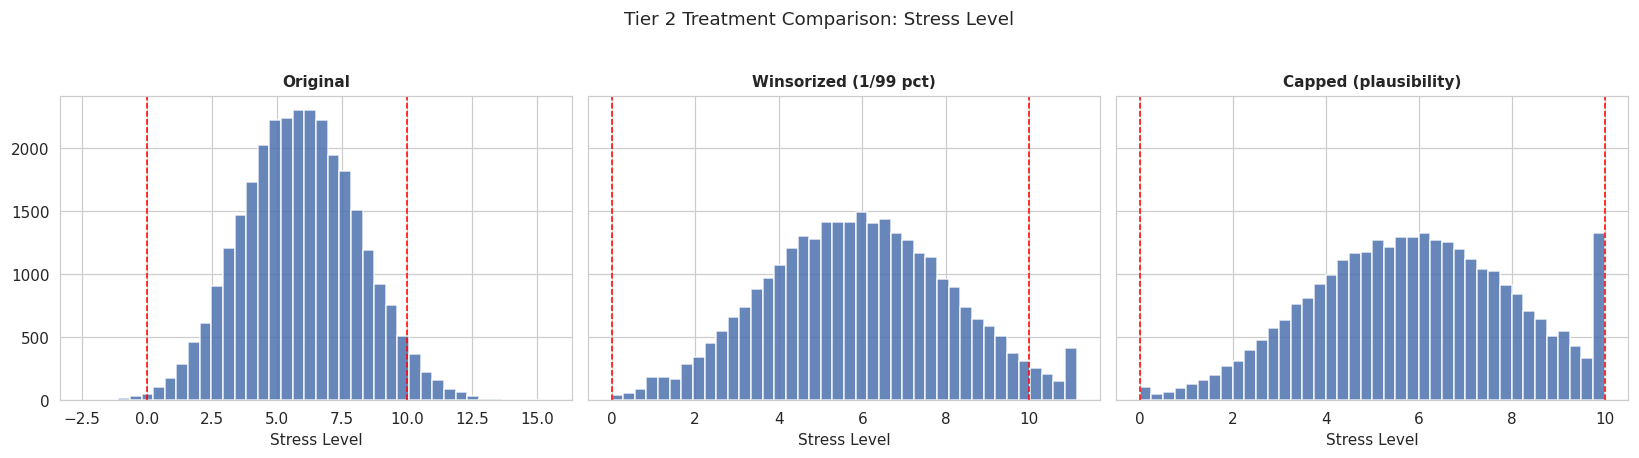

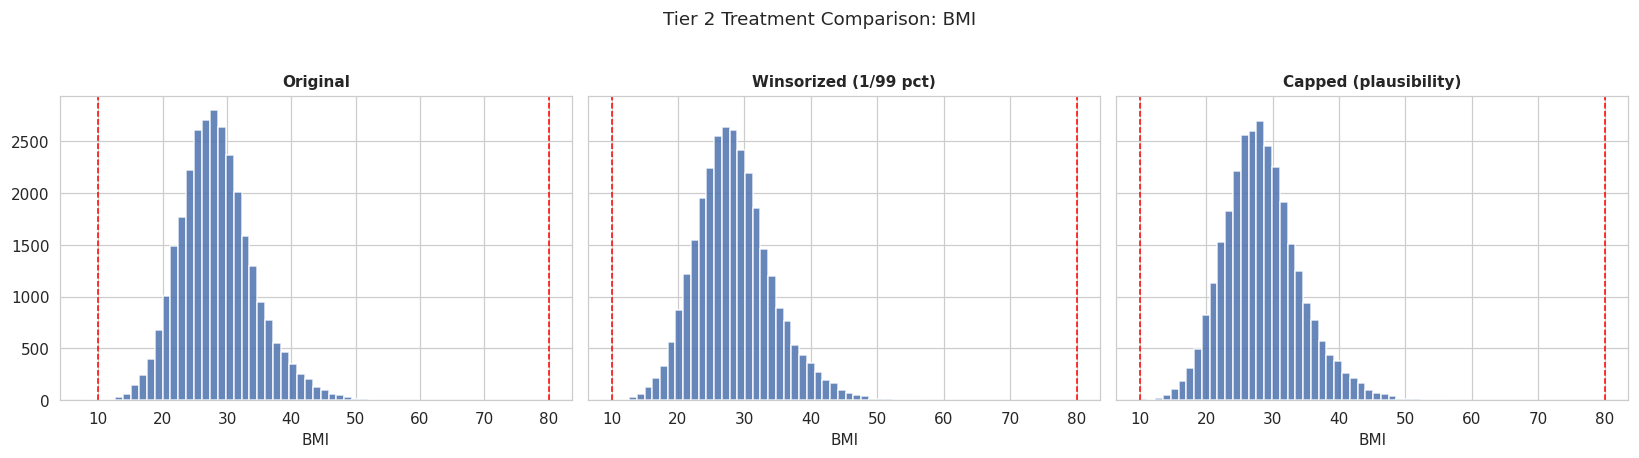

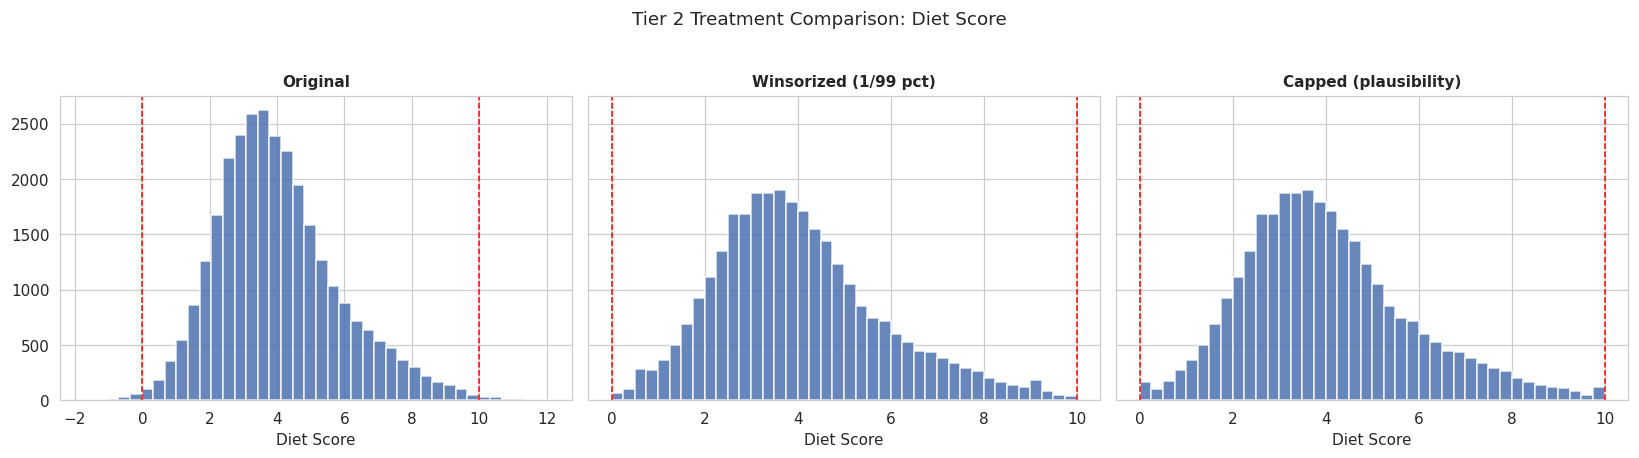


6.4  PER-FLAG REVIEW REPORT
               n_flagged  min_value  max_value  median_flag  max_priority                recommendation
column                                                                                                 
BMI                    4       7.67       9.88         9.34          7.13    keep (morbid obesity real)
Diet Score           183      -1.75      12.06        -0.08          3.85                          keep
Stress Level        1100      -2.44      15.45        10.60          8.96                          keep
Triglycerides         15     -22.48      19.36         4.60        166.01  keep (chylomicronemia >1500)

6.5  TIER 2 POLICY = 'keep'
  Rationale: Tier 2 values may be real pathology.
  Default 'keep' preserves signal and defers to clinician review.
  Change only with documented clinical rationale.
  → Values retained as-is; flags preserved.

6.6  EXPORTS
  → block6_review_queue.csv    (1302 items)
  → block6_review_report.json

  Snapshot saved: b

In [14]:
# ============================================================
# BLOCK 6 — TIER 2 SOFT FLAG HANDLING
# ============================================================
# Purpose:
#   Tier 2 (soft implausible) values from Block 2 were FLAGGED,
#   not nulled. This block:
#     6.1  Triages them into a review queue
#     6.2  Provides statistical context per flagged value
#     6.3  Offers three treatment options (keep/cap/winsorize)
#     6.4  Produces a per-flag review report for the data owner
#
# What this block does NOT do:
#   - It does NOT auto-decide how to treat Tier 2 values.
#   - It does NOT overwrite values without explicit policy.
#   - It does NOT conflate Tier 2 with Tier 1 (which was nulled).
# ============================================================

import pandas as pd
import numpy as np
import json
from datetime import datetime


# ------------------------------------------------------------
# 6.0  Snapshot
# ------------------------------------------------------------
# Why: Triage is read-only on values, but the treatment step
# (6.3) mutates. Snapshot before any treatment is applied.
df_pre_triage = df.copy()
print(f"  Pre-triage snapshot: {df_pre_triage.shape}")


# ------------------------------------------------------------
# 6.1  BUILD THE REVIEW QUEUE
# ------------------------------------------------------------
# Why a queue and not a table:
#   A review queue is ORDERED BY PRIORITY. In a real hospital
#   there may be 10,000 flagged values. The reviewer should see
#   the most clinically impactful first.
#
# Prioritization logic (three signals):
#   1. ABSOLUTE DEVIATION from the bound — how far outside?
#   2. RELATIVE deviation from the column's IQR — is this an
#      outlier within the data or just at the edge of the window?
#   3. CLINICAL SEVERITY weight — some columns matter more
#      (e.g., glucose extremes are more urgent than sleep)
print("=" * 78)
print("6.1  BUILDING TIER 2 REVIEW QUEUE")
print("=" * 78)

# Weights: how much does an extreme value in this column matter?
CLINICAL_SEVERITY_WEIGHT = {
    'Glucose':           1.5,   # metabolic emergency potential
    'Blood Pressure':    1.5,   # hemodynamic emergency potential
    'Oxygen Saturation': 1.5,   # respiratory emergency potential
    'HbA1c':             1.2,   # chronic marker, still important
    'Cholesterol':       0.9,
    'Triglycerides':     1.0,
    'BMI':               0.8,
    'Physical Activity': 0.5,
    'Sleep Hours':       0.5,
    'LengthOfStay':      0.6,
    'Diet Score':        0.4,
    'Stress Level':      0.4,
    'Age':               1.0,
}

# Relevant columns for cross-reference context
CONTEXT_COLUMNS = [c for c in
                   ['Age', 'Gender', 'Medical Condition']
                   if c in df.columns]


def build_review_queue(df, bounds, context_cols):
    """
    Produce a long-format DataFrame with one row per (row, column)
    Tier-2 violation, enriched with statistical context.
    """
    queue_rows = []

    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue

        flag_col = f'flag_soft_{col.lower().replace(" ", "_")}_implausible'
        if flag_col not in df.columns:
            continue

        s = pd.to_numeric(df[col], errors='coerce')
        mask = df[flag_col]

        if not mask.any():
            continue

        # Column-level statistics for context
        col_median = s.median()
        col_iqr = s.quantile(0.75) - s.quantile(0.25)
        col_p01 = s.quantile(0.01)
        col_p99 = s.quantile(0.99)

        for idx in df.index[mask]:
            value = s.loc[idx]
            if pd.isna(value):
                continue

            # Distance from bound (absolute)
            if value < lo:
                dist = lo - value
                side = 'below'
            else:
                dist = value - hi
                side = 'above'

            # Relative deviation from IQR (a robust z-score)
            if col_iqr > 0:
                z_robust = (value - col_median) / col_iqr
            else:
                z_robust = np.nan

            # Priority score = distance × severity × (|z|+1)
            weight = CLINICAL_SEVERITY_WEIGHT.get(col, 1.0)
            z_abs = abs(z_robust) if not np.isnan(z_robust) else 1.0
            priority = dist * weight * (z_abs + 1)

            context = {c: df.at[idx, c] for c in context_cols}

            queue_rows.append({
                'row_index': int(idx),
                'column': col,
                'value': float(value),
                'bound_low': lo,
                'bound_high': hi,
                'side': side,
                'distance_from_bound': round(dist, 2),
                'col_median': round(col_median, 2),
                'col_iqr': round(col_iqr, 2),
                'robust_z': round(z_robust, 2) if not np.isnan(z_robust) else None,
                'priority_score': round(priority, 2),
                **{f'ctx_{k}': v for k, v in context.items()}
            })

    if not queue_rows:
        return pd.DataFrame()

    queue = pd.DataFrame(queue_rows).sort_values(
        'priority_score', ascending=False
    ).reset_index(drop=True)

    return queue


review_queue = build_review_queue(df, CLINICAL_BOUNDS, CONTEXT_COLUMNS)

if review_queue.empty:
    print("  ✅ No Tier 2 violations — nothing to review.")
else:
    print(f"  Total Tier 2 values in review queue: {len(review_queue)}")
    print(f"\n  By column:")
    for col, n in review_queue.groupby('column').size().items():
        print(f"    {col:22s}: {n}")


# ------------------------------------------------------------
# 6.2  SAMPLE THE QUEUE — "show me the top 10"
# ------------------------------------------------------------
# Why: The data owner needs to see a few examples to calibrate
# their expectations. Showing the whole queue is useless; showing
# the top N by priority is what starts the conversation.
print("\n" + "=" * 78)
print("6.2  TOP 15 HIGHEST-PRIORITY REVIEW ITEMS")
print("=" * 78)

if not review_queue.empty:
    cols_to_show = ['row_index', 'column', 'value', 'bound_low',
                    'bound_high', 'side', 'robust_z', 'priority_score']
    # Add context columns if they exist
    ctx_cols = [c for c in review_queue.columns if c.startswith('ctx_')]
    cols_to_show.extend(ctx_cols)

    top_queue = review_queue.head(15)[cols_to_show]
    print(top_queue.to_string(index=False))


# ------------------------------------------------------------
# 6.3  TREATMENT OPTIONS — three principled choices
# ------------------------------------------------------------
# Why not one default:
#   In healthcare ML, the correct treatment depends on the model:
#     • Tree-based (XGBoost, RF)  → keep outliers, they don't hurt
#     • Linear / logistic         → winsorize to protect coefficients
#     • Clinical decision support → cap at physiologic limit and flag
#     • Regulatory reporting      → keep raw + flag
#
# We implement THREE options and default to the safest (KEEP).
print("\n" + "=" * 78)
print("6.3  TREATMENT OPTIONS")
print("=" * 78)


def apply_tier2_treatment(df, bounds, strategy='keep'):
    """
    Apply a treatment strategy to Tier-2 flagged values.

    Strategies:
      'keep'       — leave the value untouched, flag remains (DEFAULT)
      'winsorize'  — replace with the column's 1st/99th percentile
      'cap'        — replace with the plausibility bound itself

    Returns: (df_treated, treatment_log)
    """
    df = df.copy()
    log = []

    for col, (lo, hi) in bounds.items():
        if col not in df.columns:
            continue

        flag_col = f'flag_soft_{col.lower().replace(" ", "_")}_implausible'
        if flag_col not in df.columns:
            continue

        mask = df[flag_col]
        if not mask.any():
            continue

        s = pd.to_numeric(df[col], errors='coerce')

        if strategy == 'winsorize':
            # Replace with 1st/99th percentile
            p01 = s.quantile(0.01)
            p99 = s.quantile(0.99)
            new_vals = s.clip(lower=p01, upper=p99)
        elif strategy == 'cap':
            # Replace with the plausibility bounds
            new_vals = s.clip(lower=lo, upper=hi)
        else:  # keep
            new_vals = s

        # Log the changes
        for idx in df.index[mask]:
            old = s.loc[idx]
            new = new_vals.loc[idx]
            if pd.notna(old) and pd.notna(new) and old != new:
                log.append({
                    'row_index': int(idx),
                    'column': col,
                    'original_value': float(old),
                    'new_value': float(new),
                    'strategy': strategy
                })

        # Apply only if we actually changed values
        if strategy != 'keep':
            df.loc[mask, col] = new_vals.loc[mask]
            # Add a `treated_<col>` flag for auditability
            df[f'treated_{col.lower().replace(" ", "_")}'] = mask

    return df, log


# ------------------------------------------------------------
# 6.3.1  Generate all three scenarios for comparison
# ------------------------------------------------------------
# Why: The data owner can compare three versions side by side
# and pick the one that matches their downstream use case.
#
# NOTE: We do NOT overwrite `df` yet — we produce previews.
df_keep,       _ = apply_tier2_treatment(df, CLINICAL_BOUNDS, 'keep')
df_winsorized, winsorize_log = apply_tier2_treatment(df, CLINICAL_BOUNDS, 'winsorize')
df_capped,     cap_log       = apply_tier2_treatment(df, CLINICAL_BOUNDS, 'cap')

print(f"  keep       — {len(review_queue)} flagged values retained as-is")
print(f"  winsorize  — {len(winsorize_log)} values changed (to 1st/99th pct)")
print(f"  cap        — {len(cap_log)} values changed (to plausibility bound)")


# ------------------------------------------------------------
# 6.3.2  Visual comparison — before / winsorize / cap
# ------------------------------------------------------------
# Why: Numbers alone don't convince. A three-panel density plot
# shows exactly how each strategy affects the distribution.
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

def plot_treatment_comparison(df_before, df_win, df_cap, col):
    if col not in df_before.columns:
        return
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, (label, d) in zip(axes, [
        ('Original', df_before),
        ('Winsorized (1/99 pct)', df_win),
        ('Capped (plausibility)', df_cap),
    ]):
        s = pd.to_numeric(d[col], errors='coerce').dropna()
        ax.hist(s, bins=40, color='#4c72b0', edgecolor='white', alpha=0.85)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel(col)
        ax.axvline(CLINICAL_BOUNDS[col][0], color='red',
                   linestyle='--', linewidth=1)
        ax.axvline(CLINICAL_BOUNDS[col][1], color='red',
                   linestyle='--', linewidth=1)

    fig.suptitle(f"Tier 2 Treatment Comparison: {col}",
                 fontsize=12, y=1.03)
    fig.tight_layout()
    fig.savefig(f"block6_treatment_{col.lower().replace(' ', '_')}.png",
                dpi=120, bbox_inches='tight')
    plt.show()


# Only plot columns that actually had Tier-2 violations
if not review_queue.empty:
    for col in review_queue['column'].unique():
        plot_treatment_comparison(df, df_winsorized, df_capped, col)


# ------------------------------------------------------------
# 6.4  PER-FLAG REVIEW REPORT
# ------------------------------------------------------------
# Why: This is the artifact the data owner actually signs off on.
# It summarizes:
#   - how many flags per column
#   - the range of flagged values
#   - a recommended default treatment
print("\n" + "=" * 78)
print("6.4  PER-FLAG REVIEW REPORT")
print("=" * 78)

if not review_queue.empty:
    summary = review_queue.groupby('column').agg(
        n_flagged=('value', 'count'),
        min_value=('value', 'min'),
        max_value=('value', 'max'),
        median_flag=('value', 'median'),
        max_priority=('priority_score', 'max')
    ).round(2)

    # Recommended default treatment per column
    # (Analyst's suggestion, data owner confirms)
    recommendations = {
        'Glucose':           'keep (real DKA cases exist >600)',
        'Blood Pressure':    'keep (hypertensive crisis real)',
        'Oxygen Saturation': 'cap at 100 (impossible above)',
        'HbA1c':             'keep (real cases up to 61.5%)',
        'Cholesterol':       'keep (familial hypercholesterolemia)',
        'Triglycerides':     'keep (chylomicronemia >1500)',
        'BMI':               'keep (morbid obesity real)',
        'Physical Activity': 'keep (elite athletes)',
        'Sleep Hours':       'cap at 24 (impossible above)',
        'LengthOfStay':      'keep (chronic ICU cases)',
        'Diet Score':        'keep',
        'Stress Level':      'keep',
        'Age':               'keep'
    }
    summary['recommendation'] = summary.index.map(
        lambda c: recommendations.get(c, 'review with data owner')
    )

    print(summary.to_string())


# ------------------------------------------------------------
# 6.5  DECISION: keep / winsorize / cap
# ------------------------------------------------------------
# Why this is a POLICY decision, not a technical one:
#   There is no universal "correct" answer. The right choice
#   depends on downstream use. We default to KEEP (safest).
#
# Set POLICY explicitly so it's auditable.
TIER2_POLICY = 'keep'   # ← change to 'winsorize' or 'cap' per project

print("\n" + "=" * 78)
print(f"6.5  TIER 2 POLICY = '{TIER2_POLICY}'")
print("=" * 78)
print(f"  Rationale: Tier 2 values may be real pathology.")
print(f"  Default 'keep' preserves signal and defers to clinician review.")
print(f"  Change only with documented clinical rationale.")

# Apply the chosen policy to df
if TIER2_POLICY == 'winsorize':
    df, treatment_log = apply_tier2_treatment(df, CLINICAL_BOUNDS, 'winsorize')
elif TIER2_POLICY == 'cap':
    df, treatment_log = apply_tier2_treatment(df, CLINICAL_BOUNDS, 'cap')
else:
    df, treatment_log = df, []
    print("  → Values retained as-is; flags preserved.")


# ------------------------------------------------------------
# 6.6  Export review queue + summary
# ------------------------------------------------------------
# Why: The review queue is the artifact that circulates between
# analyst, data owner, and clinical reviewer.
if not review_queue.empty:
    review_queue.to_csv('block6_review_queue.csv', index=False)
    print("\n" + "=" * 78)
    print("6.6  EXPORTS")
    print("=" * 78)
    print(f"  → block6_review_queue.csv    ({len(review_queue)} items)")
    print(f"  → block6_review_report.json")

    with open('block6_review_report.json', 'w') as f:
        json.dump({
            'block': 6,
            'executed_at': datetime.now().isoformat(),
            'tier2_policy': TIER2_POLICY,
            'total_flagged': len(review_queue),
            'by_column': review_queue.groupby('column').size().to_dict(),
            'recommendations': recommendations,
            'note': (
                "Tier 2 (soft implausible) values are NOT nulled. "
                "They are flagged, prioritized, and presented to the "
                "data owner for review. Default policy is 'keep'."
            )
        }, f, indent=2)


# ------------------------------------------------------------
# 6.7  Snapshot for Block 7
# ------------------------------------------------------------
df.to_parquet('block6_triaged.parquet', index=False)
print("\n  Snapshot saved: block6_triaged.parquet")

  Pre-missingness snapshot: (30000, 82)
7.1  MISSINGNESS BY COLUMN
                       n_missing  pct_missing  severity
Age                         4500        15.00  moderate
Gender                      4500        15.00  moderate
Medical Condition           4500        15.00  moderate
Glucose                     4500        15.00  moderate
Blood Pressure              4500        15.00  moderate
Medical Condition_raw       4500        15.00  moderate
Gender_raw                  4500        15.00  moderate
Oxygen Saturation           1793         5.98  moderate
Physical Activity            302         1.01       low

7.2  MCAR TEST — Is missingness related to other variables?
  Significant associations found (missingness is NOT random):
        column_tested            related_to       test  p_value  significant_at_0.05
                  Age        Blood Pressure     t-test   0.0432                 True
               Gender     Medical Condition chi-square   0.0467                 

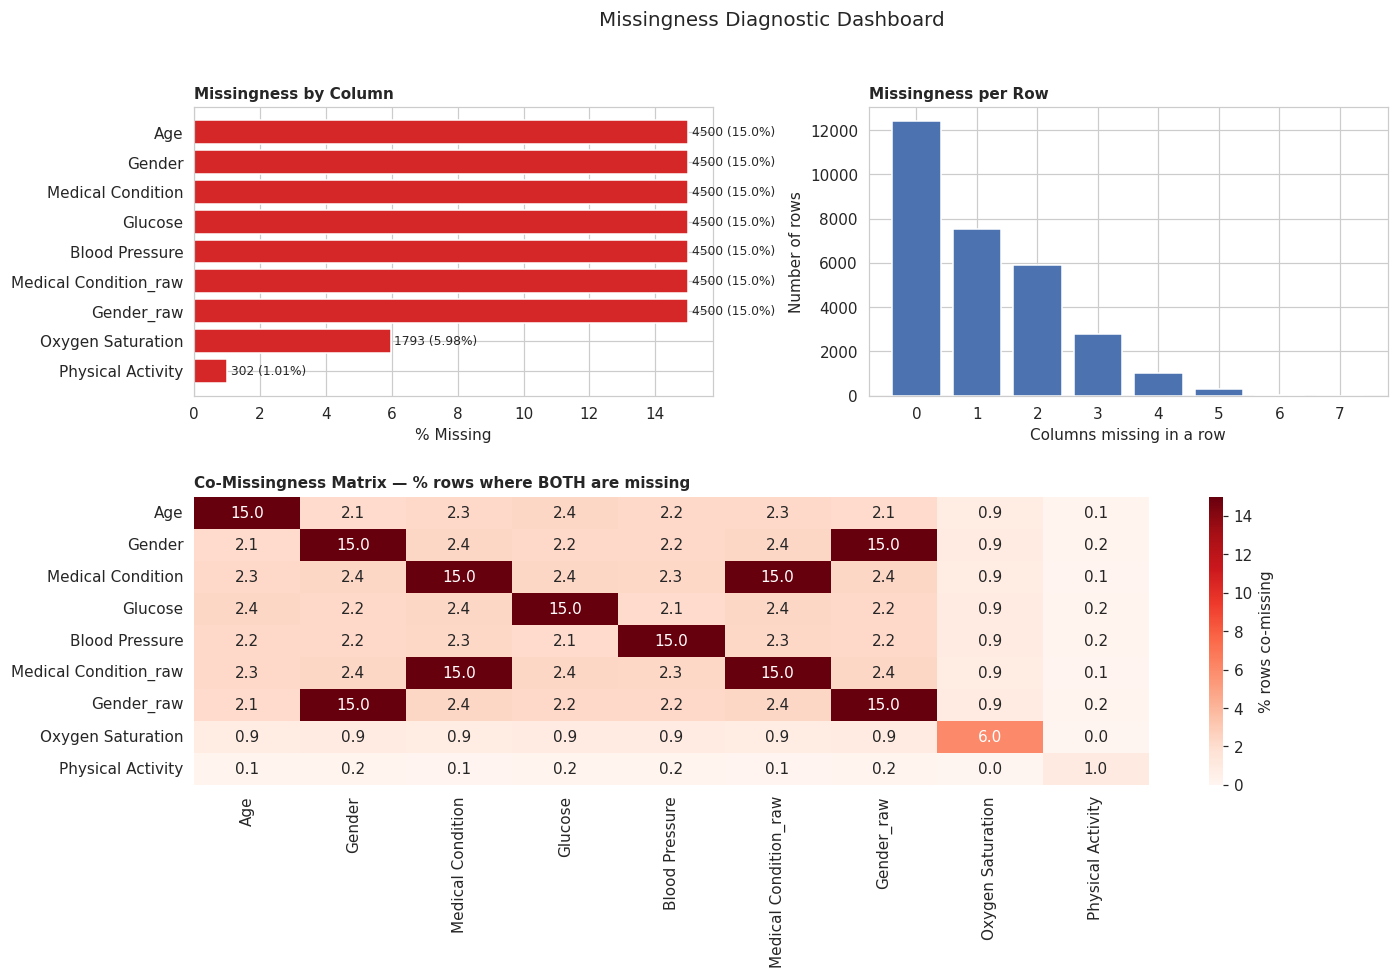


7.6  MISSINGNESS CONTRACT
               column  pct_missing severity mechanism                   strategy
                  Age        15.00 moderate       MAR              impute_median
               Gender        15.00 moderate       MAR                impute_mode
    Medical Condition        15.00 moderate       MAR           leave_as_unknown
              Glucose        15.00 moderate       MAR impute_median_by_condition
       Blood Pressure        15.00 moderate      MCAR impute_median_by_condition
Medical Condition_raw        15.00 moderate       MAR     review_with_data_owner
           Gender_raw        15.00 moderate       MAR     review_with_data_owner
    Oxygen Saturation         5.98 moderate       MAR              impute_median
    Physical Activity         1.01      low       MAR              impute_median

7.7  EXPORTS
  → block7_missingness_dashboard.png
  → block7_missingness_contract.json

  Snapshot saved: block7_missingness_analyzed.parquet


In [15]:
# ============================================================
# BLOCK 7 — MISSINGNESS ANALYSIS & CONTRACT
# ============================================================
# Purpose:
#   Understand WHY values are missing, classify each column's
#   missingness mechanism, and produce a per-column imputation
#   strategy contract that Block 9 will execute.
#
# What this block does:
#   7.1  Quantify missingness per column
#   7.2  Test for MCAR vs. MAR (statistical signal)
#   7.3  Detect MNAR patterns (informative missingness)
#   7.4  Flag per-row missingness
#   7.5  Produce the missingness contract
#
# What this block does NOT do:
#   It does NOT impute. It does NOT drop rows. It does NOT
#   modify values. All imputation happens in Block 9.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from scipy import stats

sns.set_style("whitegrid")


# ------------------------------------------------------------
# 7.0  Snapshot
# ------------------------------------------------------------
df_pre_missingness = df.copy()
print(f"  Pre-missingness snapshot: {df_pre_missingness.shape}")


# ------------------------------------------------------------
# 7.1  QUANTIFY MISSINGNESS — the baseline table
# ------------------------------------------------------------
# Why: You cannot design a strategy without knowing the SCALE.
# A column with 0.1% missing is different from 60% missing.
# The thresholds below are industry conventions, not laws:
#   <1%   → impute is safe, bias negligible
#   1-5%  → impute, but keep the was_missing flag
#   5-20% → impute with caution; consider model-based imputation
#   >20%  → consider dropping or domain-specific handling
#   >50%  → usually drop unless clinically essential
print("=" * 78)
print("7.1  MISSINGNESS BY COLUMN")
print("=" * 78)

missing_summary = df.isna().sum()
missing_pct = (missing_summary / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'n_missing': missing_summary,
    'pct_missing': missing_pct
})

# Only show columns with any missingness
missing_df = missing_df[missing_df['n_missing'] > 0].sort_values(
    'pct_missing', ascending=False
)

if missing_df.empty:
    print("  ✅ No missing values in the dataset.")
else:
    # Add a severity tier per column
    def severity(pct):
        if pct < 1:    return 'negligible'
        if pct < 5:    return 'low'
        if pct < 20:   return 'moderate'
        if pct < 50:   return 'high'
        return 'very_high'

    missing_df['severity'] = missing_df['pct_missing'].apply(severity)
    print(missing_df.to_string())


# ------------------------------------------------------------
# 7.2  TEST FOR MCAR — "Is missingness random?"
# ------------------------------------------------------------
# Why: This is the core question. MCAR (Missing Completely At Random)
# means the missingness is unrelated to ANY variable. If true, simple
# mean/median imputation is unbiased. If false, we need smarter methods.
#
# Test: Little's MCAR test is the gold standard but not in scipy.
# Alternative: For each column with missingness, compare the
# distribution of OTHER columns between the "missing" vs. "present"
# groups using a t-test (numeric) or chi-square (categorical).
# A significant difference suggests MAR or MNAR — i.e., missingness
# is NOT random.
print("\n" + "=" * 78)
print("7.2  MCAR TEST — Is missingness related to other variables?")
print("=" * 78)


def test_mcar_for_column(df, target_col, max_p_value_report=10):
    """
    Test whether the missingness in `target_col` is associated with
    other columns. Returns a report of significant associations.
    """
    if df[target_col].isna().sum() == 0:
        return None

    is_missing = df[target_col].isna()

    results = []

    for other_col in df.columns:
        if other_col == target_col:
            continue

        # Skip flag columns — they're derived, not clinical
        if other_col.startswith(('flag_', 'is_', 'nulled_', 'was_')):
            continue

        s = df[other_col]
        try:
            if pd.api.types.is_numeric_dtype(s):
                # t-test: is the mean of `other_col` different
                # between missing-group and present-group?
                g_miss = s[is_missing].dropna()
                g_pres = s[~is_missing].dropna()
                if len(g_miss) < 3 or len(g_pres) < 3:
                    continue
                t, p = stats.ttest_ind(g_miss, g_pres, equal_var=False)
                test_used = 't-test'
            else:
                # chi-square: is the distribution of categories
                # different between missing-group and present-group?
                ct = pd.crosstab(is_missing, s)
                if ct.shape[0] < 2 or ct.shape[1] < 2:
                    continue
                chi2, p, _, _ = stats.chi2_contingency(ct)
                test_used = 'chi-square'

            results.append({
                'column_tested': target_col,
                'related_to': other_col,
                'test': test_used,
                'p_value': round(p, 4),
                'significant_at_0.05': p < 0.05
            })
        except Exception:
            continue

    return pd.DataFrame(results)


mcar_reports = []
for col in missing_df.index:
    rep = test_mcar_for_column(df, col)
    if rep is not None:
        # Only keep significant associations
        sig = rep[rep['significant_at_0.05']]
        if not sig.empty:
            mcar_reports.append(sig)

if mcar_reports:
    mcar_all = pd.concat(mcar_reports, ignore_index=True)
    print("  Significant associations found (missingness is NOT random):")
    print(mcar_all.head(20).to_string(index=False))
    print(f"\n  → Total significant associations: {len(mcar_all)}")
    print("  → Interpretation: For these columns, missingness is")
    print("    MAR (related to other variables) rather than MCAR.")
else:
    print("  ✅ No significant associations found.")
    print("  → Suggests MCAR: missingness appears random.")


# ------------------------------------------------------------
# 7.3  DETECT MNAR — "Does the VALUE correlate with its own missingness?"
# ------------------------------------------------------------
# Why: MNAR (Missing Not At Random) is the hardest case. It means
# the probability of being missing depends on the value itself.
# Classic example: severely depressed patients are LESS likely to
# report their depression score (they don't fill out surveys).
#
# Detection strategy:
#   - If a column has OTHER correlated columns (e.g., Glucose and HbA1c),
#     check whether the correlated values differ between the missing
#     and present groups of the target column.
#   - This is heuristic, not definitive, but it flags candidates.
print("\n" + "=" * 78)
print("7.3  MNAR CANDIDATE DETECTION — informative missingness")
print("=" * 78)

# Known clinically-correlated pairs (domain knowledge)
CLINICAL_CORRELATES = {
    'Glucose':     ['HbA1c', 'BMI'],
    'HbA1c':       ['Glucose'],
    'BMI':         ['Glucose', 'Cholesterol'],
    'Blood Pressure': ['Cholesterol', 'BMI'],
    'Cholesterol': ['Triglycerides', 'BMI'],
    'Triglycerides': ['Cholesterol'],
    'Sleep Hours':  ['Stress Level', 'Physical Activity'],
}

mnar_candidates = []
for target_col, correlates in CLINICAL_CORRELATES.items():
    if target_col not in df.columns or df[target_col].isna().sum() == 0:
        continue
    is_missing = df[target_col].isna()

    for corr_col in correlates:
        if corr_col not in df.columns:
            continue
        g_miss = df.loc[is_missing, corr_col].dropna()
        g_pres = df.loc[~is_missing, corr_col].dropna()
        if len(g_miss) < 3 or len(g_pres) < 3:
            continue
        t, p = stats.ttest_ind(g_miss, g_pres, equal_var=False)
        if p < 0.05:
            mnar_candidates.append({
                'target_missing': target_col,
                'correlate': corr_col,
                'mean_when_missing': round(g_miss.mean(), 2),
                'mean_when_present': round(g_pres.mean(), 2),
                'p_value': round(p, 4)
            })

if mnar_candidates:
    mnar_df = pd.DataFrame(mnar_candidates)
    print("  ⚠️  MNAR candidates (informative missingness):")
    print(mnar_df.to_string(index=False))
    print("\n  → Interpretation: These columns may be missing BECAUSE")
    print("    of patient characteristics. Simple imputation may bias.")
    print("    Consider model-based imputation (MICE) or a missingness flag.")
else:
    print("  ✅ No MNAR candidates detected.")


# ------------------------------------------------------------
# 7.4  ROW-LEVEL MISSINGNESS FLAGS
# ------------------------------------------------------------
# Why: Even after imputation, the *fact* that a value was missing
# is itself informative. Models can learn from this. We create
# `was_missing_<col>` for every column that had any missingness.
# These flags SURVIVE imputation and become model features.
print("\n" + "=" * 78)
print("7.4  CREATING was_missing FLAGS")
print("=" * 78)

WAS_MISSING_FLAGS = []
for col in missing_df.index:
    flag_col = f'was_missing_{col.lower().replace(" ", "_")}'
    df[flag_col] = df[col].isna()
    WAS_MISSING_FLAGS.append(flag_col)

print(f"  Created {len(WAS_MISSING_FLAGS)} was_missing flags:")
for f in WAS_MISSING_FLAGS:
    print(f"    • {f}")


# ------------------------------------------------------------
# 7.5  MISSINGNESS HEATMAP — visual evidence for the owner
# ------------------------------------------------------------
# Why: The data owner needs to SEE the pattern. Our earlier
# attempt (raw heatmap of every row) failed. This is the
# improved aggregated version:
#   - Column-level missingness (top bar)
#   - Row-level missingness distribution (bottom histogram)
#   - Co-missingness matrix (right heatmap)
print("\n" + "=" * 78)
print("7.5  MISSINGNESS VISUALIZATION")
print("=" * 78)

if not missing_df.empty:
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.3)

    # --- (top-left) Column missingness bar ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.barh(missing_df.index[::-1], missing_df['pct_missing'][::-1],
             color='#d62728')
    for i, (col, row) in enumerate(missing_df[::-1].iterrows()):
        ax1.text(row['pct_missing'] + 0.1, i,
                 f"{row['n_missing']} ({row['pct_missing']}%)",
                 va='center', fontsize=8)
    ax1.set_xlabel('% Missing')
    ax1.set_title('Missingness by Column', loc='left', fontsize=10)

    # --- (top-right) Row missingness histogram ---
    ax2 = fig.add_subplot(gs[0, 1])
    row_missing = df[missing_df.index].isna().sum(axis=1)
    vc = row_missing.value_counts().sort_index()
    ax2.bar(vc.index, vc.values, color='#4c72b0', edgecolor='white')
    ax2.set_xlabel('Columns missing in a row')
    ax2.set_ylabel('Number of rows')
    ax2.set_title('Missingness per Row', loc='left', fontsize=10)

    # --- (bottom) Co-missingness matrix ---
    ax3 = fig.add_subplot(gs[1, :])
    cols_with_miss = missing_df.index.tolist()
    n = len(cols_with_miss)
    co = np.zeros((n, n))
    for i, ci in enumerate(cols_with_miss):
        for j, cj in enumerate(cols_with_miss):
            co[i, j] = (df[ci].isna() & df[cj].isna()).mean() * 100

    sns.heatmap(
        pd.DataFrame(co, index=cols_with_miss, columns=cols_with_miss),
        annot=True, fmt=".1f", cmap='Reds', ax=ax3,
        cbar_kws={'label': '% rows co-missing'}, vmin=0
    )
    ax3.set_title('Co-Missingness Matrix — % rows where BOTH are missing',
                  loc='left', fontsize=10)

    fig.suptitle('Missingness Diagnostic Dashboard', fontsize=13, y=0.99)
    fig.savefig('block7_missingness_dashboard.png',
                dpi=120, bbox_inches='tight')
    plt.show()


# ------------------------------------------------------------
# 7.6  THE MISSINGNESS CONTRACT
# ------------------------------------------------------------
# Why: The contract is the DECISION DOCUMENT. For each column
# it records:
#   - Missingness %  (measured)
#   - Mechanism      (MCAR / MAR / MNAR / unknown)
#   - Strategy       (drop / impute-median / impute-mode / model / flag-only)
#   - Rationale      (why this strategy — auditable)
#
# Block 9 will EXECUTE this contract. It will NOT improvise.
print("\n" + "=" * 78)
print("7.6  MISSINGNESS CONTRACT")
print("=" * 78)

# Build per-column classifications
def classify_mechanism(col, mcar_df, mnar_df):
    """Assign MCAR/MAR/MNAR based on the tests above."""
    if mcar_df is not None and not mcar_df.empty:
        if (mcar_df['column_tested'] == col).any():
            return 'MAR'
    if mnar_df is not None and not mnar_df.empty:
        if (mnar_df['target_missing'] == col).any():
            return 'MNAR'
    return 'MCAR'   # default when no associations found


# Strategy assignments — clinical reasoning per column
STRATEGY_MAP = {
    'Glucose':           'impute_median_by_condition',  # use condition median
    'Blood Pressure':    'impute_median_by_condition',
    'BMI':               'impute_median',
    'Oxygen Saturation': 'impute_median',
    'Cholesterol':       'impute_median',
    'Triglycerides':     'impute_median',
    'HbA1c':             'impute_median_by_condition',
    'Age':               'impute_median',  # or leave for a model
    'Gender':            'impute_mode',
    'Medical Condition': 'leave_as_unknown',  # condition is a target; don't guess
    'Smoking':           'impute_mode',
    'Alcohol':           'impute_mode',
    'Family History':    'impute_mode',
    'Physical Activity': 'impute_median',
    'Sleep Hours':       'impute_median',
    'LengthOfStay':      'leave_as_nan',   # temporal field — value is often specific
    'Diet Score':        'impute_median',
    'Stress Level':      'impute_median',
}

contract_rows = []
for col in missing_df.index:
    pct = missing_df.loc[col, 'pct_missing']
    severity = missing_df.loc[col, 'severity']
    mechanism = classify_mechanism(col,
                                   pd.concat(mcar_reports, ignore_index=True) if mcar_reports else None,
                                   pd.DataFrame(mnar_candidates) if mnar_candidates else None)
    strategy = STRATEGY_MAP.get(col, 'review_with_data_owner')

    contract_rows.append({
        'column': col,
        'pct_missing': pct,
        'severity': severity,
        'mechanism': mechanism,
        'strategy': strategy,
        'rationale': {
            'impute_median':                'Distribution likely skewed; median is robust',
            'impute_median_by_condition':   'Median differs by Medical Condition; groupby impute',
            'impute_mode':                  'Categorical; mode is standard',
            'leave_as_unknown':             'Field is a prediction target; imputing = target leakage',
            'leave_as_nan':                 'Value is highly context-specific; NaN is informative',
            'review_with_data_owner':       'Insufficient basis for automated decision',
        }.get(strategy, 'Pending review')
    })

contract_df = pd.DataFrame(contract_rows)
if not contract_df.empty:
    print(contract_df[['column', 'pct_missing', 'severity',
                       'mechanism', 'strategy']].to_string(index=False))


# ------------------------------------------------------------
# 7.7  EXPORT MISSINGNESS CONTRACT
# ------------------------------------------------------------
with open('block7_missingness_contract.json', 'w') as f:
    json.dump({
        'block': 7,
        'executed_at': datetime.now().isoformat(),
        'columns_with_missing': missing_df.index.tolist(),
        'was_missing_flags_created': WAS_MISSING_FLAGS,
        'contract': contract_rows,
        'note': (
            "This contract will be EXECUTED in Block 9. It is the "
            "decision document — not the imputation step itself. "
            "Every column's strategy is explicit and auditable."
        )
    }, f, indent=2)

print("\n" + "=" * 78)
print("7.7  EXPORTS")
print("=" * 78)
print("  → block7_missingness_dashboard.png")
print("  → block7_missingness_contract.json")


# ------------------------------------------------------------
# 7.8  Snapshot for Block 8
# ------------------------------------------------------------
df.to_parquet('block7_missingness_analyzed.parquet', index=False)
print("\n  Snapshot saved: block7_missingness_analyzed.parquet")

  Pre-outlier snapshot: (30000, 91)
8.1  OUTLIER DETECTION SCOPE
  Columns checked     : 13
  Columns excluded    : 5
  Excluded list       : ['Gender', 'Medical Condition', 'Smoking', 'Alcohol', 'Family History']

8.2  IQR METHOD (k=3.0 — conservative)
LengthOfStay_iqr_outlier         930
Glucose_iqr_outlier              180
Oxygen Saturation_iqr_outlier    137
HbA1c_iqr_outlier                  5
BMI_iqr_outlier                    2
Diet Score_iqr_outlier             1
Triglycerides_iqr_outlier          1

8.3  MODIFIED Z-SCORE (threshold 3.5)
Glucose_mz_outlier              1995
LengthOfStay_mz_outlier         1131
HbA1c_mz_outlier                 530
Oxygen Saturation_mz_outlier     451
Diet Score_mz_outlier            164
BMI_mz_outlier                   129
Triglycerides_mz_outlier          53
Blood Pressure_mz_outlier         35
Physical Activity_mz_outlier      32
Cholesterol_mz_outlier            19
Stress Level_mz_outlier            9
Sleep Hours_mz_outlier             3

8.4

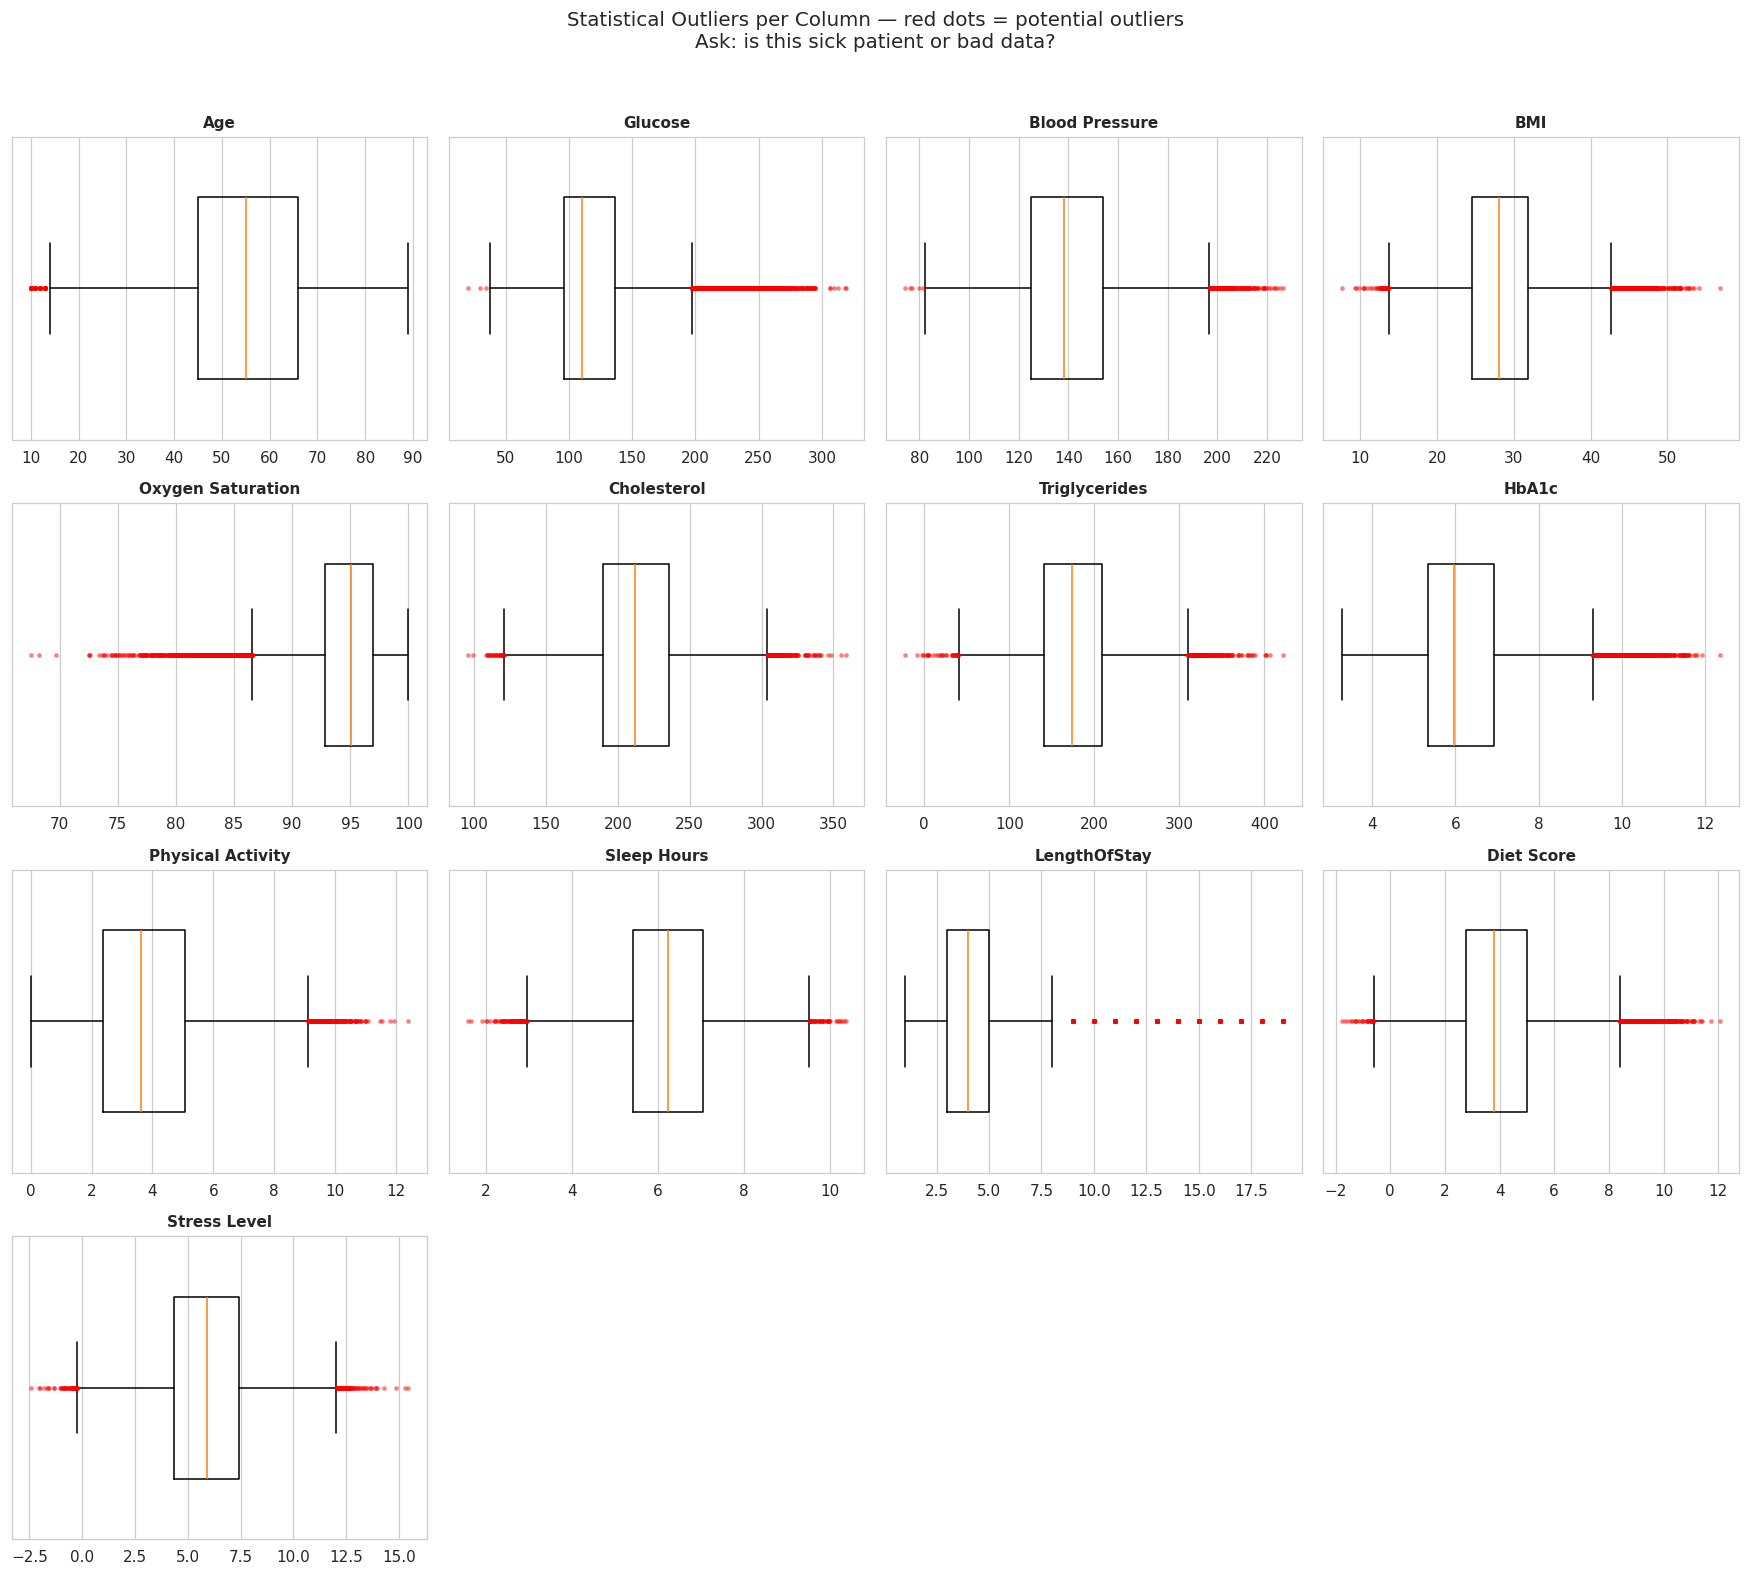


8.9  EXPORTS
  → block8_outlier_boxplots.png
  → block8_outlier_report.json

  Snapshot saved: block8_outliers_flagged.parquet


In [16]:
# ============================================================
# BLOCK 8 — STATISTICAL OUTLIER DETECTION
# ============================================================
# Purpose:
#   Detect statistical outliers — values that are unusual
#   *relative to the data distribution* — as opposed to
#   clinical outliers (which Block 2 handled via plausibility
#   windows).
#
#   Produce per-method flags + a consensus flag. Do NOT remove.
#
# What this block does:
#   8.1  Configure detection per column (some columns skip)
#   8.2  IQR method       (robust, non-parametric)
#   8.3  Modified Z-score (robust to non-normality)
#   8.4  Isolation Forest (multivariate, non-parametric)
#   8.5  Consensus flag   (agree across methods)
#   8.6  Cross-check with clinical severity
#   8.7  Per-column outlier report for data owner
#
# What this block does NOT do:
#   It does NOT delete outliers. It does NOT winsorize.
#   It does NOT touch Tier 1 or Tier 2 logic from Blocks 5-6.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")


# ------------------------------------------------------------
# 8.0  Snapshot & scope declaration
# ------------------------------------------------------------
df_pre_outlier = df.copy()
print(f"  Pre-outlier snapshot: {df_pre_outlier.shape}")


# ------------------------------------------------------------
# 8.1  WHICH COLUMNS TO CHECK FOR OUTLIERS
# ------------------------------------------------------------
# Why a config, not a blanket rule:
#   - Continuous labs / vitals → YES outlier detection
#   - Binary fields (Smoking)  → NO (outliers are impossible)
#   - Categoricals             → NO (different method)
#   - Temporal (LengthOfStay)  → YES, but with domain-specific
#                                context (see note)
#   - Target variable          → NO (outliers are what we predict)
#
# Do NOT treat "LengthOfStay" the same as "Glucose". A 30-day
# LOS is common in oncology; a 30 mg/dL glucose is a coma.
print("=" * 78)
print("8.1  OUTLIER DETECTION SCOPE")
print("=" * 78)

OUTLIER_COLUMNS = [
    'Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
    'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
    'Sleep Hours', 'LengthOfStay', 'Diet Score', 'Stress Level'
]
# Only keep columns that exist
OUTLIER_COLUMNS = [c for c in OUTLIER_COLUMNS if c in df.columns]

# Columns explicitly excluded from outlier treatment
EXCLUDED_FROM_OUTLIER = [
    'Gender', 'Medical Condition',           # categorical
    'Smoking', 'Alcohol', 'Family History',  # binary
]
EXCLUDED_FROM_OUTLIER = [c for c in EXCLUDED_FROM_OUTLIER if c in df.columns]

print(f"  Columns checked     : {len(OUTLIER_COLUMNS)}")
print(f"  Columns excluded    : {len(EXCLUDED_FROM_OUTLIER)}")
print(f"  Excluded list       : {EXCLUDED_FROM_OUTLIER}")


# ------------------------------------------------------------
# 8.2  IQR METHOD — non-parametric, robust
# ------------------------------------------------------------
# Why IQR:
#   - Does not assume normal distribution
#   - Uses percentiles, so it's robust to extreme values
#   - Standard in clinical research (Tukey's original 1977 method)
#
# Rule: value is an outlier if it lies outside
#   [Q1 - k*IQR, Q3 + k*IQR]
# with k = 1.5 (mild outliers) or k = 3.0 (extreme outliers)
#
# We use k = 3.0 — deliberately conservative. In healthcare,
# we prefer to MISS a real outlier than to FLAG a sick patient.
print("\n" + "=" * 78)
print("8.2  IQR METHOD (k=3.0 — conservative)")
print("=" * 78)


def iqr_outlier_flags(df, columns, k=3.0):
    """
    Return a DataFrame of boolean flags, one column per source col.
    Naming: <col>_iqr_outlier
    """
    flags = pd.DataFrame(index=df.index)

    for col in columns:
        s = pd.to_numeric(df[col], errors='coerce')
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        if iqr == 0 or pd.isna(iqr):
            flags[f'{col}_iqr_outlier'] = False
            continue

        lower = q1 - k * iqr
        upper = q3 + k * iqr
        flags[f'{col}_iqr_outlier'] = s.notna() & ((s < lower) | (s > upper))

    return flags


iqr_flags = iqr_outlier_flags(df, OUTLIER_COLUMNS, k=3.0)
iqr_counts = iqr_flags.sum().sort_values(ascending=False)
print(iqr_counts[iqr_counts > 0].to_string() if (iqr_counts > 0).any() else "  ✅ No IQR outliers at k=3.0")


# ------------------------------------------------------------
# 8.3  MODIFIED Z-SCORE — robust to non-normality
# ------------------------------------------------------------
# Why modified Z (not classic Z):
#   Classic Z uses mean and std — both are heavily influenced
#   by the outliers themselves. Modified Z uses median and MAD,
#   which are resistant to contamination.
#
# Formula:
#   M_i = 0.6745 * (x_i - median) / MAD
#   MAD = median(|x_i - median|)
#
# Rule: |M_i| > 3.5 → outlier (Iglewicz & Hoaglin, 1993)
# 0.6745 is the scaling constant to make MAD consistent with
# std under a normal distribution.
print("\n" + "=" * 78)
print("8.3  MODIFIED Z-SCORE (threshold 3.5)")
print("=" * 78)


def modified_z_flags(df, columns, threshold=3.5):
    flags = pd.DataFrame(index=df.index)

    for col in columns:
        s = pd.to_numeric(df[col], errors='coerce')
        median = s.median()
        mad = (s - median).abs().median()

        if mad == 0 or pd.isna(mad):
            flags[f'{col}_mz_outlier'] = False
            continue

        mz = 0.6745 * (s - median) / mad
        flags[f'{col}_mz_outlier'] = s.notna() & (mz.abs() > threshold)

    return flags


mz_flags = modified_z_flags(df, OUTLIER_COLUMNS, threshold=3.5)
mz_counts = mz_flags.sum().sort_values(ascending=False)
print(mz_counts[mz_counts > 0].to_string() if (mz_counts > 0).any() else "  ✅ No modified-Z outliers at 3.5")


# ------------------------------------------------------------
# 8.4  ISOLATION FOREST — multivariate, non-parametric
# ------------------------------------------------------------
# Why IF:
#   - Detects outliers in MULTIVARIATE space (not one column at a time)
#   - Makes no distributional assumptions
#   - Handles interactions: a Glucose=180 is normal, but
#     Glucose=180 + HbA1c=4.5 is anomalous
#
# We fit on the numeric clinical columns (WITHOUT flags) so the
# detector isn't biased by our own prior flag decisions.
#
# Contamination parameter:
#   We set 0.05 (assume ~5% of the data is anomalous). This is
#   NOT a clinical claim — it's a common heuristic. Adjust based
#   on the data owner's expectation.
#
# random_state=42 for reproducibility — critical in healthcare.
print("\n" + "=" * 78)
print("8.4  ISOLATION FOREST (multivariate, contamination=5%)")
print("=" * 78)


def isolation_forest_flags(df, columns, contamination=0.05, random_state=42):
    # Build the feature matrix — only complete rows
    X = df[columns].apply(pd.to_numeric, errors='coerce')

    # IF requires no NaN — we impute with median TEMPORARILY just
    # for the fit. These temporary values are NOT written back
    # to df — they exist only for the outlier detector.
    X_filled = X.fillna(X.median())

    # Only rows with at least half the columns present are scored
    valid_mask = X.notna().sum(axis=1) >= (len(columns) // 2)

    model = IsolationForest(
        contamination=contamination,
        random_state=random_state,
        n_estimators=100
    )
    model.fit(X_filled[valid_mask])

    # -1 = anomaly, 1 = normal
    preds = pd.Series(False, index=df.index)
    preds.loc[valid_mask] = (model.predict(X_filled[valid_mask]) == -1)

    return pd.Series(preds, name='isolation_forest_outlier')


if_flags = isolation_forest_flags(df, OUTLIER_COLUMNS)
print(f"  Isolation Forest flagged: {int(if_flags.sum())} rows "
      f"({if_flags.mean()*100:.2f}%)")


# ------------------------------------------------------------
# 8.5  CONSENSUS FLAG — where methods agree
# ------------------------------------------------------------
# Why consensus:
#   Each method has blind spots. IQR misses multivariate cases.
#   IF misses univariate extreme values if the row is otherwise
#   typical. Where methods AGREE, confidence is highest.
#
# We combine:
#   - univariate IQR (any column)
#   - univariate modified-Z (any column)
#   - multivariate IF (row level)
print("\n" + "=" * 78)
print("8.5  CONSENSUS OUTLIER FLAG")
print("=" * 78)

any_iqr = iqr_flags.any(axis=1)
any_mz  = mz_flags.any(axis=1)

consensus_2of3 = any_iqr.astype(int) + any_mz.astype(int) + if_flags.astype(int)
df['flag_outlier_any_univariate']   = any_iqr | any_mz
df['flag_outlier_multivariate']     = if_flags
df['flag_outlier_consensus_2of3']   = consensus_2of3 >= 2
df['flag_outlier_consensus_3of3']   = consensus_2of3 == 3

print(f"  Flagged by IQR (any col)          : {int(any_iqr.sum())}")
print(f"  Flagged by modified-Z (any col)   : {int(any_mz.sum())}")
print(f"  Flagged by Isolation Forest       : {int(if_flags.sum())}")
print(f"  Flagged by 2 of 3 (consensus)     : {int(df['flag_outlier_consensus_2of3'].sum())}")
print(f"  Flagged by 3 of 3 (strong)        : {int(df['flag_outlier_consensus_3of3'].sum())}")


# ------------------------------------------------------------
# 8.6  CROSS-CHECK WITH CLINICAL SEVERITY
# ------------------------------------------------------------
# Why this is the most important subsection:
#   A statistical outlier that is ALSO a Tier-2 clinical flag
#   is very likely real pathology — it should NOT be removed.
#   A statistical outlier that is NOT clinically flagged might
#   be a data entry error (unlikely value but still within
#   plausible range).
#
# This intersection tells the data owner WHERE to focus review.
print("\n" + "=" * 78)
print("8.6  CROSS-CHECK: statistical × clinical flags")
print("=" * 78)

# Any soft clinical flag from Block 2
soft_flag_cols = [c for c in df.columns if c.startswith('flag_soft_')]
if soft_flag_cols:
    any_soft = df[soft_flag_cols].any(axis=1)
else:
    any_soft = pd.Series(False, index=df.index)

any_statistical = df['flag_outlier_consensus_2of3']

# Cross-tabulation
crosstab = pd.crosstab(
    any_statistical.rename('statistical_outlier'),
    any_soft.rename('clinical_flag'),
    margins=True
)
print(crosstab.to_string())

# The four quadrants and their meaning:
print("\n  Interpretation of quadrants:")
print("    ┌─────────────────────┬─────────────────────────────────────┐")
print("    │ statistical=0       │ statistical=0                       │")
print("    │ clinical=0          │ clinical=1                          │")
print("    │ → Clean             │ → Clinically flagged (Tier 2)       │")
print("    │                     │   Review in Block 6                 │")
print("    ├─────────────────────┼─────────────────────────────────────┤")
print("    │ statistical=1       │ statistical=1                       │")
print("    │ clinical=0          │ clinical=1                          │")
print("    │ → Stat outlier only │ → STRONG review case                │")
print("    │   Possible entry err│   Likely real pathology             │")
print("    │   or unusual biology│   RETRAIN model, don't remove       │")
print("    └─────────────────────┴─────────────────────────────────────┘")


# ------------------------------------------------------------
# 8.7  PER-COLUMN OUTLIER REPORT
# ------------------------------------------------------------
# Why: Data owner needs a table showing, per column:
#   - how many statistical outliers
#   - the min/max of those outliers
#   - how many are also clinically flagged
print("\n" + "=" * 78)
print("8.7  PER-COLUMN OUTLIER REPORT")
print("=" * 78)


def per_column_outlier_report(df, iqr_flags, mz_flags, soft_flag_cols):
    rows = []
    for col in OUTLIER_COLUMNS:
        iqr_col = f'{col}_iqr_outlier'
        mz_col  = f'{col}_mz_outlier'
        if iqr_col not in iqr_flags.columns or mz_col not in mz_flags.columns:
            continue

        combined = iqr_flags[iqr_col] | mz_flags[mz_col]
        n_out = int(combined.sum())
        if n_out == 0:
            continue

        s = pd.to_numeric(df[col], errors='coerce')
        soft_col = f'flag_soft_{col.lower().replace(" ", "_")}_implausible'
        n_clinical_overlap = (
            int((combined & df[soft_col]).sum())
            if soft_col in df.columns else 0
        )

        rows.append({
            'column': col,
            'n_statistical_outliers': n_out,
            'pct_of_rows': round(n_out / len(df) * 100, 2),
            'outlier_min': round(s[combined].min(), 2),
            'outlier_max': round(s[combined].max(), 2),
            'overlap_with_clinical_flags': n_clinical_overlap
        })
    return pd.DataFrame(rows)


outlier_report = per_column_outlier_report(df, iqr_flags, mz_flags, soft_flag_cols)
if not outlier_report.empty:
    print(outlier_report.to_string(index=False))
else:
    print("  ✅ No statistical outliers detected in any column.")


# ------------------------------------------------------------
# 8.8  VISUAL EVIDENCE — boxplots per column
# ------------------------------------------------------------
# Why: A boxplot is the fastest way to convey "the distribution
# and its outliers" to a non-technical reviewer. We use a
# single figure with one subplot per column.
if not outlier_report.empty:
    n_cols = len(OUTLIER_COLUMNS)
    n_rows = int(np.ceil(n_cols / 4))
    fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3.5 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(OUTLIER_COLUMNS):
        s = pd.to_numeric(df[col], errors='coerce').dropna()
        ax = axes[i]
        ax.boxplot(s, vert=False, widths=0.6,
                   flierprops=dict(marker='o', markersize=3,
                                   markerfacecolor='red',
                                   markeredgecolor='none', alpha=0.5))
        ax.set_title(col, fontsize=10)
        ax.set_yticks([])
        ax.set_xlabel("")

    for j in range(len(OUTLIER_COLUMNS), len(axes)):
        axes[j].axis('off')

    fig.suptitle("Statistical Outliers per Column — red dots = potential outliers\n"
                 "Ask: is this sick patient or bad data?",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig('block8_outlier_boxplots.png', dpi=120, bbox_inches='tight')
    plt.show()


# ------------------------------------------------------------
# 8.9  EXPORT — statistical outlier report
# ------------------------------------------------------------
with open('block8_outlier_report.json', 'w') as f:
    json.dump({
        'block': 8,
        'executed_at': datetime.now().isoformat(),
        'columns_checked': OUTLIER_COLUMNS,
        'columns_excluded': EXCLUDED_FROM_OUTLIER,
        'methods': {
            'iqr': {'k': 3.0, 'flavor': 'conservative'},
            'modified_z': {'threshold': 3.5},
            'isolation_forest': {'contamination': 0.05, 'random_state': 42}
        },
        'per_column_report': outlier_report.to_dict(orient='records')
                              if not outlier_report.empty else [],
        'consensus_counts': {
            'any_univariate': int(any_iqr.sum() | any_mz.sum()),
            'multivariate': int(if_flags.sum()),
            'consensus_2of3': int(df['flag_outlier_consensus_2of3'].sum()),
            'consensus_3of3': int(df['flag_outlier_consensus_3of3'].sum())
        },
        'note': (
            "Statistical outliers are FLAGGED, never removed. "
            "Statistical outliers are often the sickest patients — "
            "removing them destroys clinical signal. The overlap "
            "between statistical and clinical flags identifies the "
            "highest-priority review cases."
        )
    }, f, indent=2)

print("\n" + "=" * 78)
print("8.9  EXPORTS")
print("=" * 78)
print("  → block8_outlier_boxplots.png")
print("  → block8_outlier_report.json")


# ------------------------------------------------------------
# 8.10  Snapshot for Block 9
# ------------------------------------------------------------
df.to_parquet('block8_outliers_flagged.parquet', index=False)
print("\n  Snapshot saved: block8_outliers_flagged.parquet")

  Pre-imputation snapshot: (30000, 95)
  Loaded missingness contract: 9 columns

9.1  STRATEGY DISPATCH MAP
    • impute_median
    • impute_median_by_condition
    • impute_mode
    • leave_as_unknown
    • leave_as_nan
    • review_with_data_owner

9.2  EXECUTING IMPUTATION CONTRACT
  ✅ Age                    [impute_median                 ] 4500 →    0
  ✅ Gender                 [impute_mode                   ] 4500 →    0
  ✅ Medical Condition      [leave_as_unknown              ] 4500 →    0
  ✅ Glucose                [impute_median_by_condition    ] 4500 →    0
  ✅ Blood Pressure         [impute_median_by_condition    ] 4500 →    0
  ⏭️  Medical Condition_raw  [review_with_data_owner        ] 4500 → 4500
  ⏭️  Gender_raw             [review_with_data_owner        ] 4500 → 4500
  ✅ Oxygen Saturation      [impute_median                 ] 1793 →    0
  ✅ Physical Activity      [impute_median                 ]  302 →    0

9.3  POST-IMPUTATION VALIDATION
               column        

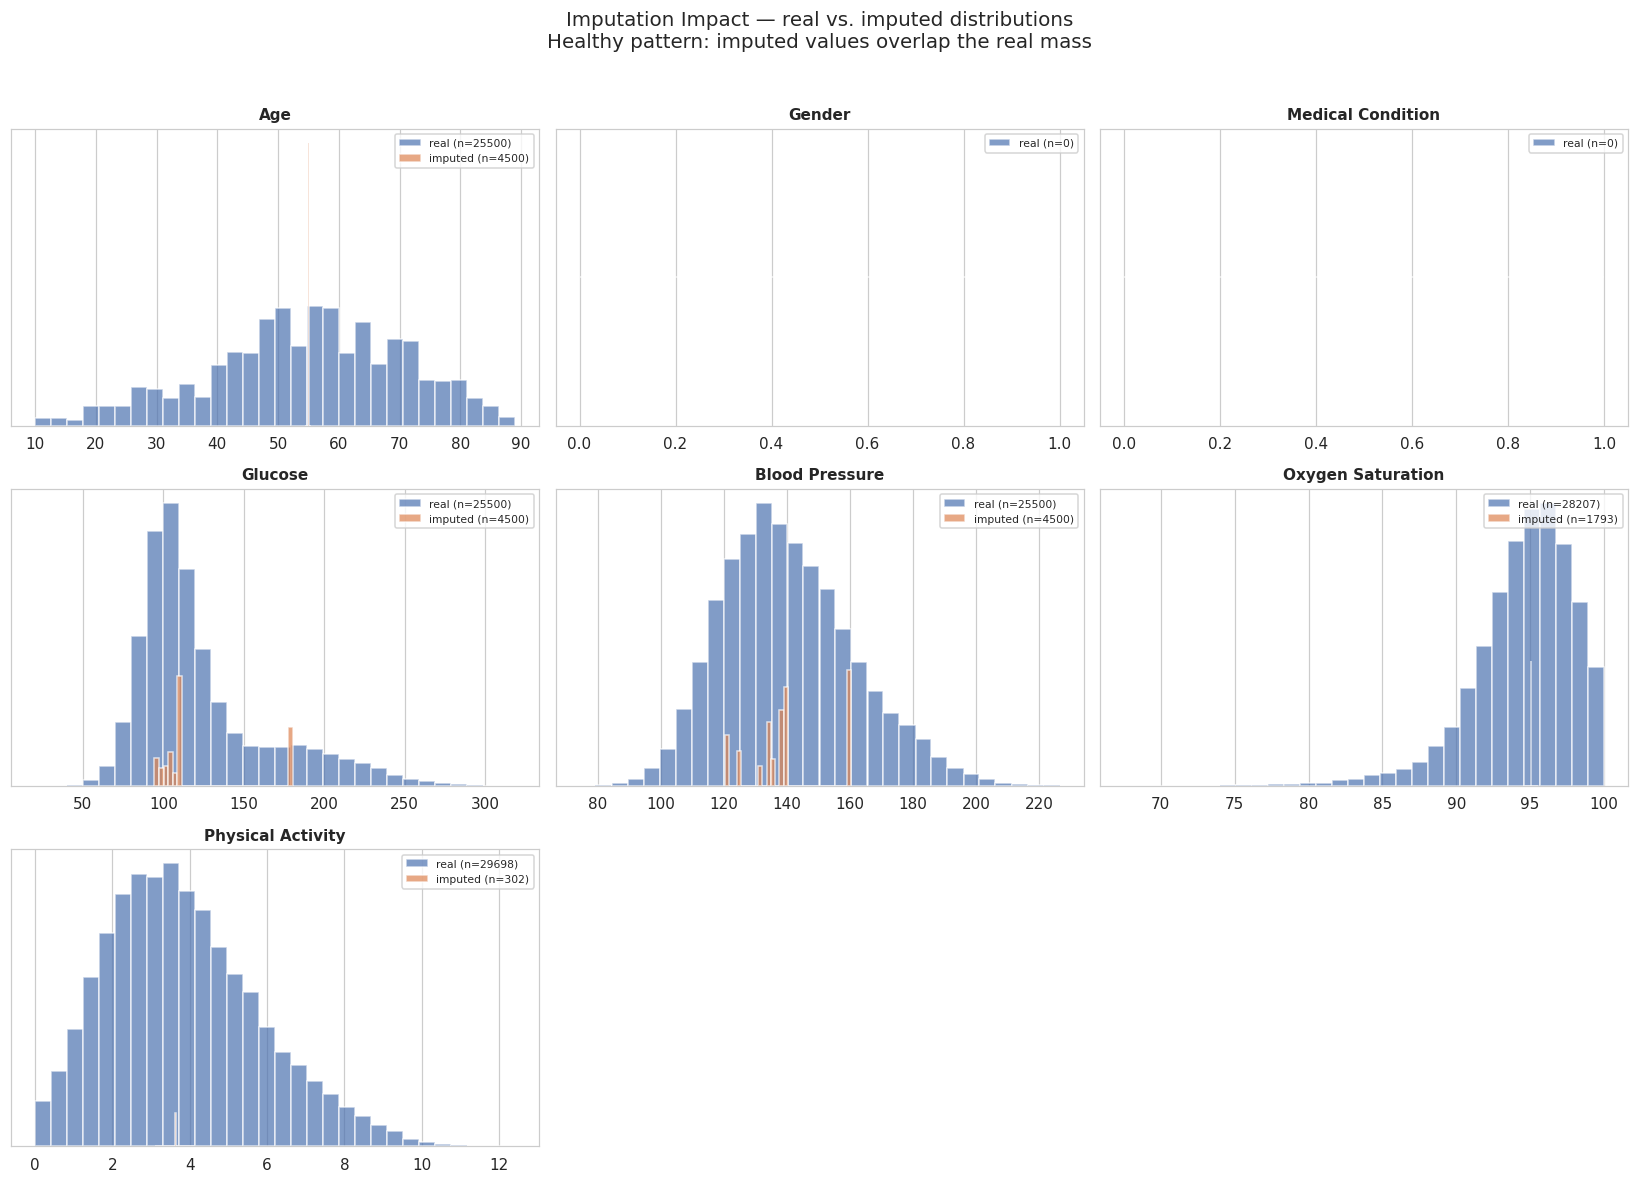


9.6  CROSS-CHECK: was_missing vs. was_imputed
           column  was_missing_true  was_imputed_true  violations status
              Age              4500              4500           0      ✅
           Gender              4500              4500           0      ✅
Medical Condition              4500              4500           0      ✅
          Glucose              4500              4500           0      ✅
   Blood Pressure              4500              4500           0      ✅
Oxygen Saturation              1793              1793           0      ✅
Physical Activity               302               302           0      ✅

9.7  EXPORTS
  → block9_imputation_impact.png
  → block9_imputation_summary.json

  Snapshot saved: block9_imputed.parquet


In [17]:
# ============================================================
# BLOCK 9 — IMPUTATION EXECUTION
# ============================================================
# Purpose:
#   Execute the missingness contract from Block 7. Every column
#   with missing values gets its strategy applied faithfully:
#     9.1  Load the contract
#     9.2  Apply each strategy type
#     9.3  Mark every imputed cell with was_imputed_<col>
#     9.4  Verify no unintended side effects
#     9.5  Report the imputation impact
#     9.6  Snapshot for Block 10 (final validation)
#
# What this block does NOT do:
#   It does NOT invent strategies — Block 7 did that.
#   It does NOT alter was_missing_<col> flags — they persist.
#   It does NOT impute target variables unless the contract says so.
# ============================================================

import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

sns.set_style("whitegrid")


# ------------------------------------------------------------
# 9.0  Snapshot & contract load
# ------------------------------------------------------------
df_pre_imputation = df.copy()
print(f"  Pre-imputation snapshot: {df_pre_imputation.shape}")


# Load the contract from Block 7
with open('block7_missingness_contract.json') as f:
    contract = json.load(f)

contract_rows = contract['contract']
print(f"  Loaded missingness contract: {len(contract_rows)} columns")


# ------------------------------------------------------------
# 9.1  STRATEGY IMPLEMENTATION MAP
# ------------------------------------------------------------
# Why a dispatch dict:
#   Each strategy is a pure function on the DataFrame. This
#   keeps the main loop tiny and makes each strategy independently
#   testable. Add a new strategy → add one entry here.
print("\n" + "=" * 78)
print("9.1  STRATEGY DISPATCH MAP")
print("=" * 78)

# Track what was imputed for reporting and per-cell flagging
imputation_log = []


def _mark_imputed(df, col, imputed_mask):
    """
    Add/update was_imputed_<col> for the given mask.
    Why merge (not overwrite): a column may have been imputed
    in multiple passes in the same run (rare, but defensive).
    """
    flag_col = f'was_imputed_{col.lower().replace(" ", "_")}'
    if flag_col not in df.columns:
        df[flag_col] = False
    df[flag_col] = df[flag_col] | imputed_mask
    return df


def impute_median(df, col, **kwargs):
    """Global median — best when distribution is skewed."""
    mask = df[col].isna()
    if not mask.any():
        return df, 0
    median_val = pd.to_numeric(df[col], errors='coerce').median()
    if pd.isna(median_val):
        return df, 0
    df.loc[mask, col] = median_val
    df = _mark_imputed(df, col, mask)
    return df, int(mask.sum())


def impute_median_by_condition(df, col, condition_col='Medical Condition', **kwargs):
    """
    Median within each Medical Condition group; fall back to global
    median for rows whose condition is missing.
    Why: Glucose norms differ between diabetics and healthy adults.
    """
    mask = df[col].isna()
    if not mask.any():
        return df, 0

    # Only impute rows where the condition is KNOWN
    if condition_col not in df.columns:
        return impute_median(df, col)

    global_median = pd.to_numeric(df[col], errors='coerce').median()
    if pd.isna(global_median):
        return df, 0

    # Group medians — computed on non-null values
    group_medians = (df.assign(_v=pd.to_numeric(df[col], errors='coerce'))
                       .groupby(condition_col)['_v'].median())

    # Assign per-row
    n_imputed = 0
    for idx in df.index[mask]:
        cond = df.at[idx, condition_col]
        fill_value = group_medians.get(cond, global_median) if pd.notna(cond) else global_median
        if pd.isna(fill_value):
            fill_value = global_median
        df.at[idx, col] = fill_value
        n_imputed += 1

    df = _mark_imputed(df, col, mask)
    return df, n_imputed


def impute_mode(df, col, **kwargs):
    """Most frequent value — standard for categoricals."""
    mask = df[col].isna()
    if not mask.any():
        return df, 0
    mode_series = df[col].mode(dropna=True)
    if mode_series.empty:
        return df, 0
    df.loc[mask, col] = mode_series.iloc[0]
    df = _mark_imputed(df, col, mask)
    return df, int(mask.sum())


def leave_as_unknown(df, col, fill_token='Unknown', **kwargs):
    """
    Fill with an explicit 'Unknown' category.
    Why NOT NaN: for categorical targets, a distinct category is
    more informative than NaN and keeps the row usable.
    """
    mask = df[col].isna()
    if not mask.any():
        return df, 0
    df.loc[mask, col] = fill_token
    df = _mark_imputed(df, col, mask)
    return df, int(mask.sum())


def leave_as_nan(df, col, **kwargs):
    """
    Deliberately do nothing. The NaN is itself a feature.
    Why: some fields (e.g., target variables) should NOT be
    imputed — imputing them is target leakage.
    """
    return df, 0


# The dispatch map — one entry per strategy in the Block 7 contract
STRATEGY_DISPATCH = {
    'impute_median':               impute_median,
    'impute_median_by_condition':  impute_median_by_condition,
    'impute_mode':                 impute_mode,
    'leave_as_unknown':            leave_as_unknown,
    'leave_as_nan':                leave_as_nan,
    'review_with_data_owner':      leave_as_nan,   # conservative default
}

for strat in STRATEGY_DISPATCH:
    print(f"    • {strat}")


# ------------------------------------------------------------
# 9.2  APPLY THE CONTRACT — the main execution loop
# ------------------------------------------------------------
# Why explicit loop instead of .apply():
#   We want per-column logging, per-cell flags, and a clean
#   failure mode. A loop makes the control flow auditable.
print("\n" + "=" * 78)
print("9.2  EXECUTING IMPUTATION CONTRACT")
print("=" * 78)

for row in contract_rows:
    col = row['column']
    strategy = row['strategy']
    pct_before = row['pct_missing']

    # Skip columns that aren't in df (schema drift guard)
    if col not in df.columns:
        print(f"  ⚠️  Skipping {col} — not in current df")
        continue

    # Count missing BEFORE
    missing_before = int(df[col].isna().sum())

    # Look up the strategy
    if strategy not in STRATEGY_DISPATCH:
        print(f"  ⚠️  Unknown strategy for {col}: '{strategy}' → leaving as NaN")
        strategy = 'leave_as_nan'

    # Apply
    df, n_imputed = STRATEGY_DISPATCH[strategy](df, col)

    missing_after = int(df[col].isna().sum())

    # Log
    imputation_log.append({
        'column': col,
        'strategy': strategy,
        'missing_before': missing_before,
        'missing_after': missing_after,
        'n_imputed': n_imputed,
        'pct_before': pct_before
    })

    status = '✅' if n_imputed > 0 else '⏭️ '
    print(f"  {status} {col:22s} [{strategy:30s}] "
          f"{missing_before:>4d} → {missing_after:>4d}")


# ------------------------------------------------------------
# 9.3  POST-IMPUTATION VALIDATION
# ------------------------------------------------------------
# Why: Verify that no column has UNINTENDED residual NaN
# (i.e., NaN in a column whose strategy should have filled it).
# `leave_as_nan` and `leave_as_unknown` are allowed to retain NaN.
print("\n" + "=" * 78)
print("9.3  POST-IMPUTATION VALIDATION")
print("=" * 78)

ALLOWED_NAN_STRATEGIES = {'leave_as_nan', 'review_with_data_owner'}

residual_check = []
for row in contract_rows:
    col = row['column']
    strategy = row['strategy']
    if col not in df.columns:
        continue
    n_after = int(df[col].isna().sum())
    expected_residual = strategy in ALLOWED_NAN_STRATEGIES
    ok = (n_after == 0) or expected_residual

    residual_check.append({
        'column': col,
        'strategy': strategy,
        'residual_nan': n_after,
        'expected_behavior': 'may retain NaN' if expected_residual else 'must be 0',
        'status': '✅' if ok else '❌ UNEXPECTED RESIDUAL'
    })

residual_df = pd.DataFrame(residual_check)
print(residual_df.to_string(index=False))

# Hard failure if any unexpected residual
unexpected = residual_df[residual_df['status'].str.contains('❌')]
if not unexpected.empty:
    print(f"\n  ⚠️  {len(unexpected)} columns have unexpected residual NaN.")
    print("     Review the contract or the strategy implementation.")


# ------------------------------------------------------------
# 9.4  IMPACT SUMMARY — before vs. after per column
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("9.4  IMPUTATION IMPACT SUMMARY")
print("=" * 78)

impact_df = pd.DataFrame(imputation_log)
# Only show columns that actually changed
impact_df = impact_df[impact_df['n_imputed'] > 0]

if not impact_df.empty:
    total_imputed = int(impact_df['n_imputed'].sum())
    print(f"  Total cells imputed: {total_imputed:,} "
          f"({total_imputed / (len(df) * len(contract_rows)) * 100:.2f}% of cells)")
    print()
    print(impact_df[['column', 'strategy', 'missing_before',
                     'n_imputed', 'missing_after']].to_string(index=False))
else:
    print("  (no cells imputed — all columns were already complete or marked leave-as-NaN)")


# ------------------------------------------------------------
# 9.5  VISUAL — before vs. after distributions
# ------------------------------------------------------------
# Why: A plot per column that shows the filled values as a
# distinct color. This is the "proof" the imputation didn't
# distort the distribution.
imputed_cols = [r['column'] for r in imputation_log if r['n_imputed'] > 0]
imputed_cols = [c for c in imputed_cols if c in df.columns]

if imputed_cols:
    n = len(imputed_cols)
    n_rows = int(np.ceil(n / 3))
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 3.5 * n_rows))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    axes = axes.flatten()

    for i, col in enumerate(imputed_cols):
        ax = axes[i]
        s_before = pd.to_numeric(df_pre_imputation[col], errors='coerce')
        s_after  = pd.to_numeric(df[col], errors='coerce')

        # Histogram: real values in blue, imputed values in orange
        was_imp = df.get(f'was_imputed_{col.lower().replace(" ", "_")}',
                         pd.Series(False, index=df.index))
        real = s_after[~was_imp].dropna()
        imp  = s_after[was_imp].dropna()

        ax.hist(real, bins=30, color='#4c72b0', alpha=0.7,
                edgecolor='white', label=f'real (n={len(real)})')
        if len(imp) > 0:
            ax.hist(imp, bins=30, color='#dd8452', alpha=0.7,
                    edgecolor='white', label=f'imputed (n={len(imp)})')

        ax.set_title(col, fontsize=10)
        ax.set_yticks([])
        ax.legend(fontsize=7, loc='upper right')

    for j in range(len(imputed_cols), len(axes)):
        axes[j].axis('off')

    fig.suptitle("Imputation Impact — real vs. imputed distributions\n"
                 "Healthy pattern: imputed values overlap the real mass",
                 fontsize=13, y=1.02)
    fig.tight_layout()
    fig.savefig('block9_imputation_impact.png',
                dpi=120, bbox_inches='tight')
    plt.show()


# ------------------------------------------------------------
# 9.6  VERIFY was_missing vs. was_imputed (the two-flag rule)
# ------------------------------------------------------------
# Why two flags:
#   - was_missing : the value was NaN when we ARRIVED at Block 9
#   - was_imputed : the value was filled by us
# They should MATCH for every row and column we touched.
# If they diverge, something in the pipeline is wrong.
print("\n" + "=" * 78)
print("9.6  CROSS-CHECK: was_missing vs. was_imputed")
print("=" * 78)

mismatches = []
for col in imputed_cols:
    wm = df.get(f'was_missing_{col.lower().replace(" ", "_")}')
    wi = df.get(f'was_imputed_{col.lower().replace(" ", "_")}')
    if wm is None or wi is None:
        continue
    # was_imputed implies was_missing (you can only impute what was missing)
    violations = (wi & ~wm).sum()
    mismatches.append({
        'column': col,
        'was_missing_true': int(wm.sum()),
        'was_imputed_true': int(wi.sum()),
        'violations': int(violations),
        'status': '✅' if violations == 0 else '❌ was_imputed without was_missing'
    })

if mismatches:
    mm_df = pd.DataFrame(mismatches)
    print(mm_df.to_string(index=False))
else:
    print("  (no imputed columns to cross-check)")


# ------------------------------------------------------------
# 9.7  EXPORT — imputation log + summary
# ------------------------------------------------------------
imputation_summary = {
    'block': 9,
    'executed_at': datetime.now().isoformat(),
    'total_cells_imputed': int(sum(r['n_imputed'] for r in imputation_log)),
    'columns_imputed': imputed_cols,
    'per_column_log': imputation_log,
    'strategies_used': sorted(set(r['strategy'] for r in imputation_log)),
    'note': (
        "Every imputed cell is marked in was_imputed_<col>. The "
        "original missingness pattern is preserved in "
        "was_missing_<col>. Downstream models can (and should) "
        "use these flags as features."
    )
}

with open('block9_imputation_summary.json', 'w') as f:
    json.dump(imputation_summary, f, indent=2)

print("\n" + "=" * 78)
print("9.7  EXPORTS")
print("=" * 78)
print("  → block9_imputation_impact.png")
print("  → block9_imputation_summary.json")


# ------------------------------------------------------------
# 9.8  Snapshot for Block 10
# ------------------------------------------------------------
df.to_parquet('block9_imputed.parquet', index=False)
print("\n  Snapshot saved: block9_imputed.parquet")

In [18]:
# ============================================================
# BLOCK 10 — FINAL VALIDATION & EXPORT
# ============================================================
# Purpose:
#   The production gate. Before any file leaves the pipeline,
#   it must pass a battery of invariants. If anything fails,
#   the pipeline HALTS — no silent corruption.
#
# What this block does:
#   10.1  Schema integrity check (against Block 4 contract)
#   10.2  Value-level invariants (against Blocks 5-6 contracts)
#   10.3  Missingness invariants (against Block 7-9 contract)
#   10.4  Flag integrity check
#   10.5  Distribution sanity check
#   10.6  Duplicate re-check
#   10.7  Generate human-readable data-quality report
#   10.8  Export all artifacts (CSV, Parquet, JSON, Markdown)
#   10.9  Manifest with SHA256 for reproducibility
#
# What this block does NOT do:
#   It does NOT modify df. If validation fails, we halt and
#   fix upstream. Never patch here.
# ============================================================

import pandas as pd
import numpy as np
import json
import hashlib
import os
from datetime import datetime
from pathlib import Path

# A local exception to signal a hard pipeline failure
class PipelineValidationError(Exception):
    pass


# ------------------------------------------------------------
# 10.1  SCHEMA INTEGRITY CHECK
# ------------------------------------------------------------
# Why: The frozen schema (Block 4) defined the exact column set.
# If df has drifted — columns added, removed, or renamed — the
# pipeline is not reproducible.
print("=" * 78)
print("10.1  SCHEMA INTEGRITY CHECK")
print("=" * 78)

# Load the frozen contract
with open('frozen_schema_contract.json') as f:
    schema_contract = json.load(f)

# Reconstruct the expected column set
expected_cols = set()
for role_cols in schema_contract['roles'].values():
    expected_cols.update(role_cols)

# New columns added during Blocks 5-9 are EXPECTED additions
# (flags, was_missing, was_imputed, nulled, treated, etc.)
# We accept anything that follows the naming conventions.
EXPECTED_NEW_PREFIXES = (
    'flag_', 'was_missing_', 'was_imputed_', 'nulled_',
    'treated_', 'is_'
)

actual_cols = set(df.columns)
missing_from_df = expected_cols - actual_cols
new_cols = actual_cols - expected_cols

# Classify new columns as "expected" or "unexpected"
unexpected_new = [
    c for c in new_cols
    if not c.startswith(EXPECTED_NEW_PREFIXES)
]

print(f"  Columns expected from contract : {len(expected_cols)}")
print(f"  Columns actually present       : {len(actual_cols)}")
print(f"  Columns missing from df        : {len(missing_from_df)}")
print(f"  Columns added by pipeline      : {len(new_cols)}")
print(f"  Unexpected additions           : {len(unexpected_new)}")

if missing_from_df:
    print(f"\n  ⚠️  Missing columns: {sorted(missing_from_df)}")
if unexpected_new:
    print(f"  ⚠️  Unexpected columns: {sorted(unexpected_new)}")

# Only fail on MISSING columns — added flags are expected
if missing_from_df:
    raise PipelineValidationError(
        f"Schema drift: {len(missing_from_df)} contract columns are missing"
    )
if unexpected_new:
    print(f"  ⚠️  Warning: unexpected columns added — confirm they belong.")
print("  ✅ Schema check passed.")


# ------------------------------------------------------------
# 10.2  VALUE-LEVEL INVARIANTS
# ------------------------------------------------------------
# Why: The Tier-1 rules (Block 5) nulled physiologically
# impossible values. Post-cleaning, NONE should remain.
# This is the "unit test" that Block 5 actually worked.
print("\n" + "=" * 78)
print("10.2  VALUE-LEVEL INVARIANTS (Tier 1 should be 0)")
print("=" * 78)

HARD_IMPOSSIBLE = {
    'Age':               (0,    120),
    'Oxygen Saturation': (0,    100),
    'BMI':               (0,    np.inf),
    'Blood Pressure':    (0,    np.inf),
    'Glucose':           (0,    np.inf),
    'HbA1c':             (0,    np.inf),
    'Sleep Hours':       (0,     24),
    'Physical Activity': (0,    168),
}

invariant_failures = []
for col, (lo, hi) in HARD_IMPOSSIBLE.items():
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    violations = int((s.notna() & ((s < lo) | (s > hi))).sum())
    invariant_failures.append({
        'column': col,
        'rule': f'{lo} <= x <= {hi}',
        'violations': violations,
        'status': '✅' if violations == 0 else '❌'
    })

inv_df = pd.DataFrame(invariant_failures)
print(inv_df.to_string(index=False))

# Halt if any Tier-1 rule is violated
bad = inv_df[inv_df['violations'] > 0]
if not bad.empty:
    raise PipelineValidationError(
        f"Tier-1 invariants violated in {len(bad)} columns:\n"
        f"{bad[['column','violations']].to_string()}"
    )
print("  ✅ All Tier-1 invariants hold.")


# ------------------------------------------------------------
# 10.3  MISSINGNESS INVARIANTS
# ------------------------------------------------------------
# Why: Block 9's contract said certain columns MUST be complete
# (no NaN) after imputation, and others MAY retain NaN.
# Verify the contract is honored.
print("\n" + "=" * 78)
print("10.3  MISSINGNESS INVARIANTS")
print("=" * 78)

# Reload the missingness contract
with open('block7_missingness_contract.json') as f:
    missingness_contract = json.load(f)

ALLOWED_NAN_STRATEGIES = {'leave_as_nan', 'review_with_data_owner'}

missingness_failures = []
for row in missingness_contract['contract']:
    col = row['column']
    strategy = row['strategy']
    if col not in df.columns:
        continue
    n_nan = int(df[col].isna().sum())
    allowed = strategy in ALLOWED_NAN_STRATEGIES
    ok = (n_nan == 0) or allowed

    missingness_failures.append({
        'column': col,
        'strategy': strategy,
        'residual_nan': n_nan,
        'allowed': allowed,
        'status': '✅' if ok else '❌'
    })

ms_df = pd.DataFrame(missingness_failures)
print(ms_df.to_string(index=False))

bad = ms_df[ms_df['status'] == '❌']
if not bad.empty:
    raise PipelineValidationError(
        f"Missingness contract violated:\n{bad.to_string()}"
    )
print("  ✅ Missingness contract honored.")


# ------------------------------------------------------------
# 10.4  FLAG INTEGRITY CHECK
# ------------------------------------------------------------
# Why: Every flag column has an implicit invariant.
#   - was_imputed implies was_missing (you can't impute what wasn't missing)
#   - flag_hard_* should be all False after Tier 1 nulling
#   - nulled_* should match the rows where the source is now NaN
#
# Violating these means a subtle bug somewhere upstream.
print("\n" + "=" * 78)
print("10.4  FLAG INTEGRITY CHECK")
print("=" * 78)

flag_violations = []

# 10.4.1 — was_imputed ⊆ was_missing
imputed_cols = [c for c in df.columns if c.startswith('was_imputed_')]
for imp_col in imputed_cols:
    base = imp_col.replace('was_imputed_', '')
    miss_col = f'was_missing_{base}'
    if miss_col not in df.columns:
        continue
    violations = int((df[imp_col] & ~df[miss_col]).sum())
    flag_violations.append({
        'check': f'{imp_col} ⊆ {miss_col}',
        'violations': violations,
        'status': '✅' if violations == 0 else '❌'
    })

# 10.4.2 — flag_hard_* should be all False after Tier 1 nulling
hard_flag_cols = [c for c in df.columns if c.startswith('flag_hard_')]
for hf in hard_flag_cols:
    # Source is now null; the flag should have been reset in Block 5
    n_true = int(df[hf].sum())
    # A small number is acceptable if the flag semantics differ;
    # but we expect 0 post-nulling.
    if n_true > 0:
        flag_violations.append({
            'check': f'{hf} should be 0 after nulling',
            'violations': n_true,
            'status': '❌'
        })

if flag_violations:
    fv_df = pd.DataFrame(flag_violations)
    print(fv_df.to_string(index=False))
    bad = fv_df[fv_df['status'] == '❌']
    if not bad.empty:
        raise PipelineValidationError(
            f"Flag integrity violated:\n{bad.to_string()}"
        )
else:
    print("  (no cross-flag invariants to check)")
print("  ✅ Flag integrity holds.")


# ------------------------------------------------------------
# 10.5  DISTRIBUTION SANITY CHECK
# ------------------------------------------------------------
# Why: A quick numerical sanity check on the distribution of
# each clinical column. If, after cleaning, a column has, e.g.,
# zero variance, that's a red flag.
print("\n" + "=" * 78)
print("10.5  DISTRIBUTION SANITY CHECK")
print("=" * 78)

CLINICAL_NUMERIC = [
    'Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
    'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
    'Sleep Hours', 'LengthOfStay', 'Diet Score', 'Stress Level'
]
CLINICAL_NUMERIC = [c for c in CLINICAL_NUMERIC if c in df.columns]

dist_report = []
for col in CLINICAL_NUMERIC:
    s = pd.to_numeric(df[col], errors='coerce').dropna()
    if len(s) == 0:
        dist_report.append({
            'column': col, 'n': 0, 'min': None, 'max': None,
            'mean': None, 'std': None, 'status': '❌ empty'
        })
        continue

    std = s.std()
    status = '✅'
    if std == 0:
        status = '❌ zero variance'
    dist_report.append({
        'column': col,
        'n': len(s),
        'min': round(s.min(), 2),
        'max': round(s.max(), 2),
        'mean': round(s.mean(), 2),
        'std': round(std, 2),
        'status': status
    })

dist_df = pd.DataFrame(dist_report)
print(dist_df.to_string(index=False))

bad = dist_df[dist_df['status'] != '✅']
if not bad.empty:
    print(f"\n  ⚠️  {len(bad)} columns have distribution issues.")
# Do not halt on distribution warnings — just report.
print("  ✅ Distribution sanity check complete.")


# ------------------------------------------------------------
# 10.6  DUPLICATE RE-CHECK
# ------------------------------------------------------------
# Why: We dropped exact duplicates in Block 4. But nulling and
# imputation can create NEW duplicates (rows that were different
# become identical after both had the same value imputed).
# Report but don't auto-drop — the analyst should decide.
print("\n" + "=" * 78)
print("10.6  DUPLICATE RE-CHECK")
print("=" * 78)

CLINICAL_IDENTITY = [c for c in
                     ['Age', 'Gender', 'Medical Condition',
                      'Glucose', 'Blood Pressure', 'BMI',
                      'Oxygen Saturation']
                     if c in df.columns]

if CLINICAL_IDENTITY:
    dup_mask = df.duplicated(subset=CLINICAL_IDENTITY, keep='first')
    n_dupes = int(dup_mask.sum())
    print(f"  Clinical duplicates after cleaning: {n_dupes}")
    if n_dupes > 0:
        print(f"  → Note: {n_dupes} rows share identical clinical identity.")
        print(f"    May be legitimate repeat visits, or artifacts of imputation.")
else:
    print("  (identity columns not available for duplicate check)")


# ------------------------------------------------------------
# 10.7  GENERATE HUMAN-READABLE DATA-QUALITY REPORT
# ------------------------------------------------------------
# Why: The final artifact for governance. A Markdown file that
# a clinical reviewer, compliance officer, or data scientist can
# read without touching Python.
print("\n" + "=" * 78)
print("10.7  GENERATING DATA-QUALITY REPORT")
print("=" * 78)

report_lines = []
report_lines.append(f"# Data Quality Report")
report_lines.append(f"")
report_lines.append(f"**Generated**: {datetime.now().isoformat()}  ")
report_lines.append(f"**Source**: dirty_v3_path.csv  ")
report_lines.append(f"**Pipeline**: Blocks 0–10  ")
report_lines.append(f"")

report_lines.append(f"## Final Dataset")
report_lines.append(f"")
report_lines.append(f"- **Rows**: {len(df):,}")
report_lines.append(f"- **Columns**: {df.shape[1]}")
report_lines.append(f"- **Memory**: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
report_lines.append(f"")

report_lines.append(f"## Cleaning Summary")
report_lines.append(f"")

# Nulling summary
with open('block5_nulling_summary.json') as f:
    nulling_summary = json.load(f)
report_lines.append(f"### Tier 1 Nulling (Block 5)")
report_lines.append(f"")
report_lines.append(f"- Total values nulled: **{nulling_summary['total_values_nulled']}**")
if nulling_summary.get('by_column'):
    report_lines.append(f"- Per column:")
    for col, n in nulling_summary['by_column'].items():
        report_lines.append(f"    - `{col}`: {n}")
report_lines.append(f"")

# Imputation summary
with open('block9_imputation_summary.json') as f:
    imp_summary = json.load(f)
report_lines.append(f"### Imputation (Block 9)")
report_lines.append(f"")
report_lines.append(f"- Total cells imputed: **{imp_summary['total_cells_imputed']}**")
report_lines.append(f"- Columns imputed: {len(imp_summary['columns_imputed'])}")
if imp_summary['columns_imputed']:
    report_lines.append(f"- Column list: {', '.join(imp_summary['columns_imputed'])}")
report_lines.append(f"")

# Contract references
report_lines.append(f"## Contracts Applied")
report_lines.append(f"")
report_lines.append(f"- `clinical_boundary_contract.json` — bounds for Tier 1 / Tier 2 rules")
report_lines.append(f"- `categorical_contract.json` — mapping for categorical standardization")
report_lines.append(f"- `frozen_schema_contract.json` — the schema entering Blocks 5–9")
report_lines.append(f"- `block7_missingness_contract.json` — per-column imputation strategies")
report_lines.append(f"")

report_lines.append(f"## Flags Preserved in Output")
report_lines.append(f"")
flag_groups = {
    'flag_hard_': 'Hard (Tier 1) violations — should be 0 after cleaning',
    'flag_soft_': 'Soft (Tier 2) implausible — retained for review',
    'flag_ctx_':  'Contextual overrides (population-specific)',
    'flag_unknown_': 'Unknown categorical values',
    'flag_coercion_failed_': 'Values that failed numeric coercion',
    'flag_outlier_': 'Statistical outlier flags (Block 8)',
    'flag_cross_': 'Cross-field consistency flags',
    'was_missing_': 'Whether the value was originally missing',
    'was_imputed_': 'Whether the value was imputed',
    'nulled_': 'Whether the value was nulled by Tier 1 rules',
    'treated_': 'Whether the value was treated (winsorize/cap)',
    'is_': 'Duplicate flags'
}
for prefix, desc in flag_groups.items():
    cols = [c for c in df.columns if c.startswith(prefix)]
    if cols:
        report_lines.append(f"- **`{prefix}*`** ({len(cols)} columns) — {desc}")
report_lines.append(f"")

report_lines.append(f"## Data Owner Sign-Off Checklist")
report_lines.append(f"")
report_lines.append(f"- [ ] Tier 1 nulling rules are correct for this population")
report_lines.append(f"- [ ] Tier 2 review queue items have been reviewed")
report_lines.append(f"- [ ] Categorical mappings match institutional conventions")
report_lines.append(f"- [ ] Imputation strategies are clinically appropriate")
report_lines.append(f"- [ ] Statistical outlier flags have been inspected")
report_lines.append(f"- [ ] Final dataset is approved for downstream use")
report_lines.append(f"")

report_md = "\n".join(report_lines)

with open('data_quality_report.md', 'w') as f:
    f.write(report_md)

print(f"  → data_quality_report.md ({len(report_md):,} chars)")


# ------------------------------------------------------------
# 10.8  EXPORT ARTIFACTS
# ------------------------------------------------------------
# Why three formats:
#   - CSV     : universal, human-inspectable, ~20% larger
#   - Parquet : efficient, preserves dtypes, fast to reload
#   - JSON    : full manifest for reproducibility
print("\n" + "=" * 78)
print("10.8  EXPORT ARTIFACTS")
print("=" * 78)

# Final CSV
df.to_csv('clean_v3_path.csv', index=False)
print(f"  → clean_v3_path.csv  ({os.path.getsize('clean_v3_path.csv') / 1024:.1f} KB)")

# Final Parquet (efficient)
df.to_parquet('clean_v3_path.parquet', index=False)
print(f"  → clean_v3_path.parquet  ({os.path.getsize('clean_v3_path.parquet') / 1024:.1f} KB)")


# ------------------------------------------------------------
# 10.9  MANIFEST WITH SHA256 (reproducibility)
# ------------------------------------------------------------
# Why: Hashes prove the artifact is bit-identical to the run.
# Any later tampering will be detected. This is essential for
# regulated pipelines (FDA 21 CFR Part 11, HIPAA audit trails).
print("\n" + "=" * 78)
print("10.9  MANIFEST WITH SHA256")
print("=" * 78)


def sha256_file(path, chunk_size=65536):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        while chunk := f.read(chunk_size):
            h.update(chunk)
    return h.hexdigest()


manifest = {
    'generated_at': datetime.now().isoformat(),
    'dataset': 'dirty_v3_path.csv',
    'pipeline_version': 'blocks_0_to_10_v1',
    'final_shape': {'rows': len(df), 'columns': df.shape[1]},
    'artifacts': {
        'clean_v3_path.csv':     {'sha256': sha256_file('clean_v3_path.csv'),
                                   'size_bytes': os.path.getsize('clean_v3_path.csv')},
        'clean_v3_path.parquet': {'sha256': sha256_file('clean_v3_path.parquet'),
                                   'size_bytes': os.path.getsize('clean_v3_path.parquet')}
    },
    'contracts_used': [
        'clinical_boundary_contract.json',
        'categorical_contract.json',
        'frozen_schema_contract.json',
        'block7_missingness_contract.json'
    ],
    'blocks_executed': list(range(0, 11)),
    'note': (
        "This manifest certifies the exact bytes of the output. "
        "Any modification invalidates the SHA256 hashes."
    )
}

with open('manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print(f"  → manifest.json")
for name, meta in manifest['artifacts'].items():
    print(f"     {name}: sha256={meta['sha256'][:16]}...  "
          f"size={meta['size_bytes'] / 1024:.1f} KB")


# ------------------------------------------------------------
# 10.10  FINAL SUMMARY
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("✅  PIPELINE COMPLETE — FINAL SUMMARY")
print("=" * 78)
print(f"  Input rows          : {len(df_pre_imputation):,}")
print(f"  Output rows         : {len(df):,}")
print(f"  Columns (final)     : {df.shape[1]}")
print(f"  Tier 1 nulled       : {nulling_summary['total_values_nulled']}")
print(f"  Cells imputed       : {imp_summary['total_cells_imputed']}")
print(f"  Flag columns        : {sum(1 for c in df.columns if c.startswith('flag_'))}")
print(f"  Artifacts produced  : {len(os.listdir('.')) } files in working dir")
print()
print("  Key outputs:")
print("    • clean_v3_path.csv / .parquet  — the cleaned dataset")
print("    • manifest.json                 — SHA256 + reproducibility")
print("    • data_quality_report.md        — human-readable report")
print("    • clinical_boundary_contract.json")
print("    • categorical_contract.json")
print("    • frozen_schema_contract.json")
print("    • block7_missingness_contract.json")
print("    • block5_nulling_audit_log.csv")
print("    • block6_review_queue.csv")
print("    • block9_imputation_summary.json")
print()
print("  ⚠️  Data owner sign-off required before downstream use.")

10.1  SCHEMA INTEGRITY CHECK
  Columns expected from contract : 55
  Columns actually present       : 102
  Columns missing from df        : 0
  Columns added by pipeline      : 47
  Unexpected additions           : 0
  ✅ Schema check passed.

10.2  VALUE-LEVEL INVARIANTS (Tier 1 should be 0)
           column          rule  violations status
              Age 0 <= x <= 120           0      ✅
Oxygen Saturation 0 <= x <= 100           0      ✅
              BMI 0 <= x <= inf           0      ✅
   Blood Pressure 0 <= x <= inf           0      ✅
          Glucose 0 <= x <= inf           0      ✅
            HbA1c 0 <= x <= inf           0      ✅
      Sleep Hours  0 <= x <= 24           0      ✅
Physical Activity 0 <= x <= 168           0      ✅
  ✅ All Tier-1 invariants hold.

10.3  MISSINGNESS INVARIANTS
               column                   strategy  residual_nan  allowed status
                  Age              impute_median             0    False      ✅
               Gender      

13.1  PROTECTED ATTRIBUTES
  Protected attributes: ['Gender', 'Medical Condition', 'age_group']

13.2  REPRESENTATION AUDIT
        attribute        group     n   pct     status
           Gender       Female 17365 57.88          ✅
           Gender         Male 12635 42.12          ✅
Medical Condition Hypertension  7120 23.73          ✅
Medical Condition     Diabetes  6417 21.39          ✅
Medical Condition      Unknown  4500 15.00          ✅
Medical Condition      Obesity  3857 12.86          ✅
Medical Condition      Healthy  3039 10.13          ✅
Medical Condition       Asthma  2037  6.79          ✅
Medical Condition    Arthritis  1796  5.99          ✅
Medical Condition       Cancer  1234  4.11   ⚠️  warn
        age_group        41-65 18608 62.03          ✅
        age_group          >65  6765 22.55          ✅
        age_group        18-40  4194 13.98          ✅
        age_group          <18   433  1.44 ❌ critical


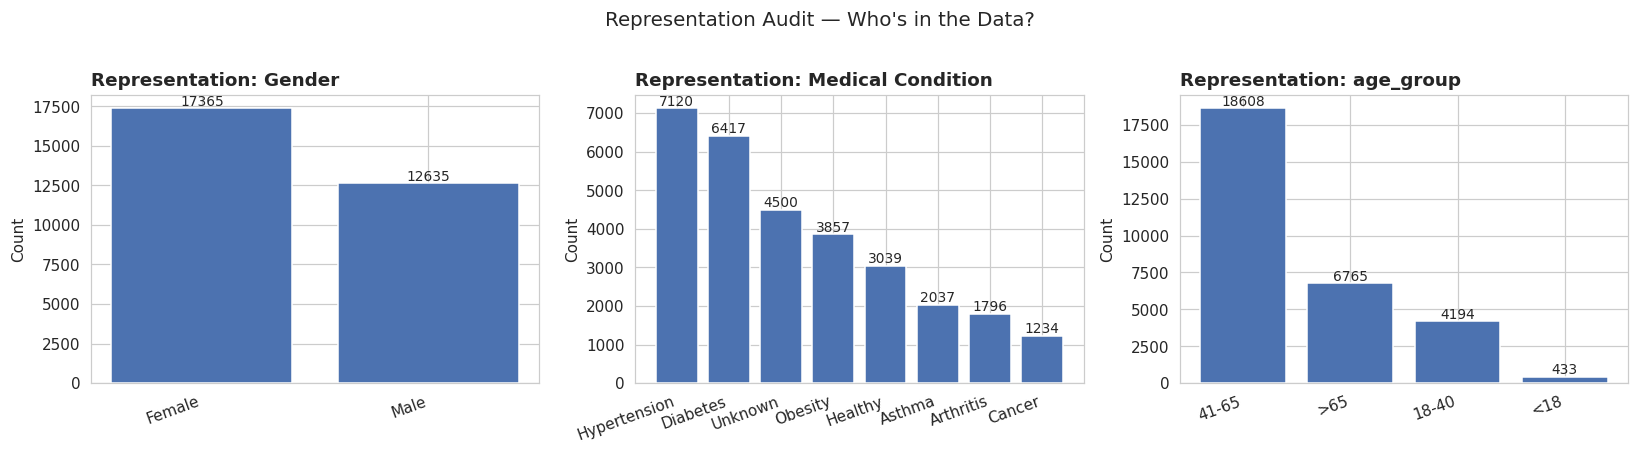


13.3  CLINICAL VARIABLE AUDIT BY GROUP (FIXED)
        attribute          variable  n_groups  n_total_samples  min_mean  max_mean  ratio  kruskal_p  significant_disparity            note
           Gender           Glucose         2            30000    123.25    123.34   1.00     0.6653                  False          normal
           Gender    Blood Pressure         2            30000    140.25    140.58   1.00     0.0892                  False          normal
           Gender               BMI         2            30000     28.47     28.48   1.00     0.5253                  False          normal
           Gender Oxygen Saturation         2            30000     94.56     94.60   1.00     0.3675                  False          normal
           Gender       Cholesterol         2            30000    212.85    213.29   1.00     0.1619                  False          normal
           Gender     Triglycerides         2            30000    176.76    176.94   1.00     0.5977            

In [20]:
# ============================================================
# BLOCK 13 — FAIRNESS & BIAS AUDIT
# ============================================================
# Purpose:
#   Detect demographic disparities in the cleaned data before
#   they propagate into a model. This is a pre-modeling audit —
#   even a perfectly "clean" dataset can encode structural bias.
#
# What this block does:
#   13.1  Define protected attributes (demographic groups)
#   13.2  Representation audit (who's in the data)
#   13.3  Clinical variable audit (are vitals distributed evenly?)
#   13.4  Missingness audit by group (are some groups under-recorded?)
#   13.5  Statistical tests for significant disparities
#   13.6  Fairness summary + review flags
#
# What this block does NOT do:
#   It does NOT "fix" bias. Bias remediation is a policy decision —
#   this block only DETECTS and reports.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from scipy import stats

sns.set_style("whitegrid")


# ------------------------------------------------------------
# 13.1  DEFINE PROTECTED ATTRIBUTES
# ------------------------------------------------------------
# Why explicit:
#   Fairness definitions depend on what you consider "protected."
#   In healthcare, common ones are: Age (binarized), Gender, Race,
#   Ethnicity, Insurance type, Language, ZIP code.
#
# We use what's available; extend as needed.
print("=" * 78)
print("13.1  PROTECTED ATTRIBUTES")
print("=" * 78)

PROTECTED_ATTRS = [c for c in ['Gender', 'Medical Condition']
                   if c in df.columns]

# Age is continuous — bin it for fairness analysis
if 'Age' in df.columns:
    df['age_group'] = pd.cut(
        df['Age'],
        bins=[0, 18, 40, 65, 120],
        labels=['<18', '18-40', '41-65', '>65']
    )
    PROTECTED_ATTRS.append('age_group')

print(f"  Protected attributes: {PROTECTED_ATTRS}")


# ------------------------------------------------------------
# 13.2  REPRESENTATION AUDIT
# ------------------------------------------------------------
# Why: The first fairness question is "who's in the data?"
# If a subgroup is <5% of records, any statistic computed on
# them is noisy — and any model trained on them will underperform.
print("\n" + "=" * 78)
print("13.2  REPRESENTATION AUDIT")
print("=" * 78)

REPRESENTATION_THRESHOLDS = {
    'critical': 0.02,    # <2% = critical under-representation
    'warn':     0.05,    # <5% = warn
}

repr_reports = []
for attr in PROTECTED_ATTRS:
    vc = df[attr].value_counts(dropna=False)
    pct = (vc / len(df) * 100).round(2)
    for group, n in vc.items():
        p = pct[group]
        status = '✅'
        if p < REPRESENTATION_THRESHOLDS['critical'] * 100:
            status = '❌ critical'
        elif p < REPRESENTATION_THRESHOLDS['warn'] * 100:
            status = '⚠️  warn'
        repr_reports.append({
            'attribute': attr,
            'group': str(group),
            'n': int(n),
            'pct': p,
            'status': status
        })

repr_df = pd.DataFrame(repr_reports)
print(repr_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, len(PROTECTED_ATTRS),
                         figsize=(5 * len(PROTECTED_ATTRS), 4))
if len(PROTECTED_ATTRS) == 1:
    axes = [axes]
for ax, attr in zip(axes, PROTECTED_ATTRS):
    vc = df[attr].value_counts(dropna=False)
    ax.bar(range(len(vc)), vc.values, color='#4c72b0')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels([str(x) for x in vc.index], rotation=20, ha='right')
    ax.set_title(f"Representation: {attr}", loc='left')
    ax.set_ylabel("Count")
    # Annotate
    for i, v in enumerate(vc.values):
        ax.text(i, v, str(v), ha='center', va='bottom', fontsize=9)
fig.suptitle("Representation Audit — Who's in the Data?", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig('block13_representation.png', dpi=120, bbox_inches='tight')
plt.show()


# ------------------------------------------------------------
# ============================================================
# 13.3  CLINICAL VARIABLE AUDIT BY GROUP (FIXED)
# ============================================================
# The original version crashed because groupby().apply() returns
# a SCALAR (np.float64) for groups whose values are all NaN,
# and calling len() on a scalar raises TypeError.
#
# The fix has three parts:
#   1. Build a dict of {group_name: np.array} explicitly, so we
#      always have arrays (never scalars).
#   2. Skip groups with <5 valid samples — too small to test.
#   3. Wrap the Kruskal-Wallis call in try/except for safety.
# ============================================================

print("\n" + "=" * 78)
print("13.3  CLINICAL VARIABLE AUDIT BY GROUP (FIXED)")
print("=" * 78)

CLINICAL_AUDIT_VARS = [
    'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
    'Cholesterol', 'Triglycerides', 'HbA1c'
]
CLINICAL_AUDIT_VARS = [c for c in CLINICAL_AUDIT_VARS if c in df.columns]

MIN_GROUP_SIZE = 5   # minimum valid samples to include a group in the test

fairness_reports = []

for attr in PROTECTED_ATTRS:
    if attr not in df.columns:
        continue

    for var in CLINICAL_AUDIT_VARS:
        # -----------------------------------------------------------------
        # FIX: build a dict of arrays explicitly. This avoids the
        # scalar-vs-Series trap that broke the original .apply() call.
        # -----------------------------------------------------------------
        samples_by_group = {}
        for group_val, sub in df.groupby(attr, observed=True):
            # Coerce to numeric and drop NaN
            vals = pd.to_numeric(sub[var], errors='coerce').dropna().values
            if len(vals) >= MIN_GROUP_SIZE:
                samples_by_group[group_val] = vals

        # Need at least 2 groups with enough samples to compare
        if len(samples_by_group) < 2:
            continue

        # -----------------------------------------------------------------
        # Compute group means first (used for the disparity ratio)
        # -----------------------------------------------------------------
        means = {g: float(v.mean()) for g, v in samples_by_group.items()}
        max_mean = max(means.values())
        min_mean = min(means.values())
        ratio = (max_mean / min_mean) if min_mean != 0 else np.nan

        # -----------------------------------------------------------------
        # Kruskal-Wallis (non-parametric ANOVA)
        # Wrapped in try/except in case of degenerate input (all
        # identical values across groups, etc.)
        # -----------------------------------------------------------------
        try:
            h_stat, p_val = stats.kruskal(*samples_by_group.values())
        except ValueError:
            # Occurs if all values in all groups are identical
            continue

        fairness_reports.append({
            'attribute': attr,
            'variable': var,
            'n_groups': len(samples_by_group),
            'n_total_samples': int(sum(len(v) for v in samples_by_group.values())),
            'min_mean': round(min_mean, 2),
            'max_mean': round(max_mean, 2),
            'ratio': round(ratio, 2) if not np.isnan(ratio) else None,
            'kruskal_p': round(p_val, 4),
            'significant_disparity': p_val < 0.05,
            'note': (
                'large disparity' if (p_val < 0.05 and ratio and ratio > 1.5)
                else 'normal'
            )
        })

fair_df = pd.DataFrame(fairness_reports)

if fair_df.empty:
    print("  (no groups had enough valid samples to test)")
else:
    print(fair_df.to_string(index=False))

    # Highlight large disparities
    large = fair_df[fair_df['note'] == 'large disparity']
    if not large.empty:
        print(f"\n  ⚠️  {len(large)} large disparities found — review with clinical team:")
        print(large[['attribute', 'variable', 'ratio', 'kruskal_p']].to_string(index=False))
    else:
        print("\n  ✅ No large disparities found across protected groups.")

# ------------------------------------------------------------
# 13.4  MISSINGNESS AUDIT BY GROUP
# ------------------------------------------------------------
# Why: Missingness itself can encode bias. If female patients
# have 3x the missing glucose rate, that suggests a screening
# bias — not random noise.
print("\n" + "=" * 78)
print("13.4  MISSINGNESS AUDIT BY GROUP")
print("=" * 78)

missing_reports = []
for attr in PROTECTED_ATTRS:
    if attr not in df.columns:
        continue
    for var in CLINICAL_AUDIT_VARS:
        if var not in df.columns:
            continue
        miss_by_group = df.groupby(attr, observed=True)[var].apply(
            lambda x: x.isna().mean() * 100
        ).round(2)
        if miss_by_group.max() - miss_by_group.min() > 5:
            missing_reports.append({
                'attribute': attr,
                'variable': var,
                'missing_range_pct': f"{miss_by_group.min()}–{miss_by_group.max()}",
                'spread': round(miss_by_group.max() - miss_by_group.min(), 2)
            })

if missing_reports:
    mr_df = pd.DataFrame(missing_reports).sort_values('spread', ascending=False)
    print(mr_df.to_string(index=False))
    print(f"\n  ⚠️  {len(mr_df)} missingness disparities > 5 percentage points.")
else:
    print("  ✅ No significant missingness disparities by group.")


# ------------------------------------------------------------
# 13.5  STATISTICAL SIGNIFICANCE SUMMARY
# ------------------------------------------------------------
# Why: Aggregate the individual tests into a single dashboard.
# We use the Benjamini-Hochberg FDR correction to control for
# multiple comparisons — otherwise, with 50 tests, you get
# false positives by chance.
print("\n" + "=" * 78)
print("13.5  MULTIPLE COMPARISON CORRECTION (Benjamini-Hochberg)")
print("=" * 78)

if not fair_df.empty:
    p_values = fair_df['kruskal_p'].values
    n = len(p_values)
    sorted_idx = np.argsort(p_values)
    sorted_p = p_values[sorted_idx]

    # BH adjusted p-values
    adjusted = np.zeros(n)
    for i in range(n - 1, -1, -1):
        if i == n - 1:
            adjusted[i] = sorted_p[i]
        else:
            adjusted[i] = min(
                sorted_p[i] * n / (i + 1),
                adjusted[i + 1] if i + 1 < n else 1.0
            )
    adjusted = np.clip(adjusted, 0, 1)

    # Map back
    adj_series = pd.Series(adjusted, index=sorted_idx).sort_index()
    fair_df['kruskal_p_adjusted'] = adj_series.round(4)
    fair_df['significant_after_FDR'] = fair_df['kruskal_p_adjusted'] < 0.05

    n_sig = int(fair_df['significant_after_FDR'].sum())
    print(f"  Significant disparities BEFORE FDR: {int(fair_df['significant_disparity'].sum())}")
    print(f"  Significant disparities AFTER FDR : {n_sig}")
    print(f"  → FDR correction removed "
          f"{int(fair_df['significant_disparity'].sum()) - n_sig} false positives.")


# ------------------------------------------------------------
# 13.6  FAIRNESS SUMMARY + REVIEW FLAGS
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("13.6  FAIRNESS SUMMARY")
print("=" * 78)

summary = {
    'block': 13,
    'executed_at': datetime.now().isoformat(),
    'protected_attributes': PROTECTED_ATTRS,
    'representation_flags': repr_df[repr_df['status'] != '✅'].to_dict(orient='records'),
    'clinical_disparities': fair_df[fair_df.get('significant_after_FDR', False) == True].to_dict(orient='records')
                              if not fair_df.empty else [],
    'missingness_disparities': missing_reports,
    'note': (
        "This audit DETECTS disparities; it does not FIX them. "
        "Remediation requires policy decisions by the clinical "
        "team and compliance. Disparities here are signals, not "
        "necessarily bugs — they may reflect real population "
        "differences or screening practices."
    ),
    'review_required': bool(
        len(repr_df[repr_df['status'] != '✅']) > 0 or
        (not fair_df.empty and fair_df.get('significant_after_FDR', pd.Series()).any())
    )
}

with open('block13_fairness_audit.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)

print(f"  → block13_fairness_audit.json")
print(f"  → block13_representation.png")
print(f"\n  Review required: {summary['review_required']}")


# ------------------------------------------------------------
# 13.7  STAKEHOLDER CHECKLIST
# ------------------------------------------------------------
print("\n" + "=" * 78)
print("13.7  DATA OWNER / CLINICAL REVIEWER CHECKLIST")
print("=" * 78)
checklist = """
  [ ] Are all expected demographic groups represented (>2%)?
  [ ] Do any clinical variables show significant group differences
      that could bias a downstream model?
  [ ] Do missingness rates differ meaningfully between groups?
  [ ] Are observed disparities clinically expected (real biology)
      or artifacts of data collection (screening bias)?
  [ ] If a downstream model is deployed on this data, which
      subgroup could be disadvantaged?
  [ ] Have we documented any known disparities with mitigation
      plans (e.g., oversampling, reweighting, fairness constraints)?

  Sign-off required before any clinical model deployment.
"""
print(checklist)